# Projet de Machine Learning, 4GMM, 2025-2026

In [1]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(MASS)
library(nnet)
library(e1071)  
library(caret)
library(class)



Warning message:
“le package ‘ggplot2’ a été compilé avec la version R 4.4.3”
Warning message:
“le package ‘dplyr’ a été compilé avec la version R 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘gridExtra’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine



Attachement du package : ‘plotly’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    last_plot


L'objet suivant est masqué depuis ‘package:stats’:

    filter


L'objet suivant est masqué depuis ‘package:graphics’:

    layout



# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [3]:
# Lecture des données

# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

## Prise en charge des données

In [ ]:
# données "propres", sans trous, bien codées et de petites tailles ?

In [5]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
summary(data)

# on retire la colonne Patient_ID des données car elle n'est pas utile à l'étude
data$Patient_ID <- NULL

  Patient_ID             Age        Gender     Height_cm       Weight_kg     
 Length:15000       Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70  
 Class :character   1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20  
 Mode  :character   Median :55.00            Median :164.7   Median : 73.90  
                    Mean   :54.54            Mean   :165.3   Mean   : 75.25  
                    3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90  
                    Max.   :85.00            Max.   :198.1   Max.   :150.10  
      BMI         Systolic_BP     Diastolic_BP    Cholesterol_Total
 Min.   :14.50   Min.   : 90.0   Min.   : 60.00   Min.   :127.0    
 1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0    
 Median :27.20   Median :135.0   Median : 91.00   Median :216.0    
 Mean   :27.45   Mean   :135.1   Mean   : 90.54   Mean   :216.2    
 3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0    
 Max.   :46.10   Max.   :182.0   Max.   :120.0

# 2. Analyse exploratoire des données

L'analyse exploratoire regroupe les étapes préliminaires, unidimensionnelles et multidimensionnelles, destinées à identifier les incohérences, les variables non pertinentes ou à distribution atypique, ainsi que les individus atypiques ou non concernés. Cette phase inclut également la construction rigoureuse de variables et de caractéristiques (features) spécifiques pour mieux appréhender la structure globale des données. 

## Analyses descriptives unidimensionnelle

### Variables qualitatives

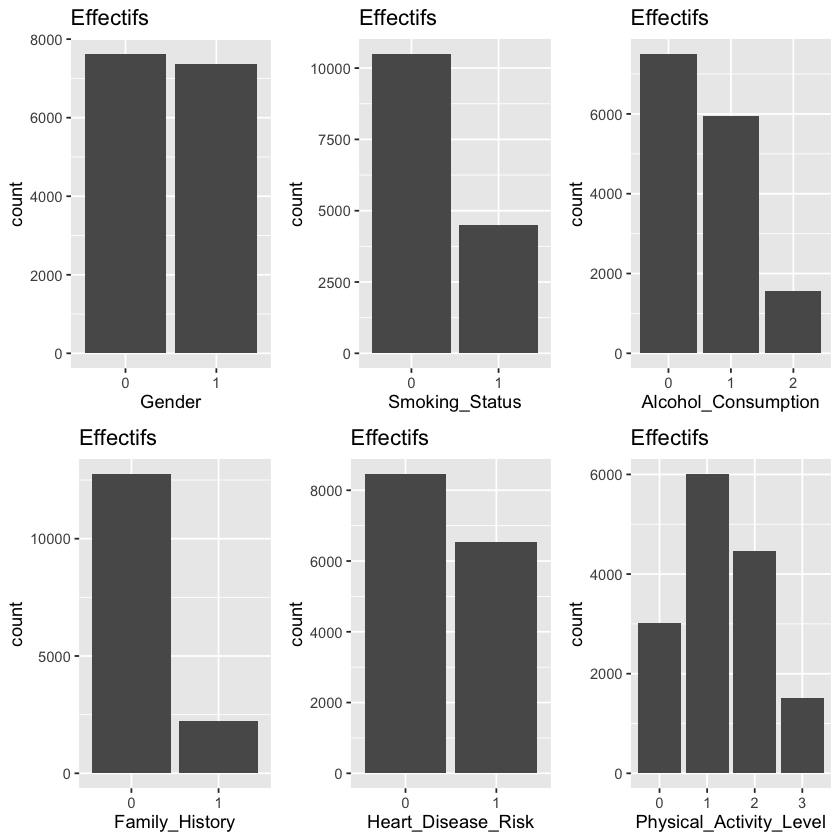

In [9]:

g1 <- ggplot(data) + geom_bar(aes(x = Gender )) + ggtitle("Effectifs")+xlab("Gender")
g2 <- ggplot(data) + geom_bar(aes(x = Smoking_Status)) + ggtitle("Effectifs")+xlab("Smoking_Status")
g3 <- ggplot(data) + geom_bar(aes(x = Alcohol_Consumption)) + ggtitle("Effectifs")+xlab("Alcohol_Consumption")
g4 <- ggplot(data) + geom_bar(aes(x = Family_History)) + ggtitle("Effectifs")+xlab("Family_History")
g5 <- ggplot(data) + geom_bar(aes(x = Heart_Disease_Risk)) + ggtitle("Effectifs")+xlab("Heart_Disease_Risk")
g6 <- ggplot(data) + geom_bar(aes(x = Physical_Activity_Level)) + ggtitle("Effectifs")+xlab("Physical_Activity_Level")

grid.arrange(g1, g2,  g3,g4, g5,g6 ,ncol= 3, nrow=2)


In [11]:
for (var in c("Gender", "Smoking_Status", "Alcohol_Consumption", 
              "Family_History", "Heart_Disease_Risk", "Physical_Activity_Level")) {
  cat("\n--- Répartition de", var, "\n")
  tab <- table(data[[var]])
  pct <- round(prop.table(tab) * 100, 1)
  for (modalite in names(tab)) {
    cat(modalite, ":", tab[modalite], "observations (", pct[modalite], "%)\n")
  }
}


--- Répartition de Gender 
0 : 7622 observations ( 50.8 %)
1 : 7378 observations ( 49.2 %)

--- Répartition de Smoking_Status 
0 : 10495 observations ( 70 %)
1 : 4505 observations ( 30 %)

--- Répartition de Alcohol_Consumption 
0 : 7502 observations ( 50 %)
1 : 5939 observations ( 39.6 %)
2 : 1559 observations ( 10.4 %)

--- Répartition de Family_History 
0 : 12757 observations ( 85 %)
1 : 2243 observations ( 15 %)

--- Répartition de Heart_Disease_Risk 
0 : 8460 observations ( 56.4 %)
1 : 6540 observations ( 43.6 %)

--- Répartition de Physical_Activity_Level 
0 : 3020 observations ( 20.1 %)
1 : 6009 observations ( 40.1 %)
2 : 4453 observations ( 29.7 %)
3 : 1518 observations ( 10.1 %)


#### Répartition des variables qualitatives 

L'échantillon est équilibré en termes de genre (50.8% d'hommes contre 49.2% de femmes).  

Concernant les habitudes de vie, 70% des patients sont non-fumeurs. La consommation d'alcool est majoritairement absente ou modérée (50% et 39.6%), avec seulement 10.4% de consommateurs importants. De même, 85% des patients n'ont pas d'antécédents familiaux de maladie cardiaque.  

En ce qui concerne l'activité physique, la majorité des patients ont un niveau modéré (40.1%), tandis que les niveaux extrêmes : sédentaire (20.1%) et très actif (10.1%) sont moins représentés.  

Enfin, la variable cible **Heart_Disease_Risk** présente une distribution relativement équilibrée : 56.4% des patients sont à faible risque contre 43.6% à risque élevé. Ce quasi-équilibre est favorable pour la modélisation, car il limite les problèmes de classes déséquilibrées qui pourraient biaiser les performances des algorithmes de classification.


### Variables quantitatives continues

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


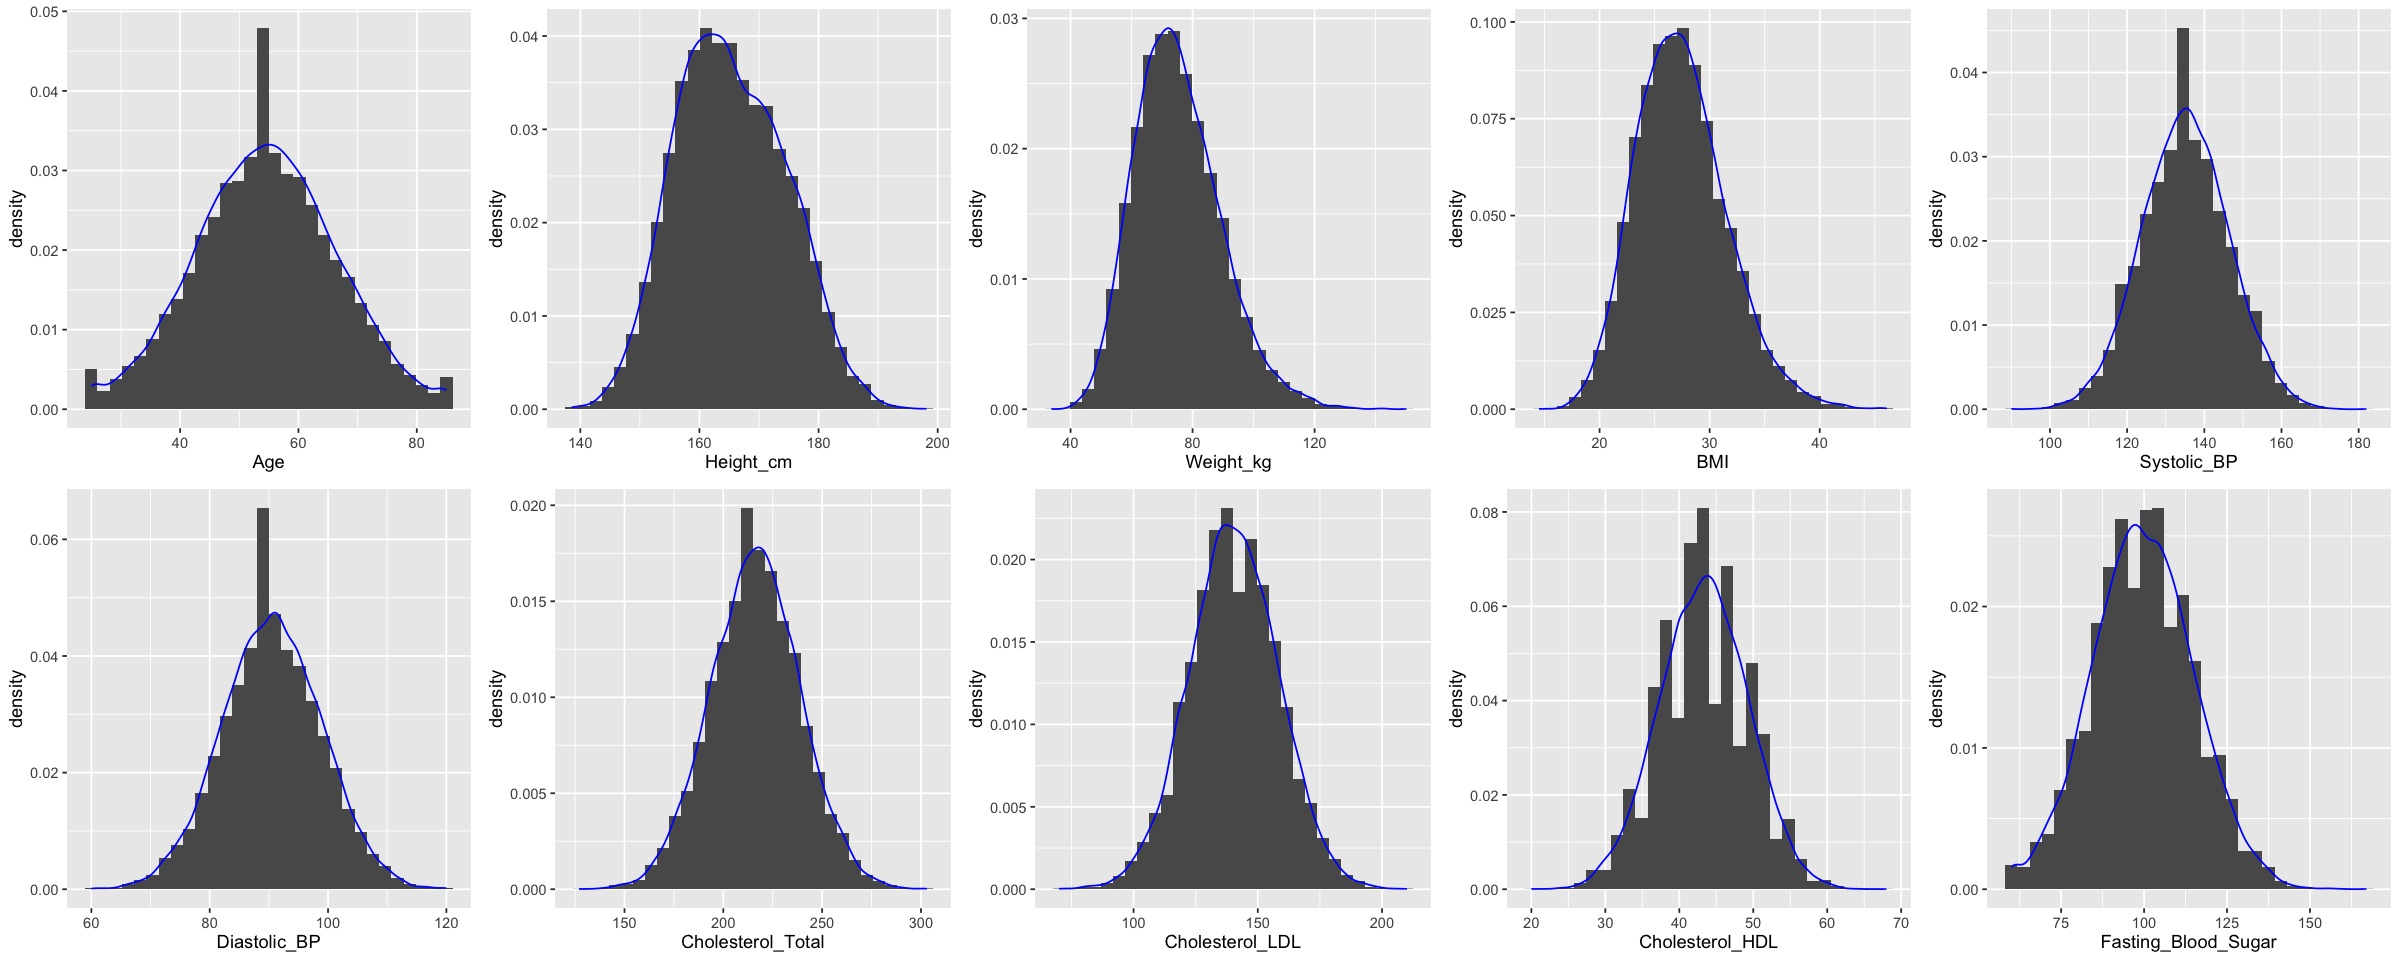

In [15]:
# Histogrammes des variables quantitatives continues
g1<-ggplot(data,aes(x=Age))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue") 
g2<-ggplot(data,aes(x=Height_cm))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g3<-ggplot(data,aes(x=Weight_kg))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g4<-ggplot(data,aes(x=BMI))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g5<-ggplot(data,aes(x=Systolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g6<-ggplot(data,aes(x=Diastolic_BP))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g7<-ggplot(data,aes(x=Cholesterol_Total))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g8<-ggplot(data,aes(x=Cholesterol_LDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g9<-ggplot(data,aes(x=Cholesterol_HDL))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")
g10<-ggplot(data,aes(x=Fasting_Blood_Sugar))+
  geom_histogram(aes(y=after_stat(density)))+
  geom_density(alpha=.2, col="blue")


options(repr.plot.width = 20, repr.plot.height = 8)

grid.arrange(g1,g2,g3, g4, g5, g6, g7, g8, g9, g10, ncol=5, nrow=2)
rm(g1,g2,g3,g4,g5,g6,g7,g8, g9, g10)

#### Analyse de la forme des densités des variables quantitatives continues

La majorité des variables quantitatives suivent une distribution approximativement normale : Height_cm, Weight_kg, BMI, Cholesterol_Total et Cholesterol_LDL présentent des courbes de densité symétriques et bien centrées aucune transformation ne semble nécessaire pour ces variables.  

Pour les variables :  
* Age, Systolic_BP, Diastolic_BP : leur distribution est globalement normale mais présente un pic marqué autour de 55-60 ans pour l'age et 90 mmHg et 130 mmHg pour Systolic_BP et Diastolic_BP, suggérant une légère irrégularité. 
* Cholesterol_HDL : la distribution est irrégulière et multi-modale, avec plusieurs pics distincts.
* Fasting_Blood_Sugar, Weigth, BMI : leur distribution présente une légère asymétrie à droite et Fasting_Blood_Sugar est un peu irrégulière. on peut considérer une transformation log est envisageable.

Transformation des variables concernées  :

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message in rm(g1, g2, g1, g2, g3, g4, g5, g6):
“objet 'g1' introuvable”
Warning message in rm(g1, g2, g1, g2, g3, g4, g5, g6):
“objet 'g2' introuvable”


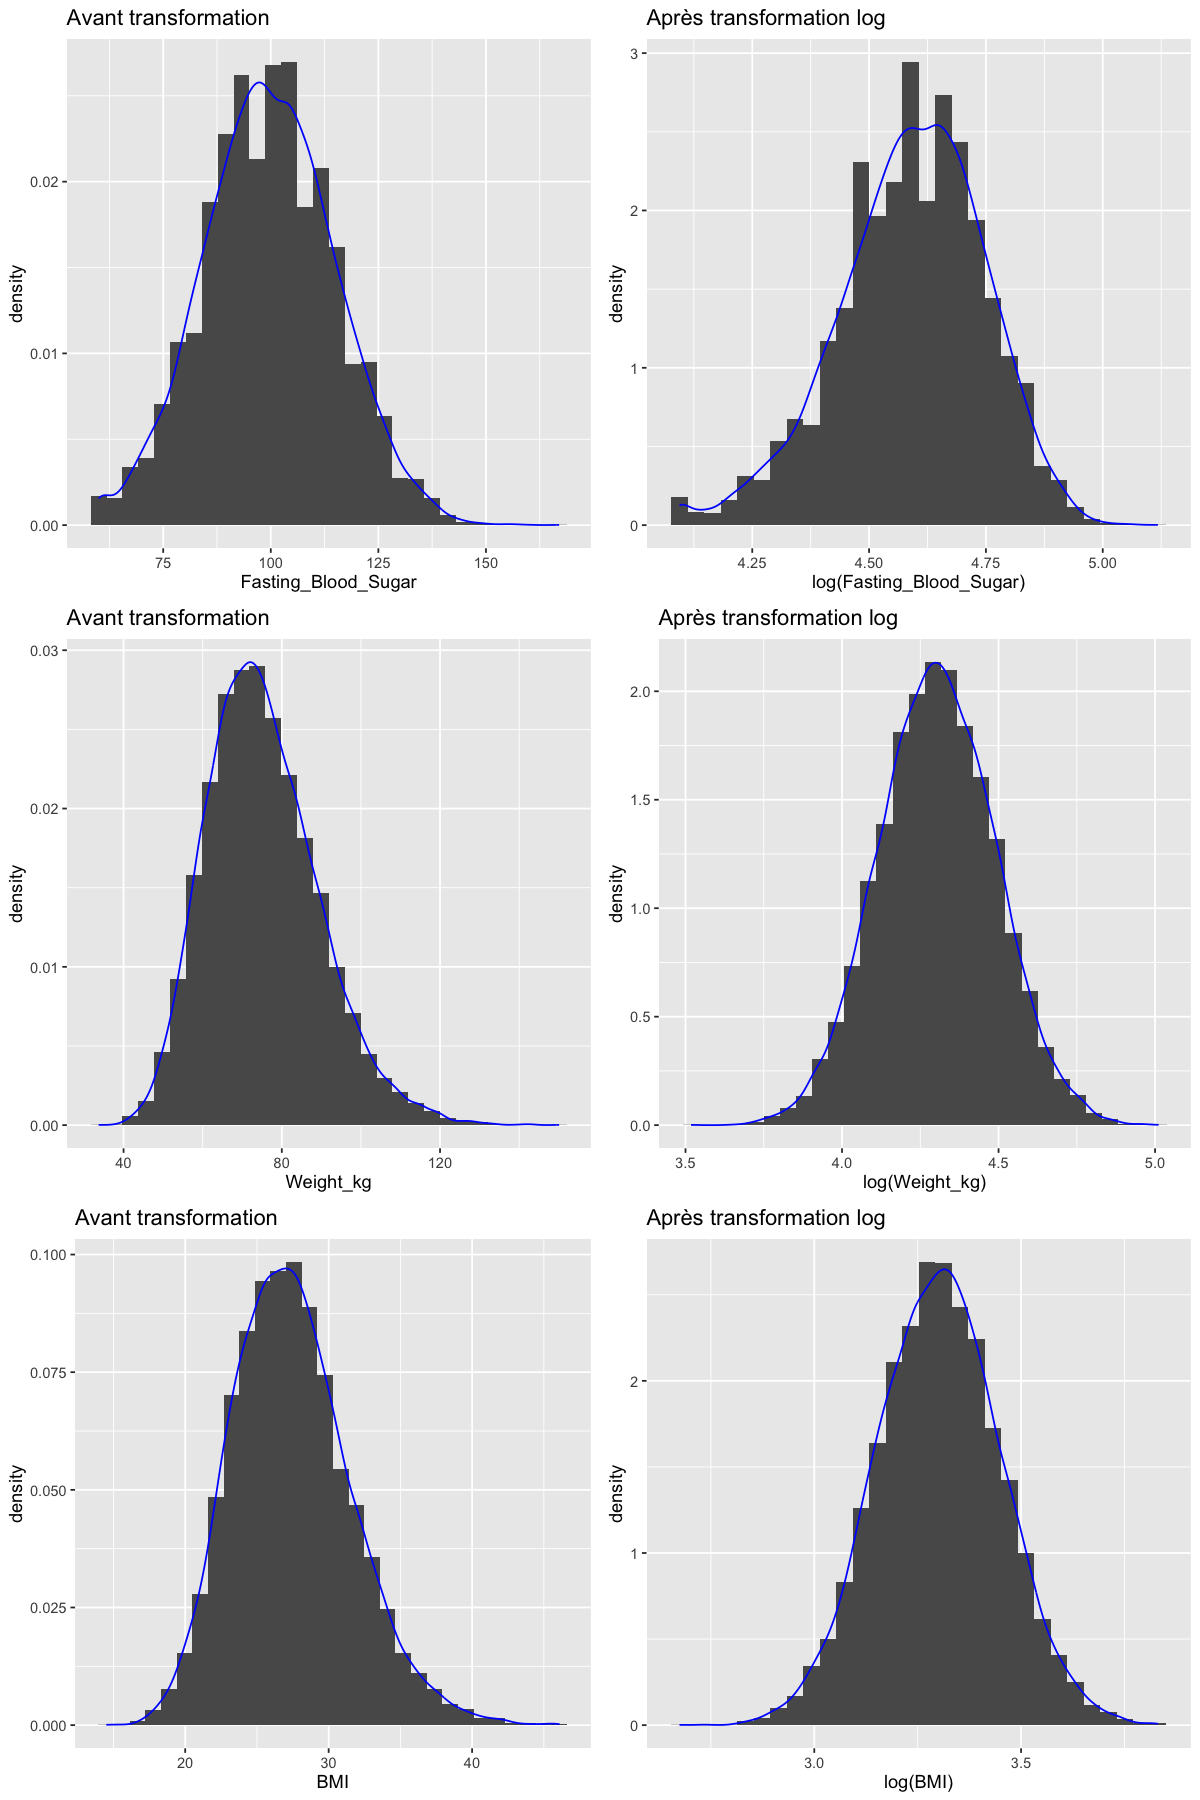

In [18]:
data$Fasting_Blood_Sugar_log <- log(data$Fasting_Blood_Sugar)
data$Weight_kg_log <- log(data$Weight_kg)
data$BMI_log <- log(data$BMI)

# Visualisation avant/après transformation
g1 <- ggplot(data, aes(x = Fasting_Blood_Sugar)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Avant transformation") +
  xlab("Fasting_Blood_Sugar")

g2 <- ggplot(data, aes(x = Fasting_Blood_Sugar_log)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Après transformation log") +
  xlab("log(Fasting_Blood_Sugar)")

g3 <- ggplot(data, aes(x = Weight_kg)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Avant transformation") +
  xlab("Weight_kg")

g4 <- ggplot(data, aes(x = Weight_kg_log)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Après transformation log") +
  xlab("log(Weight_kg)")

g5 <- ggplot(data, aes(x = BMI)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Avant transformation") +
  xlab("BMI")

g6 <- ggplot(data, aes(x = BMI_log)) +
  geom_histogram(aes(y = after_stat(density))) +
  geom_density(alpha = .2, col = "blue") +
  ggtitle("Après transformation log") +
  xlab("log(BMI)")

options(repr.plot.width = 10, repr.plot.height = 15)

grid.arrange(g1, g2,g3, g4, g5, g6 ,ncol = 2)
rm(g1, g2, g1, g2,g3, g4, g5, g6 )


* Fasting_Blood_Sugar : la distribution originale est déjà symétrique et la transformation log n'apporte aucune amélioration visible. On garde l'original.
* Weight_kg : distribution quasi-normale avec une légère queue à droite. La transformation log ne change pas significativement la forme
* BMI : Aucune transformation n'est nécessaire.

Les densités de ces variables ne changent pas drastiquement avec une transformation en log. Nous faisons ainsi la décision de procéder sans transformations pour la suite du projet.


In [20]:
data$Fasting_Blood_Sugar_log <- NULL
data$Weight_kg_log <- NULL
data$BMI_log <- NULL

### Variables quantitatives discrètes 

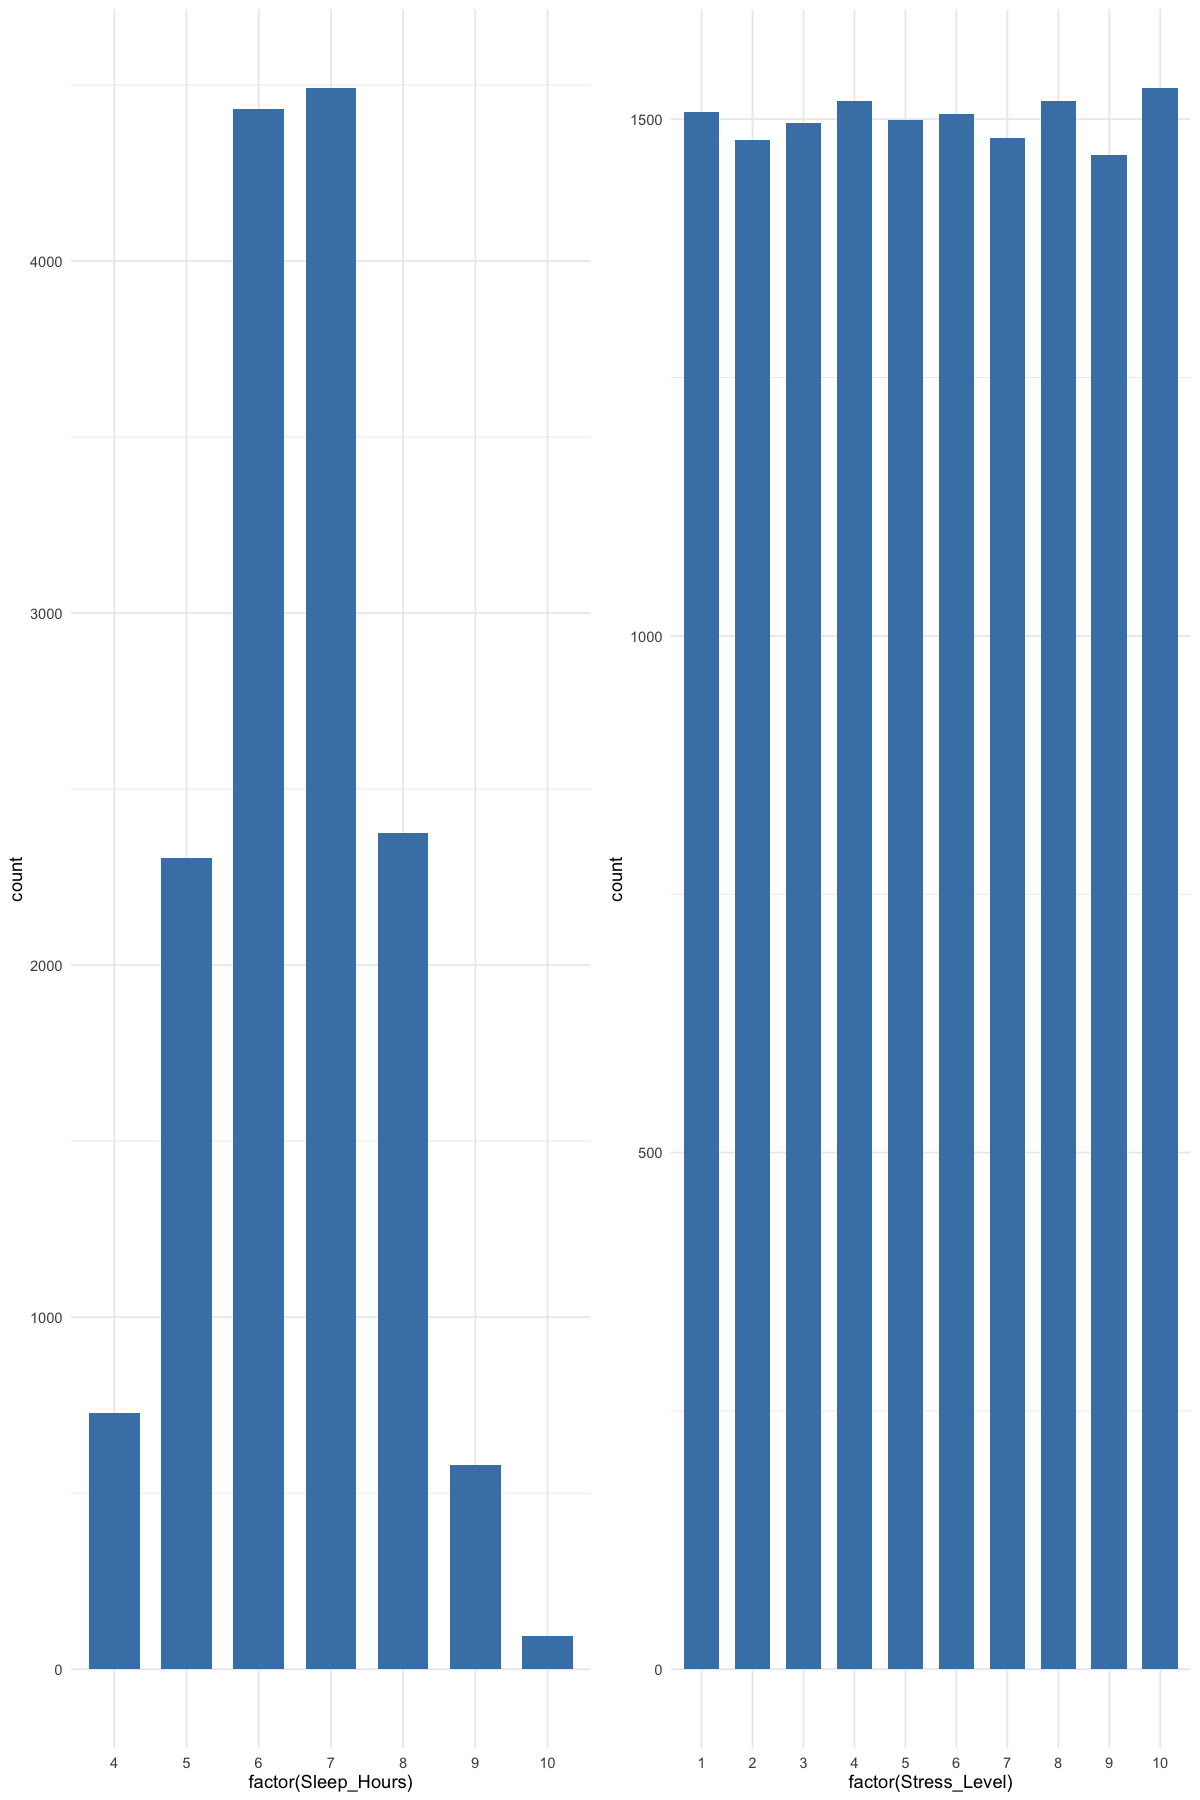

In [23]:
g1 <- ggplot(data, aes(x=factor(Sleep_Hours)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

g2 <- ggplot(data, aes(x=factor(Stress_Level)))+
  geom_bar(stat="count", width=0.7, fill="steelblue")+
  theme_minimal()

grid.arrange(g1, g2, ncol = 2)


#### Interprétation de Sleep_Hours et Stress_Level. 

* Sleep_Hours : la distribution est concentrée sur 6-7 heures de sommeil. Les valeurs extrêmes (4h et 10h) sont peu représentées. La distribution est légèrement asymétrique à gauche.
* Stress_Level : la distribution est remarquablement uniforme sur toutes les modalités (1 à 10), avec environ 1500 observations par niveau. Cela suggère que cette variable apportera donc peu de signal discriminant pour la modélisation.

## Analyses descriptives bidimensionnelles


### Entre variables quantitatives 

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


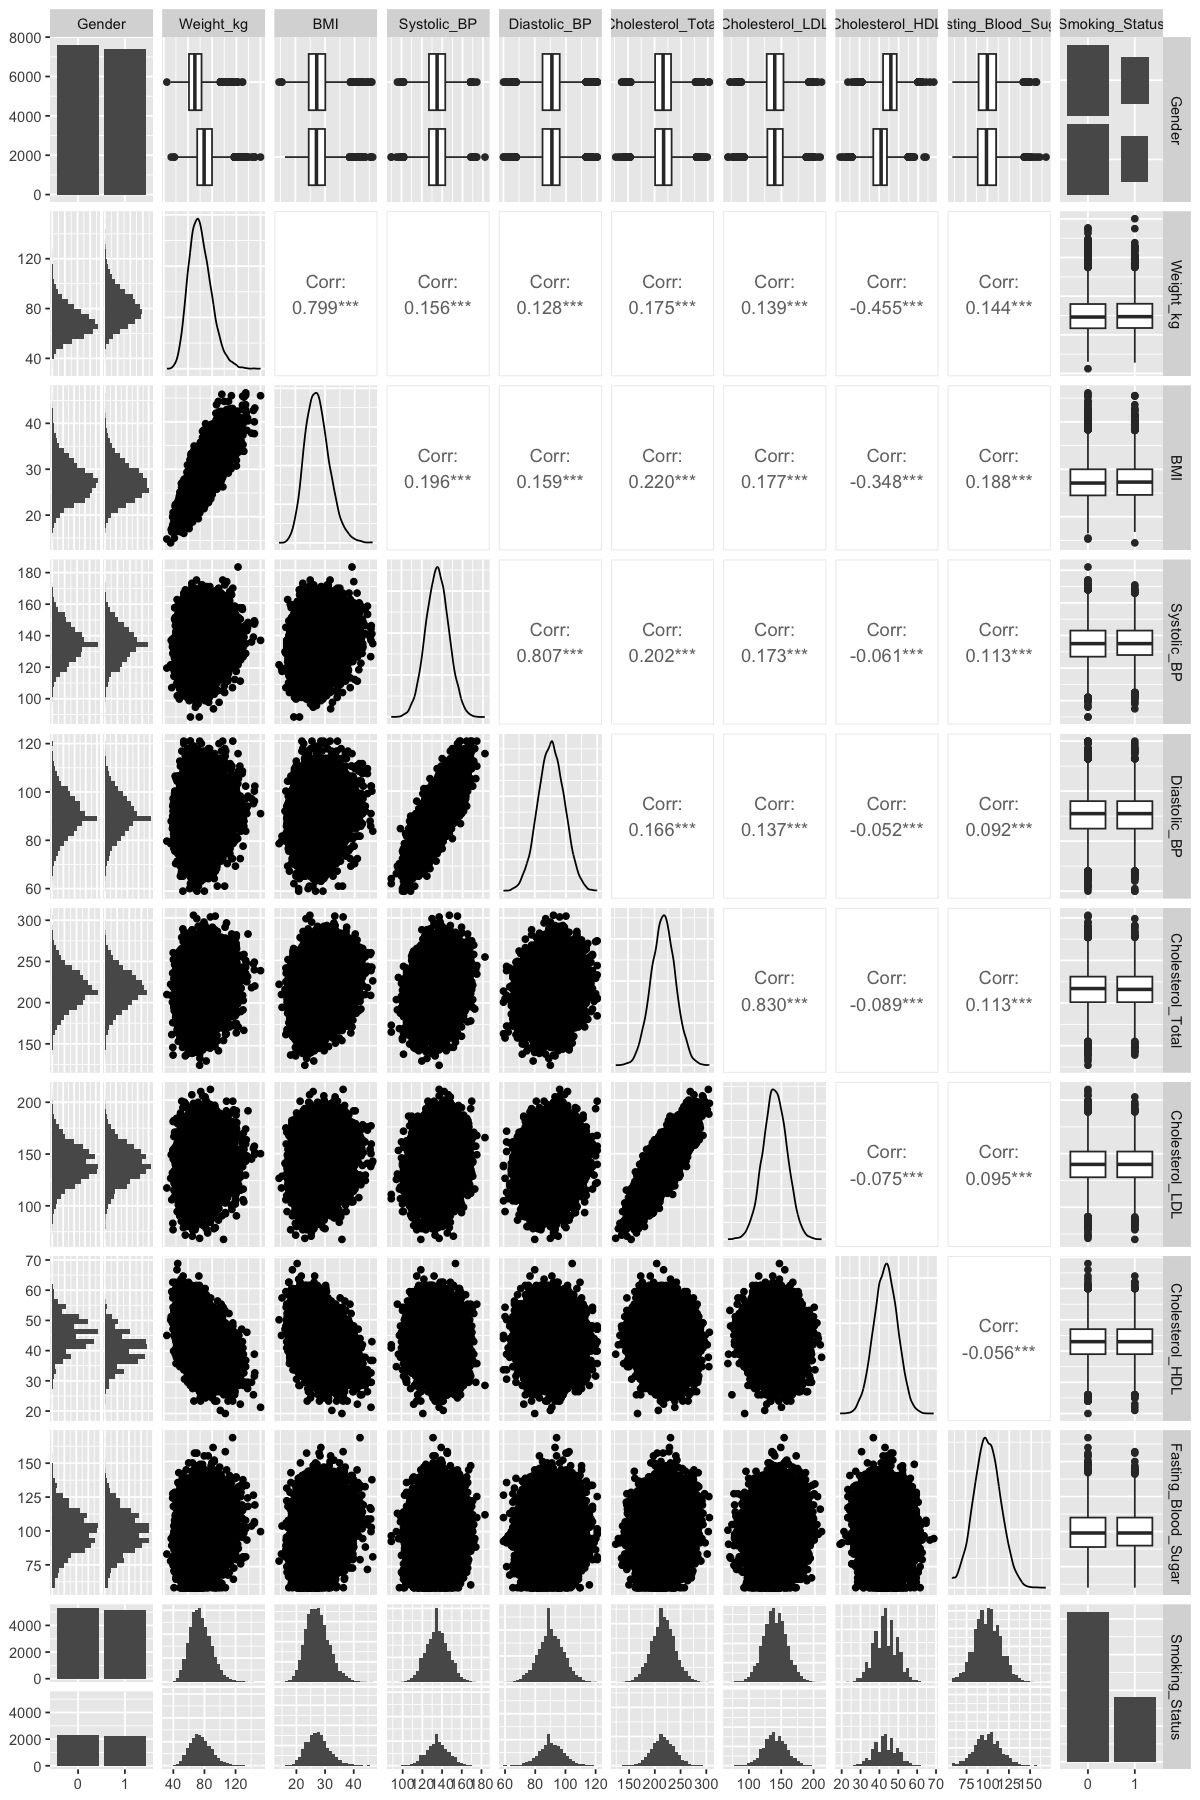

In [28]:
ggpairs(data[, c(2,4:12)])

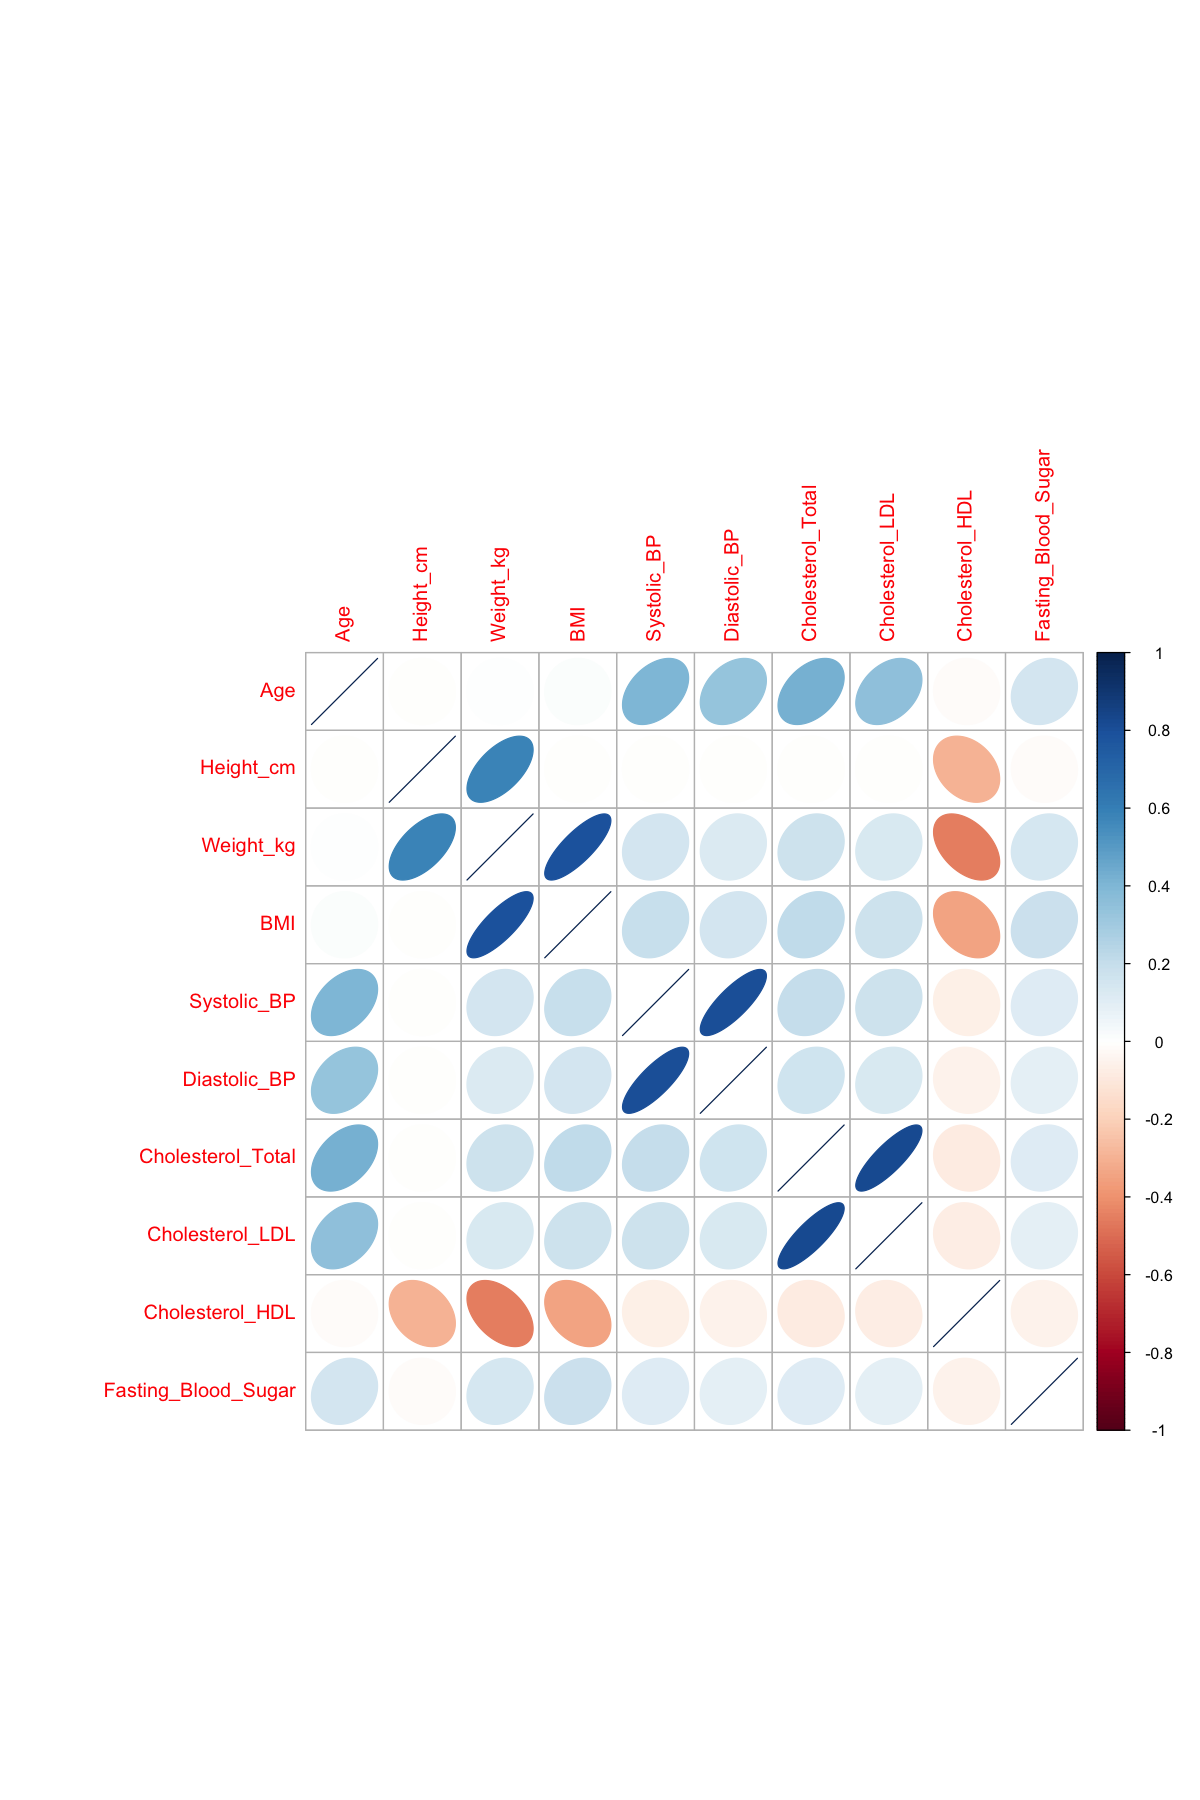

In [29]:
corrplot(cor(data[, c(1,3:11)]),method="ellipse")

#### Analyse des corrélations entre variables quantitatives. 

L'analyse bidimensionnelle met en évidence plusieurs relations notables entre les variables explicatives.  
On observe trois corrélations positives fortes :  

* Weight_kg et BMI (r = 0.79) : ce résultat est cohérent, l'IMC est directement calculé à partir du poids.
* Systolic_BP et Diastolic_BP (r = 0.80) : les deux mesures de pression artérielle évoluent généralement dans le même sens.
* Cholesterol_Total et Cholesterol_LDL (r = 0.83) : Le cholestérol LDL étant la composante principale du cholestérol total.

On note également une corrélation négative modérée entre Cholesterol_HDL et Weight_kg (r = -0.45), ce qui est cohérent avec la littérature médicale : le surpoids tend à réduire le taux de bon cholestérol.

> Le coefficient de corrélation de Pearson r mesure la force et la direction de la relation linéaire entre deux variables quantitatives. Il varie entre -1 et 1. Si r proche de 1 (respectivement -1) dénote une forte corrélation positive (respectivement négative).

### Entre variables quantitatives et qualitatives

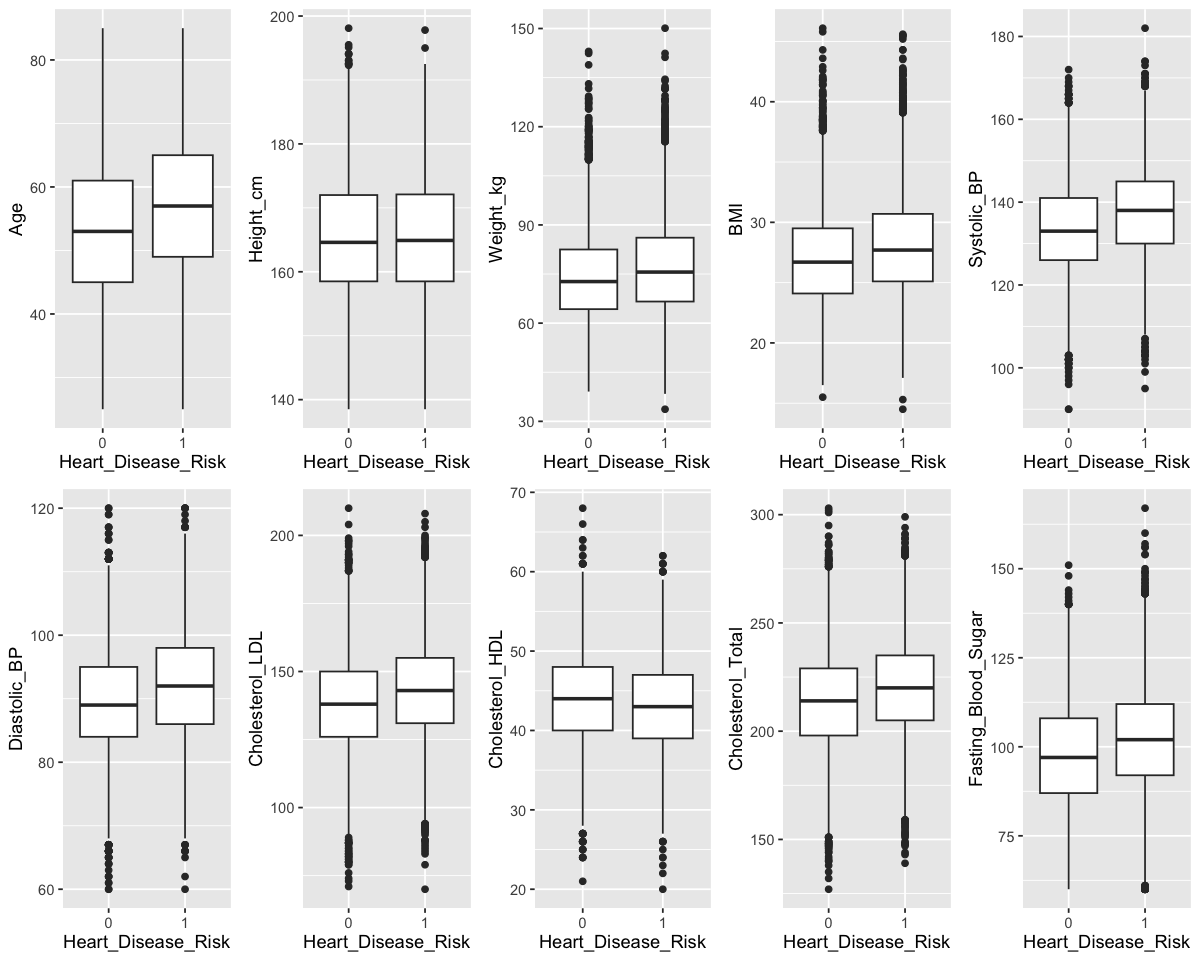

In [32]:

g1 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Age)) +
  geom_boxplot()

g2 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Height_cm)) +
  geom_boxplot()

g3 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Weight_kg)) +
 geom_boxplot()

g4 <- ggplot(data, aes(x = Heart_Disease_Risk, y = BMI)) +
  geom_boxplot()

g5 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Systolic_BP)) +
  geom_boxplot()

g6 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Diastolic_BP)) +
  geom_boxplot()

g7<- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_LDL)) +
  geom_boxplot()

g8 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_HDL)) +
  geom_boxplot()

g9 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_Total)) +
  geom_boxplot()

g10 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Fasting_Blood_Sugar)) +
  geom_boxplot()

options(repr.plot.width = 10, repr.plot.height = 8)

grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, g9, g10,ncol = 5, nrow = 2)

**Analyse des boxplots : variables quantitatives vs Heart_Disease_Risk**. 

Les boîtes à moustaches permettent de visualiser l'influence de chaque variable quantitative sur le risque d'accident cardiaque (0 = faible risque, 1 = risque élevé).
* Age, BMI et Weight_kg présentent une médiane légèrement supérieure pour les patients à risque élevé, suggérant un lien modeste mais existant avec le risque cardiovasculaire. Les distributions sont de taille similaire entre les deux groupes, avec quelques valeurs aberrantes dans les parties supérieures pour BMI et Weight_kg.
* Height_cm ne montre aucune différence notable entre les deux groupes (médianes et étendues quasi identiques) ce qui suggère que la taille n'est pas un facteur discriminant pour le risque cardiaque.
* Systolic_BP et Diastolic_BP affichent une médiane légèrement plus élevée pour les patients à risque, ce qui est cohérent avec le fait qu'une pression artérielle élevée est un facteur de risque cardiovasculaire bien établi.
* Concernant le cholestérol, on observe que des niveaux légèrement supérieurs de Cholesterol_Total et Cholesterol_LDL sont associés à un risque plus élevé, tandis qu'un Cholesterol_HDL plus faible est associé à un risque plus élevé, ce qui est cohérent avec la notion de Cholesterol_HDL étant le « bon » cholestérol.
* Enfin, Fasting_Blood_Sugar suit la même tendance : des valeurs plus élevées sont associées à un risque cardiaque plus important, ce qui est attendu étant donné le lien connu entre diabète et maladies cardiovasculaires.

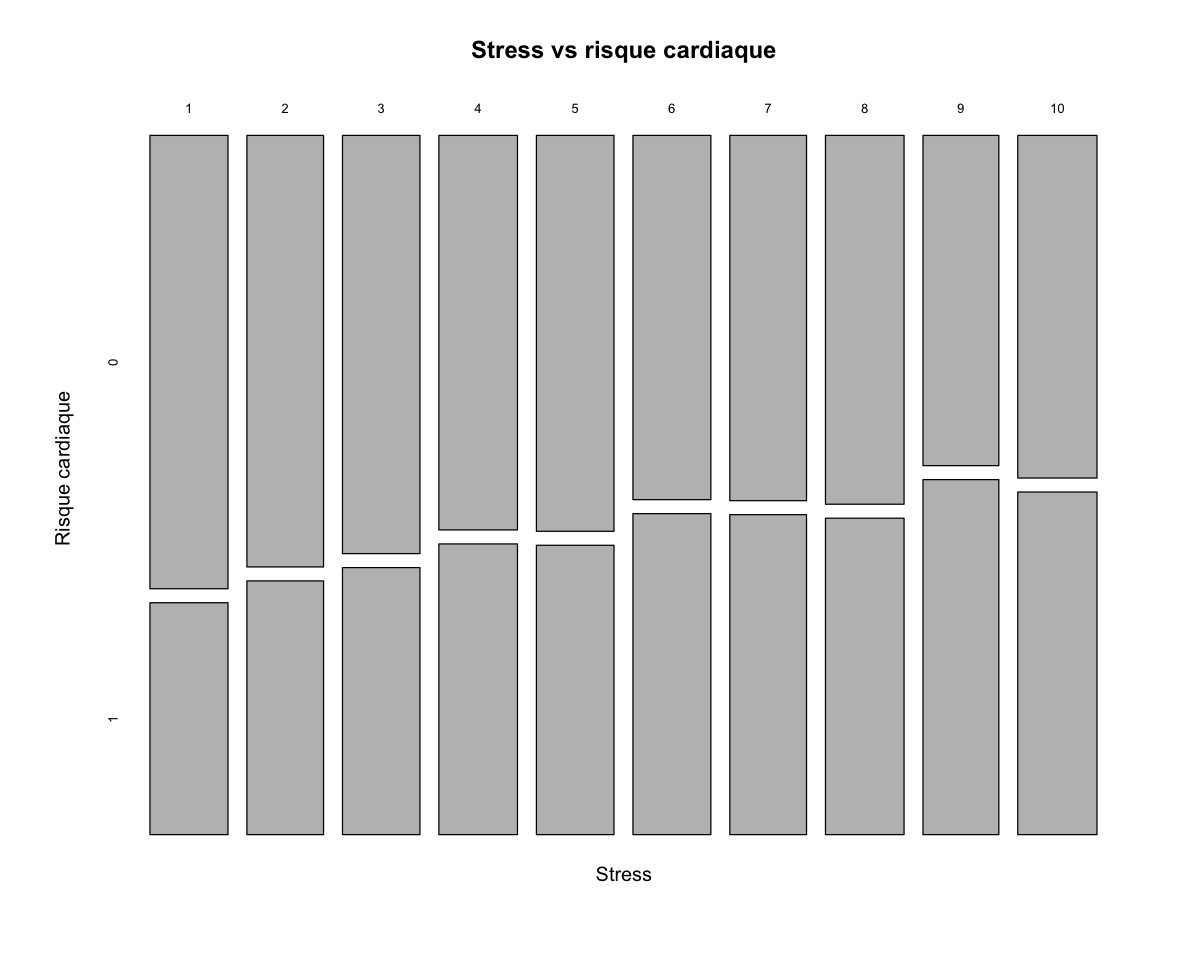

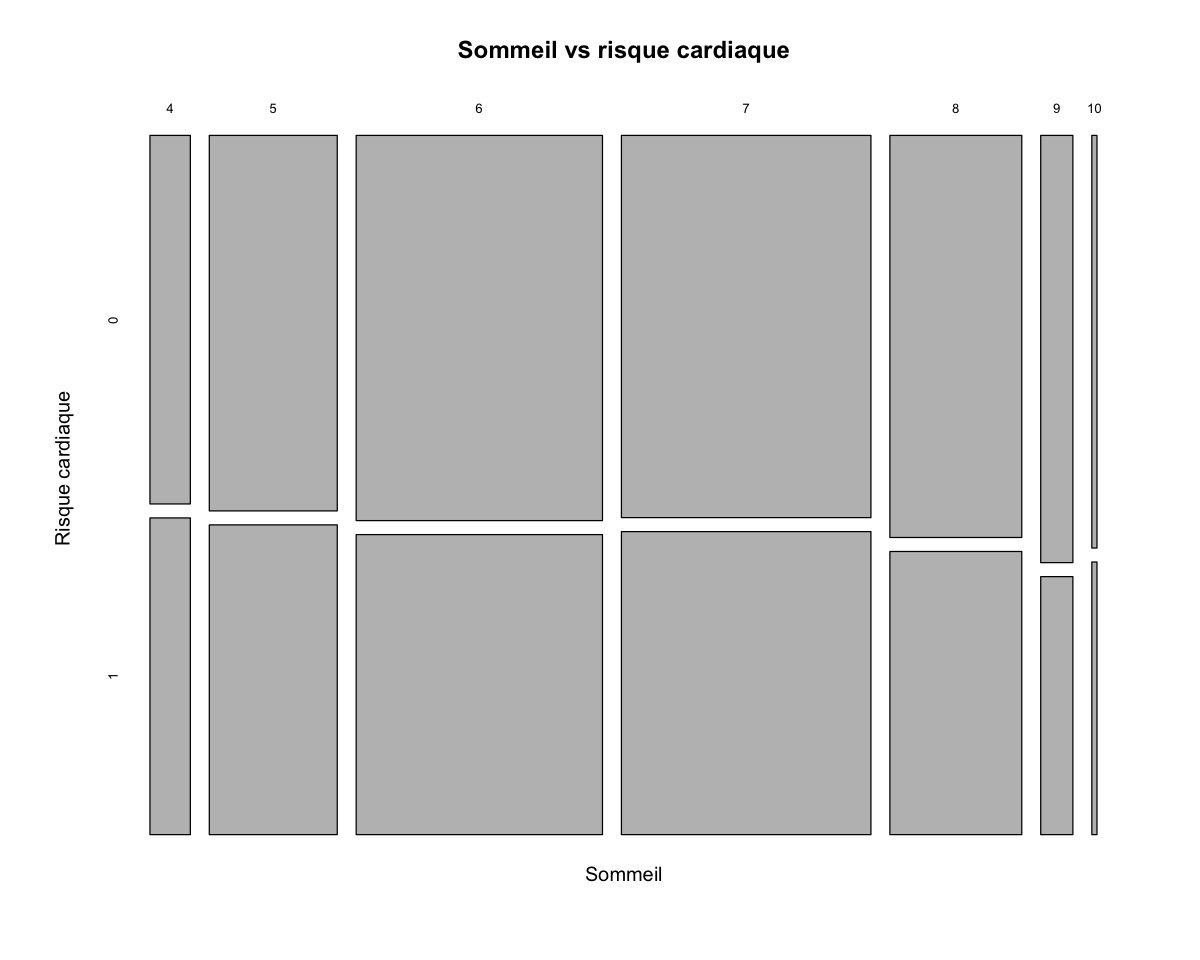

In [35]:
mosaicplot(
  table(data$Stress_Level, data$Heart_Disease_Risk),
  xlab = "Stress",
  ylab = "Risque cardiaque",
  main = "Stress vs risque cardiaque"
)
mosaicplot(
  table(data$Sleep_Hour, data$Heart_Disease_Risk),
  xlab = "Sommeil",
  ylab = "Risque cardiaque",
  main = "Sommeil vs risque cardiaque"
)

**Analyse du mosaicplot : Sleep_Hours et Stress_Level vs Heart_Disease_Risk**.  

* Stress_Level : on observe une légère augmentation progressive de la proportion de patients à risque élevé à mesure que le niveau de stress croît. En général, on observe une proportion de risque élevè légèrement moins importante chez les personnes moins stressées.
* Sleep_Hours : les patients déclarant 8 à 9 heures de sommeil présentent une proportion de risque élevé très légèrement inférieure aux patients dormant 4 à 7 heures. 


### Entre variables qualitatives

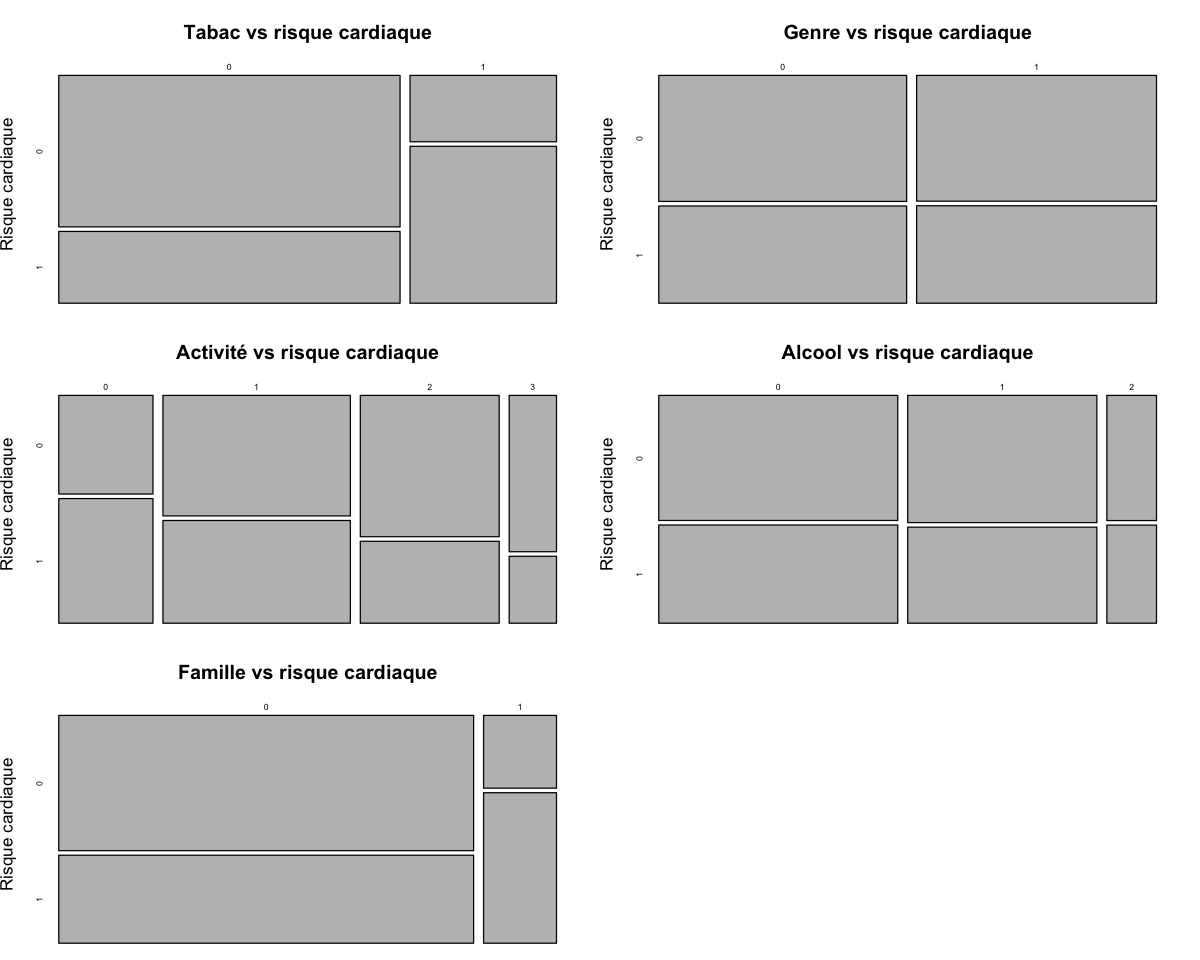

In [39]:
# Mettre 2 lignes et 3 colonnes pour afficher plusieurs plots sur une seule fenêtre
par(mfrow = c(3, 2), mar = c(1, 2, 4, 1), cex.axis = 1.2, cex.lab = 1.3, cex.main = 1.5) # 'mar' ajuste les marges pour que ce soit plus compact

# Mosaic plots
mosaicplot(
  table(data$Smoking_Status, data$Heart_Disease_Risk),
  xlab = "Statut tabagisme",
  ylab = "Risque cardiaque",
  main = "Tabac vs risque cardiaque"
)

mosaicplot(
  table(data$Gender, data$Heart_Disease_Risk),
  xlab = "Genre",
  ylab = "Risque cardiaque",
  main = "Genre vs risque cardiaque"
)

mosaicplot(
  table(data$Physical_Activity_Level, data$Heart_Disease_Risk),
  xlab = "Activité physique",
  ylab = "Risque cardiaque",
  main = "Activité vs risque cardiaque"
)

mosaicplot(
  table(data$Alcohol_Consumption, data$Heart_Disease_Risk),
  xlab = "Consommation alcool",
  ylab = "Risque cardiaque",
  main = "Alcool vs risque cardiaque"
)

mosaicplot(
  table(data$Family_History, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Famille vs risque cardiaque"
)


#### Analyse du mosaicplot : variables qualitatives vs Heart_Disease_Risk
Smoking_Status et Family_History apparaissent comme les variables qualitatives les plus discriminantes. Les fumeurs et les patients ayant des antécédents familiaux présentent une proportion de risque élevé nettement supérieure, tandis que la proportion de patients à faible risque est notablement plus faible dans les groupes non-fumeurs et sans antécédents familiaux.   

Physical_Activity_Level montre également une tendance claire : la proportion de patients à risque élevé est la plus importante chez les personnes sédentaires (niveau 0) et diminue progressivement à mesure que le niveau d'activité physique augmente, confirmant le rôle protecteur de l'exercice physique.  

En revanche, Gender et Alcohol_Consumption ne semblent pas être des facteurs discriminants. Les proportions de risque élevé et faible sont similaires entre les modalités, malgré la répartition déséquilibrée de la consommation d'alcool. Ces deux variables pourraient donc s'avérer peu utiles pour la modélisation.

## Analyse en Composantes Principales (ACP)

### Sélection du nombre de dimensions

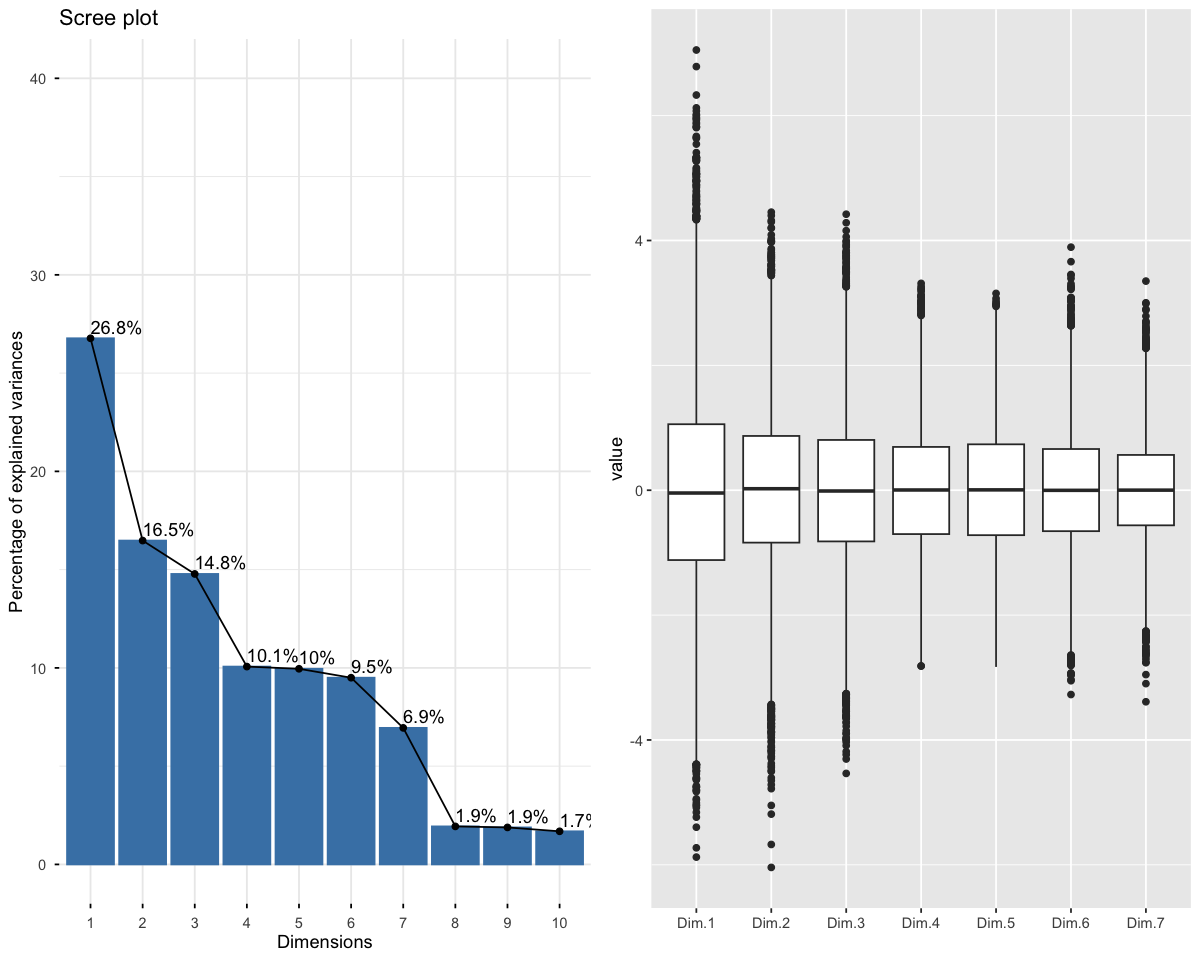

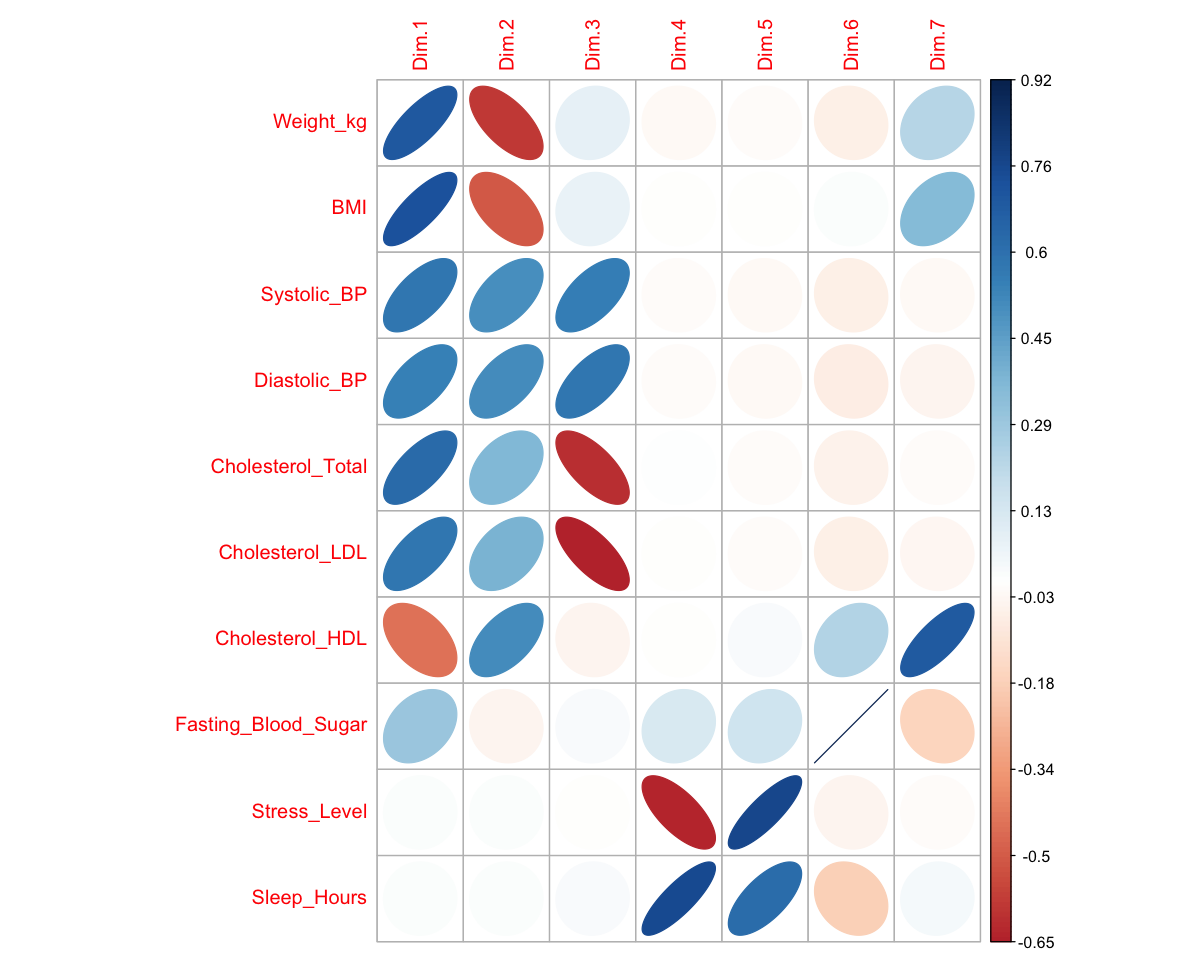

In [44]:
dataquant = data[, c(1,c(3:11,16,17))]
acp <- PCA(dataquant, scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)


corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

#### Variance expliquée et Interprétation des axes de l'ACP
Les quatre premières composantes expliquent 68.2% de la variance totale (Dim1 : 26.8%, Dim2 : 16.5%, Dim3 : 14.8%, Dim4 : 10.1%). Le choix de 4 dimensions est justifié car on observe un second coude après la 4ème dimension sur le scree plot, et ce seuil permet de capturer une part satisfaisante de l'information tout en limitant la dimensionnalité.

* Dim1 est fortement et positivement corrélée à Weight_kg, BMI, Systolic_BP, Diastolic_BP et Cholesterol_Total, et négativement à Cholesterol_HDL. Cet axe représente un axe de risque cardiovasculaire global, un score élevé sur cette dimension correspond à un profil à risque (corpulence élevée, pression artérielle haute, mauvais profil lipidique).
* Dim2 est dominée négativement par Weight_kg et BMI, et positivement aussi par Systolic_BP et Diastolic_BP. Elle capture principalement la corpulence et la pression artérielle, indépendamment du profil cholestérol.
* Dim3 oppose fortement Cholesterol_Total et Cholesterol_LDL (négatifs) aux pressions artérielles (positif).
* Dim4 est dominée par Stress_Level (négatif) et Sleep_Hours (positif), formant un axe mode de vie / bien-être totalement indépendant des variables physiologiques précédentes. Cela confirme que le stress et le sommeil constituent une dimension à part entière.

L'ACP met en évidence que les variables les plus structurantes sont celles liées à la pression artérielle, au poids et au cholestérol.

In [ ]:
#ACP DIm 1
fviz_pca_var(acp)
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))

fviz_pca_var(acp,axes=c(1,3))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

fviz_pca_var(acp,axes=c(1,4))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,4))

#ACP DIm 2
#fviz_pca_var(acp,axes=c(2,3))
#fviz_pca_var(acp,axes=c(2,4))

#ACP DIm 2
#fviz_pca_var(acp,axes=c(3,4))


 

**Cercle des corrélations (Variables - PCA)**. 
Les cercle des corrélations confirme et complète l'interprétation précédente :  

**Dim1/Dim2**
* Weight_kg et BMI pointent vers le bas-droite (Dim1+, Dim2-), tandis que Systolic_BP, Diastolic_BP, Cholesterol_Total et Cholesterol_LDL sont regroupés en haut-droite (Dim1+, Dim2+).
* Cholesterol_HDL pointe en sens opposé (haut-gauche), confirmant sa corrélation négative avec les autres variables de risque.
* Stress_Level, Sleep_Hours et Height_cm sont mal représentés sur ce plan.

**Dim1/Dim3** 
* Dim3 permet de dissocier deux groupes qui étaient confondus sur Dim1/Dim2 : Cholesterol_Total et Cholesterol_LDL (Dim1-, Dim3+) s'opposent désormais à Systolic_BP et Diastolic_BP (Dim1+, Dim3+), capturant leurs effets de façon distincte.
* Cholesterol_HDL contribue négativement à Dim3 en opposition à BMI et Weight_kg (Dim3+), confirmant la relation inverse entre corpulence et bon cholestérol (r = -0.45).
*  Les autres variables restent peu informatives.

**Dim1/Dim4**
* Dim4 permet enfin de bien représenter Sleep_Hours (Dim4+) et Stress_Level (Dim4-), qui s'opposent sur cet axe, suggérant une relation inverse entre sommeil et stress.
* Cholesterol_HDL reste isolé des autres variables, confirmant son caractère indépendant par rapport aux variables physiologiques comme BMI, Weight_kg et les pressions artérielles qui contribuent toutes homogènement à Dim1.

  
**Nuage des individus (Individuals - PCA)**.  
Le nuage des individus pour les 3 graphiques est globalement centré, sans structure de clusters évidente. Quelques individus isolés (en orange/rouge) présentent des contributions élevées aux axes ce sont des profils atypiques qui s'éloignent significativement de la moyenne.

 

#### Habillage selon Heart_Risk_Disease

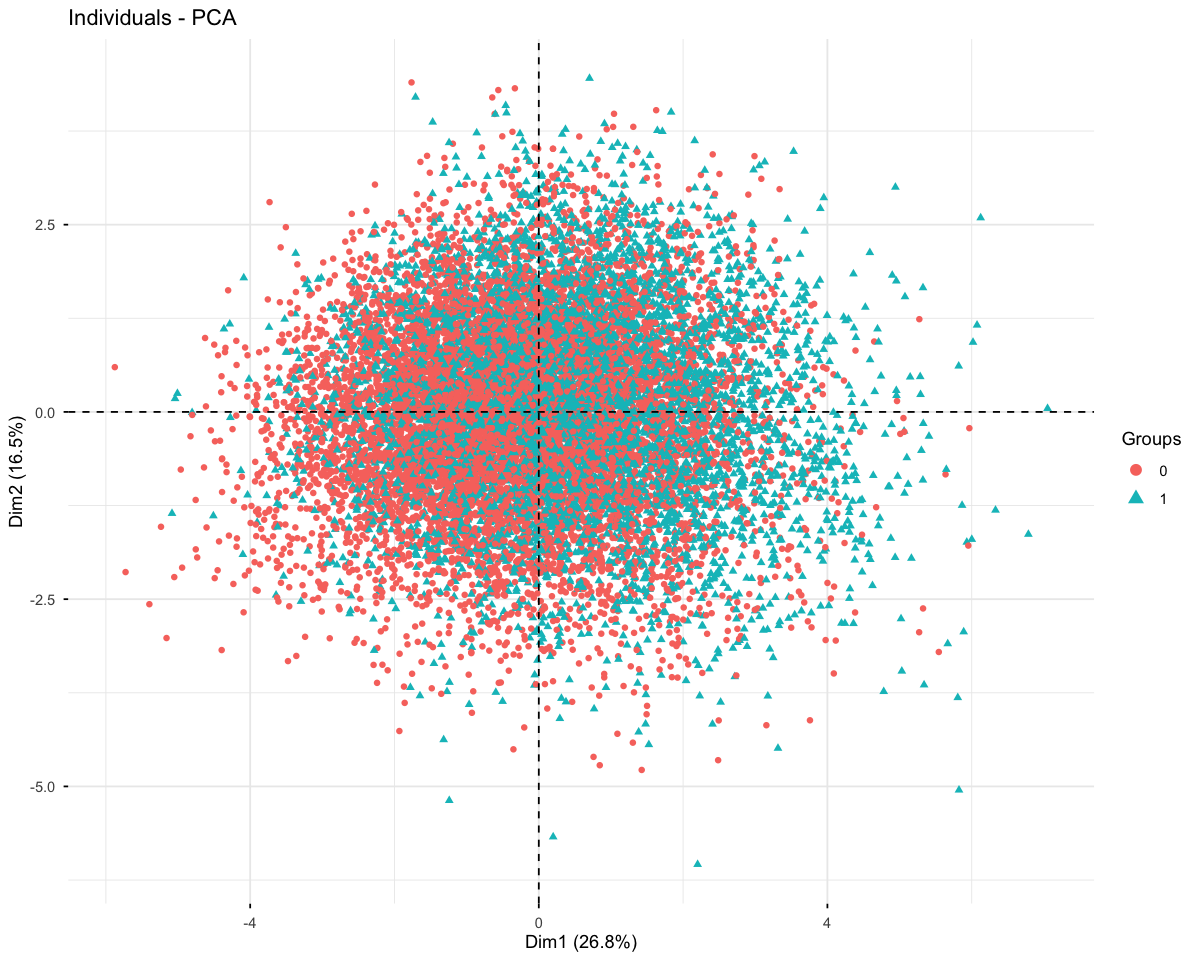

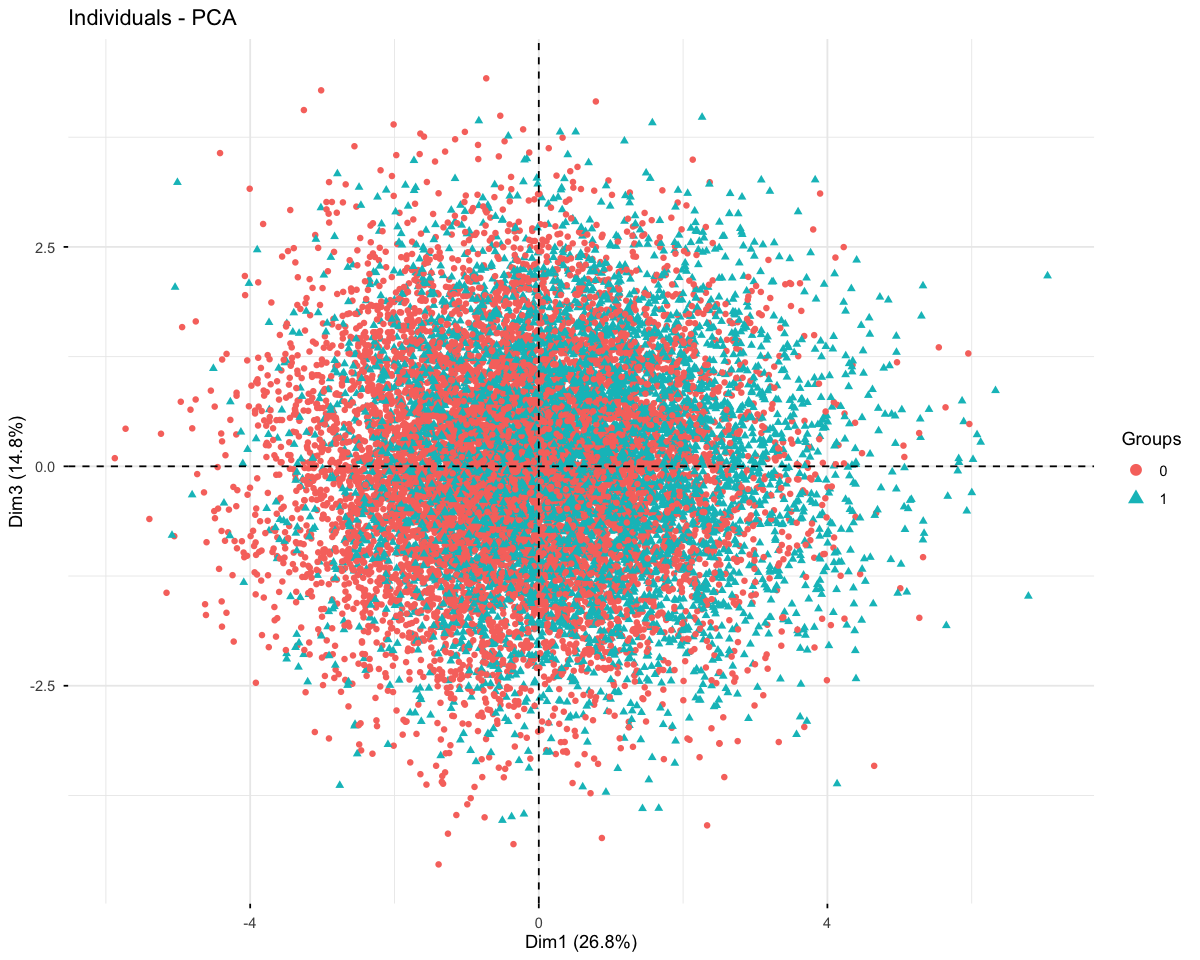

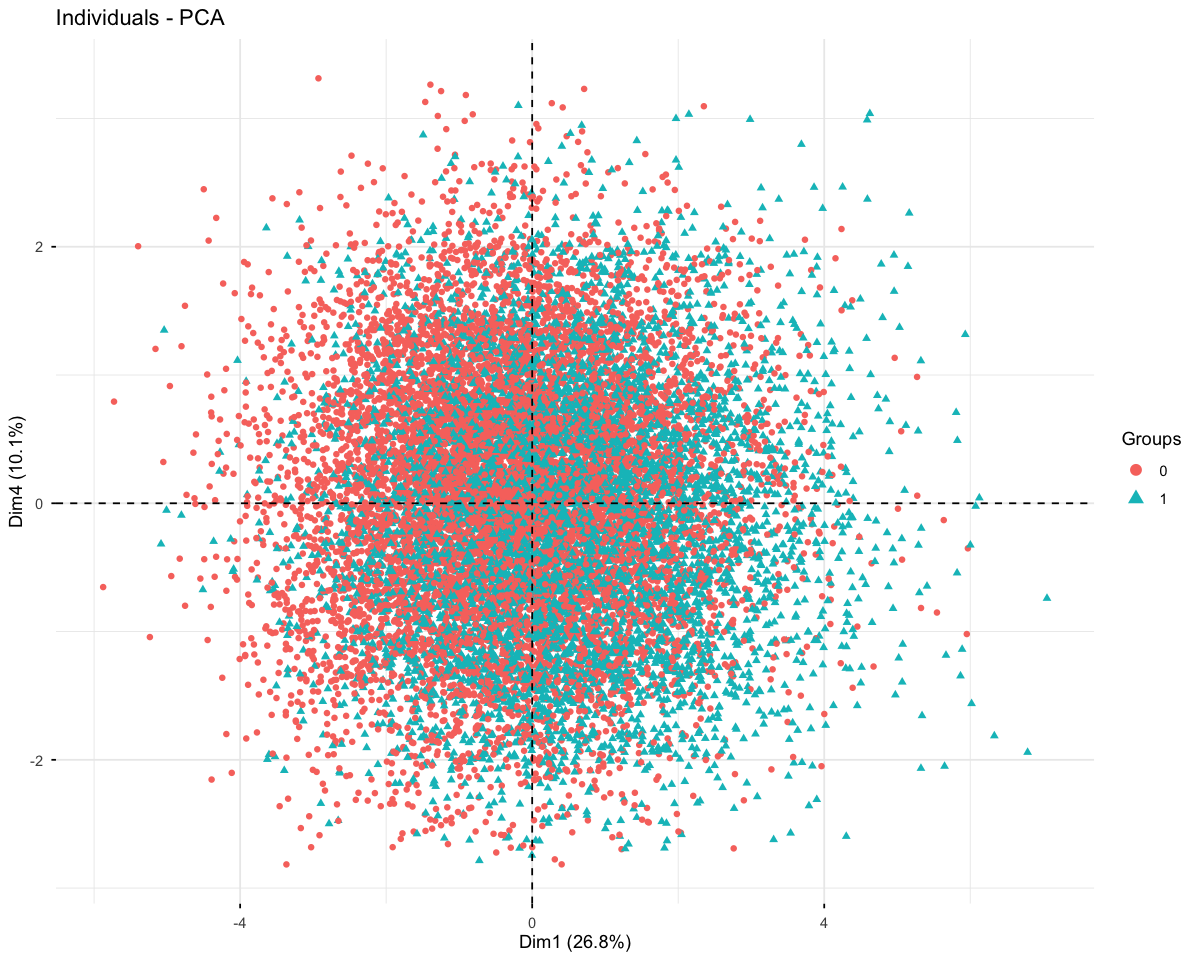

In [47]:
fviz_pca_ind(acp, label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
fviz_pca_ind(acp,axes=c(1,3), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
fviz_pca_ind(acp,axes=c(1,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)

#Graph sur les autres dimensions mais c'est terrible aussi
#fviz_pca_ind(acp,axes=c(2,3), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
#fviz_pca_ind(acp,axes=c(2,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)
#fviz_pca_ind(acp,axes=c(3,4), label="none", habillage=data$Heart_Disease_Risk,addEllipses = FALSE)

La projection des individus sur les 4 premiers plans factoriels ne révèle aucune séparation claire entre les deux groupes. Les patients à risque faible et élevé se superposent sans former de clusters distincts. Cela suggère qu'aucune discrimination linéaire n'est possible dans cet espace réduit, et laisse présager que des modèles non linéaires seront nécessaires pour obtenir de bonnes performances de classification.

### Clustering

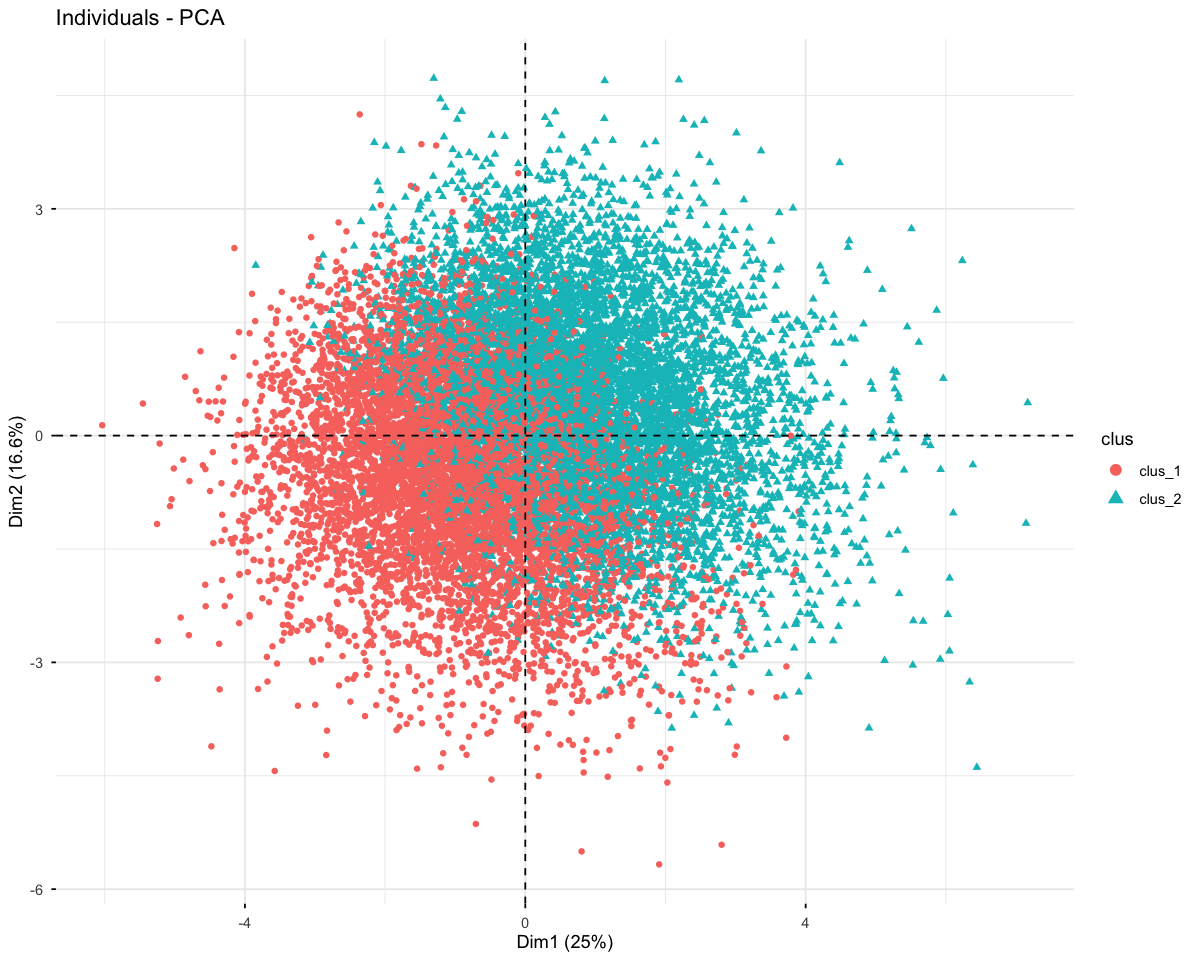

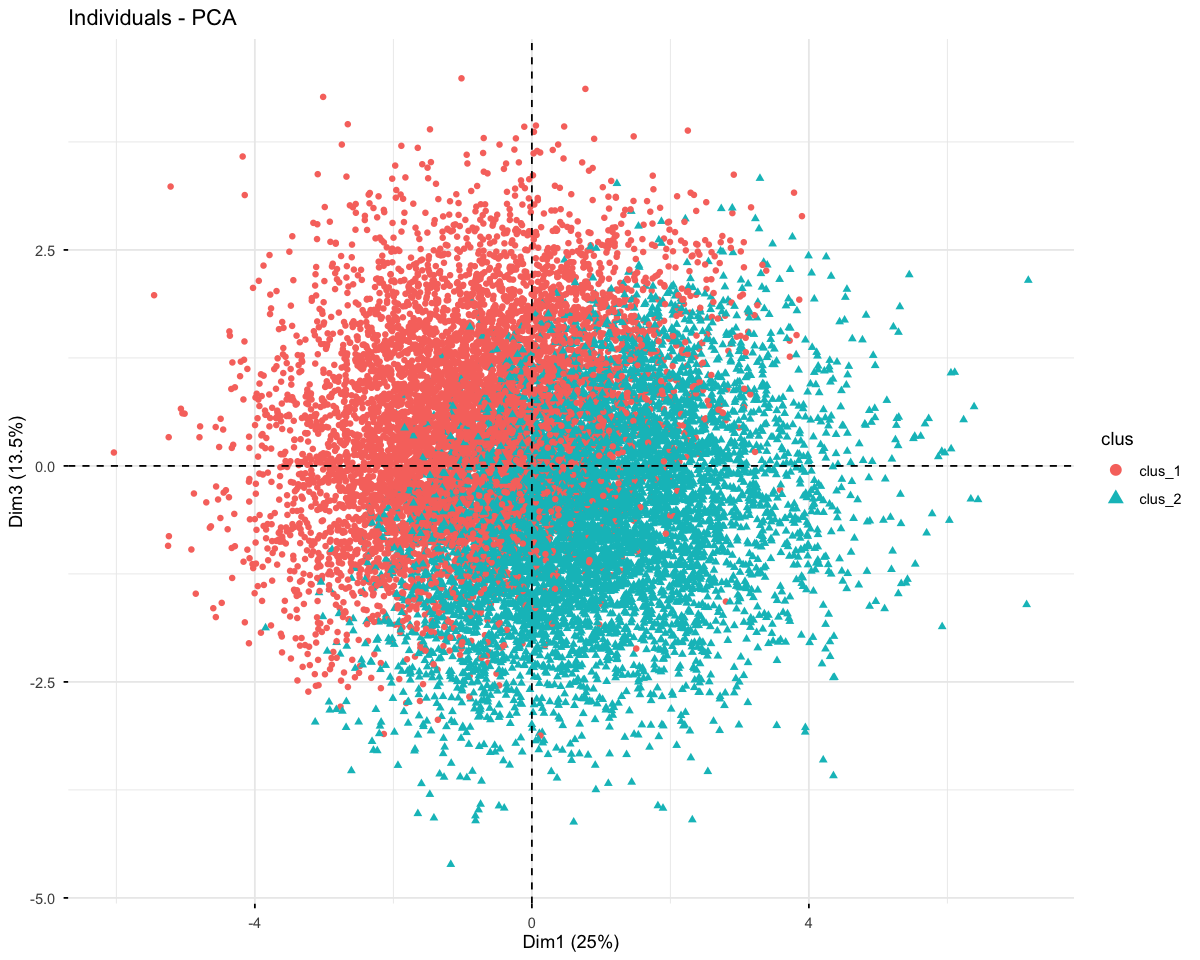

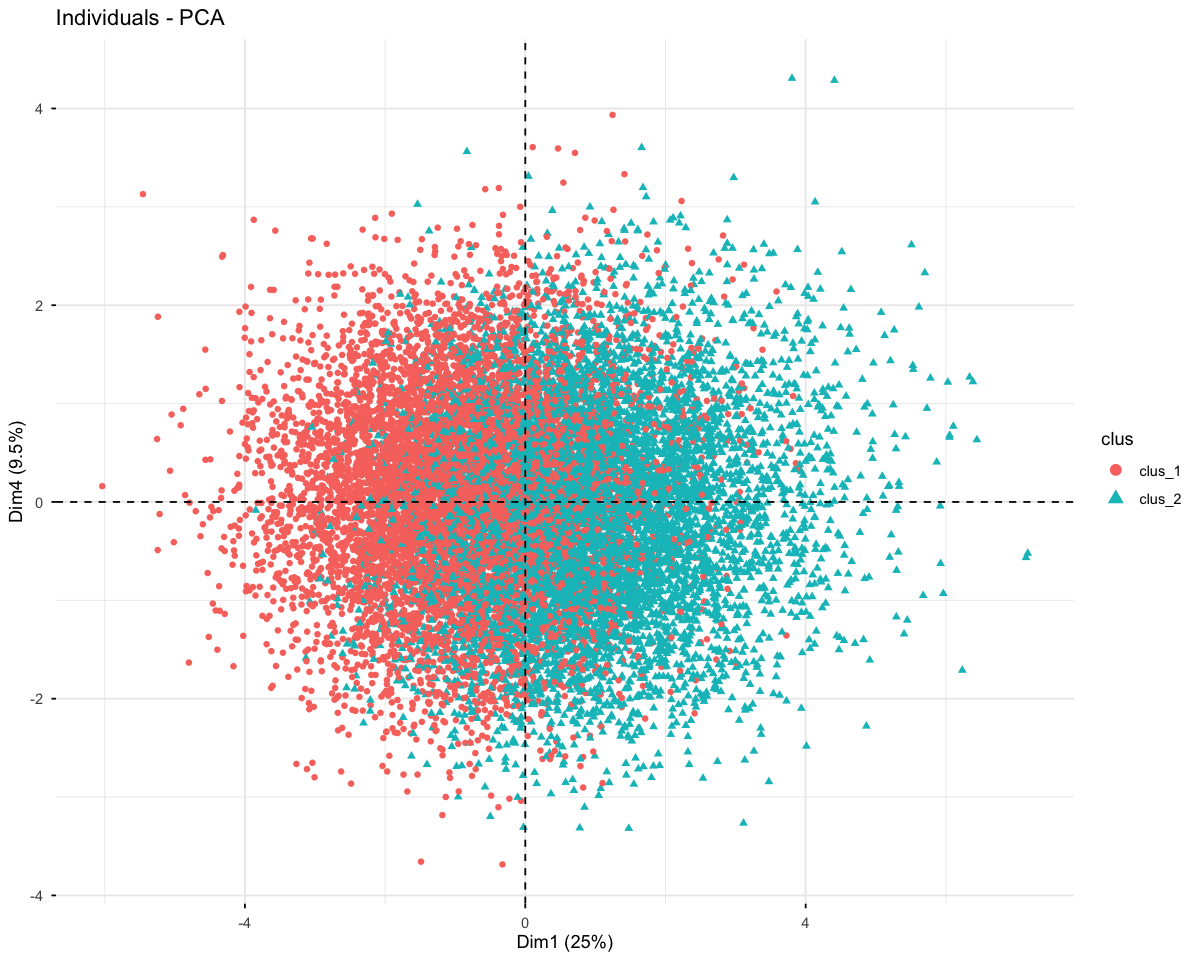

In [57]:
set.seed(100)
km.data <- kmeans(dataquant ,centers = 2)

# Représentation dans les coordonnées de l'acp
acp2 <- PCA(cbind(clus = as.factor(km.data$cluster),
          dataquant), scale.unit = TRUE,
          graph = FALSE, quali.sup = 1:2, ncp = 7)
fviz_pca_ind(acp2, label="none", habillage="clus")
fviz_pca_ind(acp2, label="none", habillage="clus", axes= c(1,3))
fviz_pca_ind(acp2, label="none", habillage="clus", axes= c(1,4))

#### Habillage selon les clusters (k-means, k=2)
**Dim1/Dim2**. 

clus_2 (bleu) est concentré en haut à droite ce qui corresponds à des valeurs élevées de pression artérielle et cholestérol.

**Dim1/Dim3**. 

clus_2 (bleu) se positionne en bas à droite. Dim1 positif et Dim3 négatif, soit des valeurs élevées de Cholesterol_Total et Cholesterol_LDL.

**Dim1/Dim4**. 

Stress_Level et Sleep_Hours ne sont pas des facteurs structurants pour distinguer les deux groupes.
clus_1 (rose) se positionne majoritairement à gauche (Dim1 négatif), ce qui correspond à des valeurs faibles de pression artérielle, poids et cholestérol mais surtout à un Cholesterol_HDL élevé, puisque cette variable contribue négativement à Dim1.

In [59]:
# Effectifs
tab <- table(Cluster = km.data$cluster, Risk = data$Heart_Disease_Risk)
print(tab)

# Proportions par cluster
prop.table(tab, margin = 1) * 100

       Risk
Cluster    0    1
      1 4713 2749
      2 3747 3791


       Risk
Cluster        0        1
      1 63.16001 36.83999
      2 49.70815 50.29185

* clus_2 est quasi équilibré (49.7% / 50.3%) : ce cluster ne discrimine pratiquement pas les deux niveaux de risque.
* clus_1 présente une légère majorité de patients à faible risque (63.2% / 36.8%) : une tendance existe mais elle est loin d'être nette.


#### Conclusion de l'analyse ACP et clustering. 

L'habillage selon les clusters révèle une séparation partiellement visible sur les trois plans factoriels.  
Cependant, deux observations nuancent cette conclusion :
* Le chevauchement important au centre indique que la frontière linéaire simple ne peut discriminer efficacement les 2 groupes.
* Le croisement des clusters avec Heart_Disease_Risk révèle que les clusters ne correspondent pas aux groupes de risque cardiaque. Cela signifie que les similarités physiologiques générales capturées par le k-means ne suffisent pas à expliquer le risque cardiaque des intéractions plus complexes entre variables doivent être prises en compte. On doit ainsi voir au delà du modèle linéaire.

# 3. Modélisation
## 3.1 Prédiction du risque d’accident cardiaque : variable Heart_Disease_Risk


####  Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [64]:
set.seed(111) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
testi <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appri <- setdiff(1:npop, testi) 


In [66]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -which(names(data) == "Heart_Disease_Risk")] # on retire la colonne "Heart_Disease_Risk"

# construction de l'échantillon test
datestr0 <- data[testi, -which(names(data) == "Heart_Disease_Risk")] 

# on récupère la variable cible 
y_train <- data$Heart_Disease_Risk[appri]
y_test  <- data$Heart_Disease_Risk[testi] 

# vérification
# str(datappr0)
# str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# Encoder les var quali
X_train <- as.data.frame(model.matrix(~ ., data = datappr)[, -1])
X_test  <- as.data.frame(model.matrix(~ ., data = datestr)[, -1])

# vérification
# summary(datappr)
# summary(datestr)

## 3.1 MODÈLES LINÉAIRES GÉNÉRALISÉS

Cette section compare plusieurs approches de régression logistique :
 - Modèle complet (toutes les variables)
 - Sélection de variables par stepwise (critères AIC et BIC)
 - Pénalisation Ridge (alpha = 0)
 - Pénalisation Lasso (alpha = 1)
 - Pénalisation Elastic Net (alpha = 0.5)
   

In [86]:
train_df <- data.frame(datappr, Heart_Disease_Risk = y_train)
test_df  <- data.frame(datestr, Heart_Disease_Risk = y_test)

### 3.1 Régression Logistique Complète 

La régression logistique (GLM avec lien logit) modélise la probabilité d'appartenir à la classe 1 (risque élevé) en fonction de toutes les variables explicatives. C'est le modèle de référence (notre baseline).
On utilise toutes les variables sans sélection ni pénalisation.

In [229]:
# estimation du modèle complet
set.seed(111)
log.lm <- glm(Heart_Disease_Risk ~ ., data = train_df, family = binomial)
 
# significativité des paramètres
anova(log.lm, test = "Chisq")
 
# résumé des coefficients
summary(log.lm)

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Height_cm,1,4.706908e+00,11996,16093.81,3.004164e-02
Weight_kg,1,1.950638e+02,11995,15898.75,2.495108e-44
BMI,1,9.667457e-01,11994,15897.78,3.254931e-01
Systolic_BP,1,1.579788e+02,11993,15739.80,3.127980e-36
Diastolic_BP,1,3.286212e-01,11992,15739.47,5.664721e-01
Cholesterol_Total,1,2.488697e+01,11991,15714.58,6.079200e-07



Call:
glm(formula = Heart_Disease_Risk ~ ., family = binomial, data = train_df)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.38078    0.06236  -6.106 1.02e-09 ***
Age                       0.24163    0.02653   9.107  < 2e-16 ***
Gender1                  -0.11720    0.06514  -1.799    0.072 .  
Height_cm                -0.03494    0.14603  -0.239    0.811    
Weight_kg                 0.17387    0.23754   0.732    0.464    
BMI                       0.04635    0.19151   0.242    0.809    
Systolic_BP               0.35188    0.03864   9.106  < 2e-16 ***
Diastolic_BP             -0.02222    0.03683  -0.603    0.546    
Cholesterol_Total        -0.04648    0.04074  -1.141    0.254    
Cholesterol_LDL           0.22559    0.03922   5.752 8.80e-09 ***
Cholesterol_HDL          -0.02160    0.02590  -0.834    0.404    
Fasting_Blood_Sugar       0.31628    0.02282  13.862  < 2e-16 ***
Smoking_Status1           1.99069    0.05027  

Interprétation : Le test du Chi² confirme que la majorité des variables contribuent significativement à réduire la déviance du modèle. Les variables les plus importantes sont Smoking_Status (réduction de 1644), Family_History (633), Physical_Activity_Level (385) et Stress_Level (191). En revanche, Gender, BMI, Diastolic_BP et Cholesterol_HDL ont des p-values largement supérieures à 0.05 et n'apportent pas d'information significative, ce qui motive la sélection de variables.

La déviance résiduelle (12655) est nettement inférieure à la déviance nulle (16453), confirmant que le modèle apporte une information réelle par rapport à un classifieur trivial.

In [231]:
# matrice de confusion sur l'échantillon d'apprentissage (erreur apparente)
table(log.lm$fitted.values > 0.5, train_df$Heart_Disease_Risk)

       
           0    1
  FALSE 5463 1865
  TRUE  1277 3395

In [233]:
# accuracy et AUC sur le test
pred.lm <- predict(log.lm, newdata = test_df, type = "response")
table(pred.lm > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy :", round(mean((pred.lm > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
roc.lm <- roc(test_df$Heart_Disease_Risk, pred.lm, quiet = TRUE)
paste("AUC :", round(auc(roc.lm), 4))

       
           0    1
  FALSE 1383  428
  TRUE   337  852

[1] "Accuracy : 0.745"

[1] "AUC : 0.8084"

Interprétation : 

Le modèle logistique complet, entraîné sur l'ensemble des variables explicatives, obtient une accuracy de 0.745 et une AUC de 0.808 sur l'échantillon test, c'est notre baseline de référence. La déviance résiduelle (12655) nettement inférieure à la déviance nulle (16453) confirme que le modèle apporte une information réelle par rapport à un classifieur trivial. L'absence d'écart significatif entre les performances train et test indique qu'il n'y a pas de surapprentissage.

L'examen des coefficients et du test du Chi² permettent d'identifier les variables les plus influentes. Plusieurs ressortent comme significativement associées au risque cardiaque (p < 0.001) : **l'âge, la pression artérielle systolique, la glycémie à jeun, le tabagisme, le cholestérol LDL, le niveau d'activité physique, les antécédents familiaux, le niveau de stress et le nombre d'heures de sommeil**. Ces résultats sont cohérents avec les connaissances médicales et confirment les tendances observées lors de l'analyse exploratoire. Notons en particulier que **Smoking_Status** est de loin la variable qui réduit le plus la déviance (1644), suivie de **Family_History** (633).


En revanche, **Gender, BMI, Diastolic_BP, Cholesterol_HDL, Cholesterol_Total, Alcohol_Consumption, Height_cm et Weight_kg** s'avèrent non significatifs (p > 0.05). Leur présence n'apporte pas d'information discriminante supplémentaire, ce qui motive l'étape suivante de sélection de variables.

### 3.2 Séléction de Variables par Stepwise (AIC et BIC)

Le stepwise part du modèle complet et ajoute/retire des variables une à une en minimisant le critère AIC (ou BIC). On compare les deux critères :
 - AIC (Akaike) : pénalisation plus légère → tend à garder plus de variables
 - BIC (Bayesian) : pénalisation plus forte → modèle plus parcimonieux

Obj : un modèle avec moins de variables mais performances similaires est préférable pour le principe de parcimonie / rasoir d'Occam. 

In [238]:
# Stepwise AIC : 
# part du modèle complet, direction both = ajoute et retire des variables
# minimise le critère AIC (k=2) : pénalisation légère
set.seed(111)
log.lm.step.aic <- step(log.lm, direction = "both", trace = FALSE)


# variables retenues et leur significativité
anova(log.lm.step.aic, test = "Chisq")
cat("Variables retenues AIC :", paste(names(coef(log.lm.step.aic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(log.lm.step.aic)) - 1, "\n")

# erreur apparente (train)
table(log.lm.step.aic$fitted.values > 0.5, train_df$Heart_Disease_Risk)

# accuracy et AUC sur le test
pred.step.aic <- predict(log.lm.step.aic, newdata = test_df, type = "response")
table(pred.step.aic > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy AIC :", round(mean((pred.step.aic > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
paste("AUC AIC      :", round(auc(roc(test_df$Heart_Disease_Risk, pred.step.aic, quiet = TRUE)), 4))


,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,3.539542e+02,11998,16098.58,5.835412e-79
Gender,1,6.280797e-02,11997,16098.52,8.021116e-01
Height_cm,1,4.706908e+00,11996,16093.81,3.004164e-02
Weight_kg,1,1.950638e+02,11995,15898.75,2.495108e-44
Systolic_BP,1,1.585337e+02,11994,15740.21,2.366047e-36
Cholesterol_LDL,1,5.152876e+01,11993,15688.68,7.055576e-13
Fasting_Blood_Sugar,1,1.562559e+02,11992,15532.43,7.443090e-36
Smoking_Status,1,1.644649e+03,11991,13887.78,0.000000e+00


Variables retenues AIC : Age, Gender1, Height_cm, Weight_kg, Systolic_BP, Cholesterol_LDL, Fasting_Blood_Sugar, Smoking_Status1, Physical_Activity_Level1, Physical_Activity_Level2, Physical_Activity_Level3, Family_History1, Stress_Level, Sleep_Hours 
Nombre de variables    : 14 


       
           0    1
  FALSE 5453 1864
  TRUE  1287 3396

       
           0    1
  FALSE 1384  429
  TRUE   336  851

[1] "Accuracy AIC : 0.745"

[1] "AUC AIC      : 0.8082"

Interprétation : 

Le stepwise AIC retient 14 variables et élimine **BMI, Diastolic_BP, Cholesterol_Total, Cholesterol_HDL et Alcohol_Consumption** toutes non significatives dans le modèle complet. Toutes les variables retenues sont significatives au seuil 0.05 selon l'anova. Les performances sont quasi identiques au modèle complet : **accuracy 0.745, AUC 0.8082**, avec des résultats train/test stables confirmant l'absence de surapprentissage.

In [242]:
# Stepwise BIC : 
# même procédure mais k = log(n) : pénalisation plus forte → modèle plus parcimonieux que AIC
log.lm.step.bic <- step(log.lm, direction = "both",
                         k = log(nrow(train_df)), trace = FALSE)

anova(log.lm.step.bic, test = "Chisq")
cat("Variables retenues BIC :", paste(names(coef(log.lm.step.bic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(log.lm.step.bic)) - 1, "\n")

# erreur apparente (train)
table(log.lm.step.bic$fitted.values > 0.5, train_df$Heart_Disease_Risk)

# accuracy et AUC sur le test
pred.step.bic <- predict(log.lm.step.bic, newdata = test_df, type = "response")
table(pred.step.bic > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy BIC :", round(mean((pred.step.bic > 0.5) == (as.numeric(as.character(y_test)) == 1)), 4))
paste("AUC BIC      :", round(auc(roc(test_df$Heart_Disease_Risk, pred.step.bic, quiet = TRUE)), 4))

,Df,Deviance,Resid. Df,Resid. Dev,Pr(>Chi)
,<int>,<dbl>,<int>,<dbl>,<dbl>
NULL,NA,NA,11999,16452.53,NA
Age,1,353.954194,11998,16098.58,5.835412e-79
Height_cm,1,1.844362,11997,16096.73,1.744405e-01
Weight_kg,1,195.181271,11996,15901.55,2.352065e-44
Systolic_BP,1,159.049768,11995,15742.50,1.825014e-36
Cholesterol_LDL,1,51.274355,11994,15691.23,8.031805e-13
Fasting_Blood_Sugar,1,156.425786,11993,15534.80,6.833209e-36
Smoking_Status,1,1645.541360,11992,13889.26,0.000000e+00
Physical_Activity_Level,3,385.249691,11989,13504.01,3.467581e-83


Variables retenues BIC : Age, Height_cm, Weight_kg, Systolic_BP, Cholesterol_LDL, Fasting_Blood_Sugar, Smoking_Status1, Physical_Activity_Level1, Physical_Activity_Level2, Physical_Activity_Level3, Family_History1, Stress_Level, Sleep_Hours 
Nombre de variables    : 13 


       
           0    1
  FALSE 5461 1859
  TRUE  1279 3401

       
           0    1
  FALSE 1383  432
  TRUE   337  848

[1] "Accuracy BIC : 0.7437"

[1] "AUC BIC      : 0.8089"

Interprétation : 

Le BIC, avec sa pénalisation plus forte, va plus loin et retire également **Gender**, don un modèle à 13 variables. Les performances restent stables : **accuracy 0.7437, AUC 0.8089**. L'AUC est même légèrement supérieure au modèle complet.

CONCLUSION: 

Les deux critères convergent vers le même constat : supprimer 4 à 5 variables non informatives ne dégrade pas les performances. Le BIC, plus parcimonieux avec 13 variables, donne même la meilleure AUC (0.8089). C'est l'illustration du principe de parcimonie : un modèle plus simple avec des performances équivalentes est préférable car plus interprétable et plus robuste sur de nouvelles données. **Le stepwise BIC sera donc notre modèle de référence parmi les approches sans pénalisation.**

### 3.3 Pénalisation Ridge, Lasse, Elastic Net

Avec glmnet, on pénalise les coefficients pour éviter le surapprentissage et/ou sélectionner automatiquement les variables (Lasso).
Le paramètre alpha contrôle le type de pénalisation :
- alpha = 0   → Ridge    : réduit tous les coefficients vers 0, mais aucun exactement à 0
- alpha = 1   → Lasso    : met certains coefficients exactement à 0 (sélection)
- alpha = 0.5 → Elastic Net : compromis entre les deux

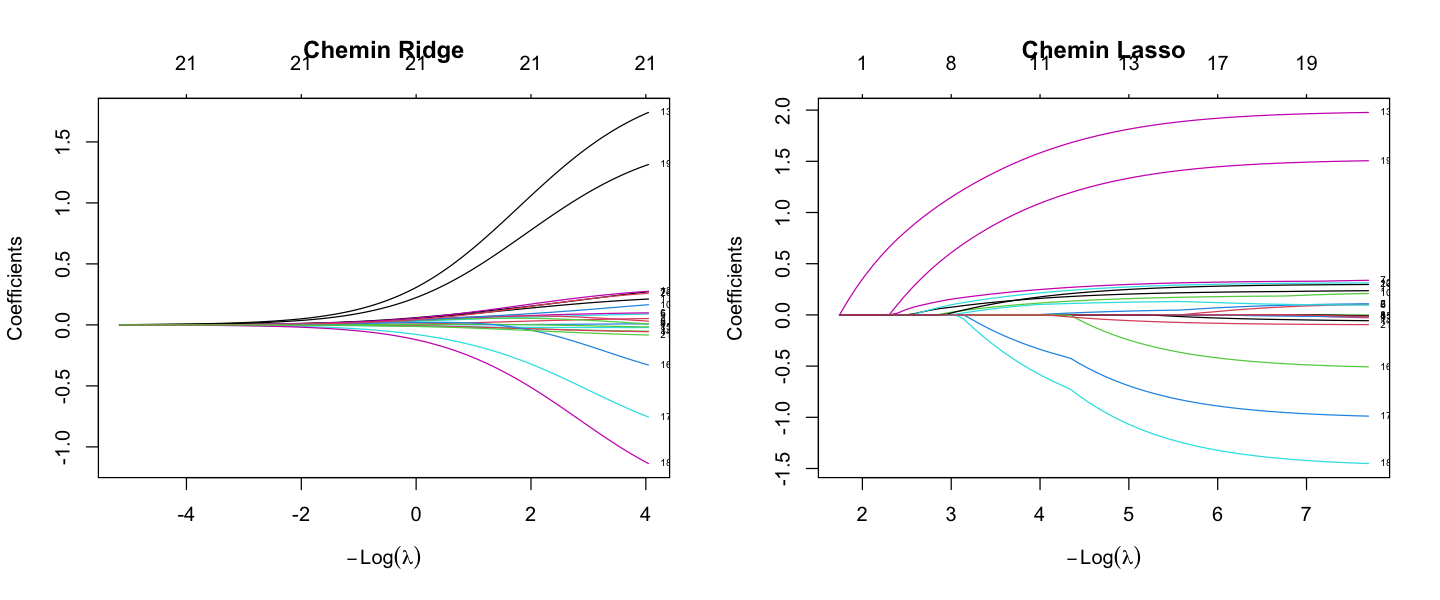

In [273]:
library(glmnet)

# matrice d'expériences avec model.matrix (-1 pour retirer l'intercept)
x.mat      <- model.matrix(Heart_Disease_Risk ~ . - 1, data = train_df)
x.mat.test <- model.matrix(Heart_Disease_Risk ~ . - 1, data = test_df)
y.train.num <- as.numeric(as.character(y_train))
y.test.num  <- as.numeric(as.character(y_test))

# Chemins de régularisation : 
# Ridge (alpha=0) : tous les coef décroissent vers 0 sans être annulés
# Lasso (alpha=1) : certains coef atteignent exactement 0 → sélection de variables
reg.ridge <- glmnet(y = y.train.num, x = x.mat, alpha = 0, family = "binomial")
reg.lasso <- glmnet(y = y.train.num, x = x.mat, alpha = 1, family = "binomial")

options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2))
plot(reg.ridge, xvar = "lambda", label = TRUE, main = "Chemin Ridge")
plot(reg.lasso, xvar = "lambda", label = TRUE, main = "Chemin Lasso")
par(mfrow = c(1, 1))

Interprétation: 

Les chemins confirment le comportement attendu des deux méthodes. Sous Ridge, tous les coefficients décroissent progressivement vers 0 sans jamais être annulés. Sous Lasso, les variables entrent une à une dans le modèle. Les deux courbes roses dominant dès le début correspondent à Smoking_Status et Family_History, confirmant leur rôle prépondérant.



[1] "Ridge -lambda.min : 0.0175  lambda.1se : 0.03684"

[1] "Lasso - lambda.min : 0.00126  lambda.1se : 0.00978"

[1] "CV estimate of lambda     : 0.00126"

22 x 1 sparse Matrix of class "dgCMatrix"
                            lambda.min
(Intercept)              -5.175679e-01
Age                       2.279195e-01
Gender0                   7.495527e-02
Gender1                  -4.063625e-16
Height_cm                 .           
Weight_kg                 9.271363e-02
BMI                       1.042536e-01
Systolic_BP               3.269295e-01
Diastolic_BP              .           
Cholesterol_Total         .           
Cholesterol_LDL           1.839802e-01
Cholesterol_HDL          -1.068365e-02
Fasting_Blood_Sugar       3.073301e-01
Smoking_Status1           1.954148e+00
Alcohol_Consumption1     -4.467656e-02
Alcohol_Consumption2      .           
Physical_Activity_Level1 -4.721748e-01
Physical_Activity_Level2 -9.482777e-01
Physical_Activity_Level3 -1.399095e+00
Family_History1           1.481208e+00
Stress_Level              2.903709e-01
Sleep_Hours              -8.973754e-02

[1] "CV estimate of lambda 1se : 0.00978"

22 x 1 sparse Matrix of class "dgCMatrix"
                          lambda.1se
(Intercept)              -0.69419841
Age                       0.19145794
Gender0                   .         
Gender1                   .         
Height_cm                 .         
Weight_kg                 0.02783443
BMI                       0.11782266
Systolic_BP               0.28307406
Diastolic_BP              .         
Cholesterol_Total         .         
Cholesterol_LDL           0.14681925
Cholesterol_HDL           .         
Fasting_Blood_Sugar       0.25657981
Smoking_Status1           1.74581284
Alcohol_Consumption1      .         
Alcohol_Consumption2      .         
Physical_Activity_Level1 -0.12541993
Physical_Activity_Level2 -0.55858120
Physical_Activity_Level3 -0.89758259
Family_History1           1.26389056
Stress_Level              0.22834166
Sleep_Hours              -0.03812180

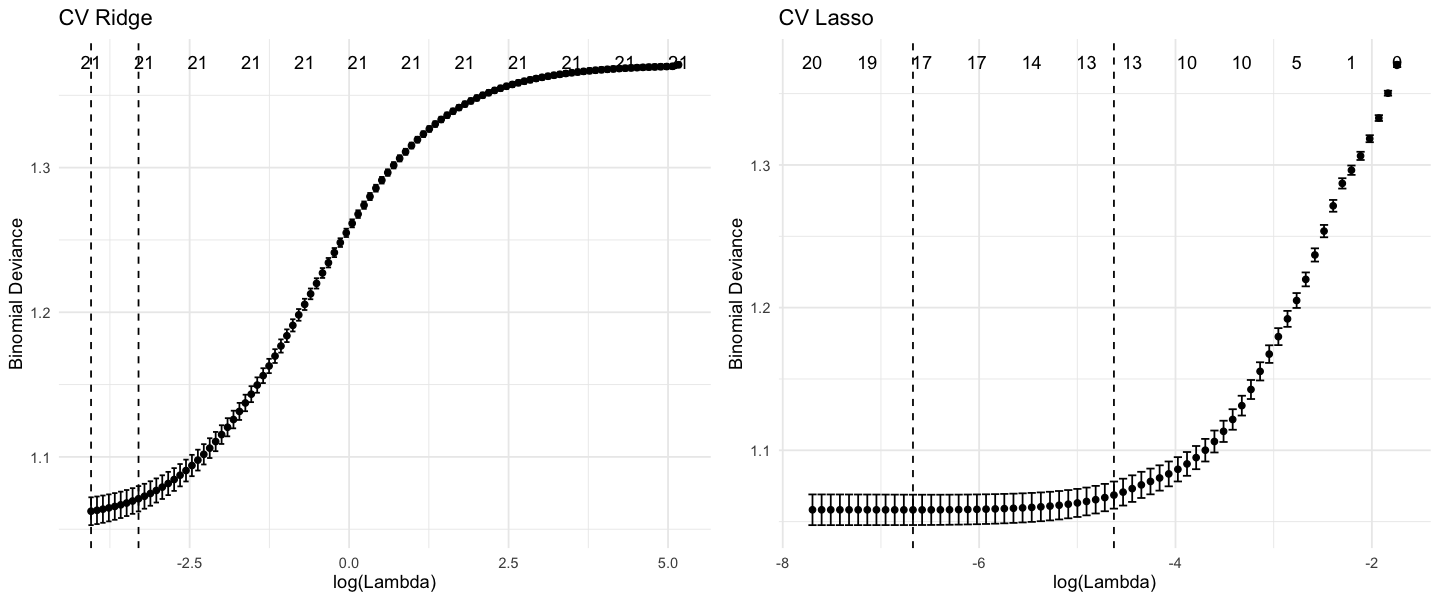

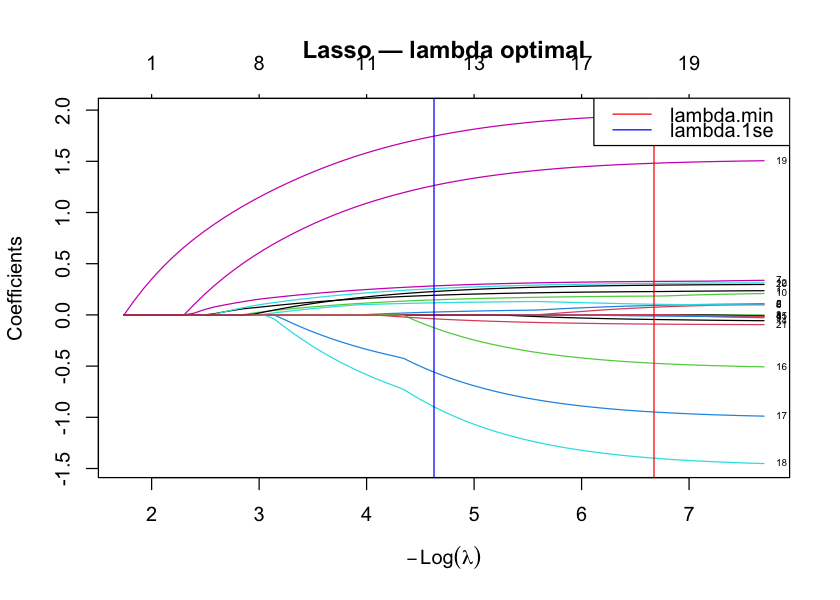

In [277]:
# Sélection de lambda par validation croisée 10-fold : 
# lambda.min : minimise l'erreur CV
# lambda.1se : erreur dans 1 écart-type du min → modèle plus simple
set.seed(111)
reg.ridge.cv <- cv.glmnet(y = y.train.num, x = x.mat, alpha = 0, family = "binomial", nfolds = 10)


set.seed(111)
reg.lasso.cv <- cv.glmnet(y = y.train.num, x = x.mat,alpha = 1, family = "binomial", nfolds = 10)

# visualisation de la validation croisée Ridge et Lasso
options(repr.plot.width = 12, repr.plot.height = 5)
p1 <- autoplot(reg.ridge.cv) + ggtitle("CV Ridge") + theme_minimal()
p2 <- autoplot(reg.lasso.cv) + ggtitle("CV Lasso") + theme_minimal()
grid.arrange(p1, p2, ncol = 2)

# valeurs de lambda retenues
paste("Ridge -lambda.min :", round(reg.ridge.cv$lambda.min, 5), " lambda.1se :", round(reg.ridge.cv$lambda.1se, 5))
paste("Lasso - lambda.min :", round(reg.lasso.cv$lambda.min, 5), " lambda.1se :", round(reg.lasso.cv$lambda.1se, 5))

# coefficients Lasso à lambda.min et lambda.1se
paste("CV estimate of lambda     :", round(reg.lasso.cv$lambda.min, 5))
coef(reg.lasso.cv, s = "lambda.min")
paste("CV estimate of lambda 1se :", round(reg.lasso.cv$lambda.1se, 5))
coef(reg.lasso.cv, s = "lambda.1se")

# visualisation du lambda choisi sur le chemin Lasso
options(repr.plot.width = 7, repr.plot.height = 5)
plot(reg.lasso, xvar = "lambda", label = TRUE, main = "Lasso — lambda optimal")
abline(v = -log(reg.lasso.cv$lambda.min), col = "red")
abline(v = -log(reg.lasso.cv$lambda.1se), col = "blue")
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 1)

Interprétation : 

- À lambda.min, le Lasso retient 17 variables en annulant Height_cm, Diastolic_BP et Cholesterol_Total : cohérent avec le stepwise. 
- À lambda.1se, il adopte un modèle plus parcimonieux en éliminant également Gender, Cholesterol_HDL et Alcohol_Consumption, soit 13 variables retenues : identique au stepwise BIC.

   alpha  cv_error      lambda
1    0.0 0.2636667 0.025390248
2    0.1 0.2629167 0.006003497
3    0.2 0.2632500 0.012118111
4    0.3 0.2632500 0.014117829
5    0.4 0.2630000 0.011620725
6    0.5 0.2631667 0.010202985
7    0.6 0.2630000 0.007058915
8    0.7 0.2630000 0.007998402
9    0.8 0.2630833 0.001902632
10   0.9 0.2630833 0.005164767
11   1.0 0.2631667 0.004648290


[1] "Alpha retenu : 0.1"

[1] "Lambda retenu: 0.006"

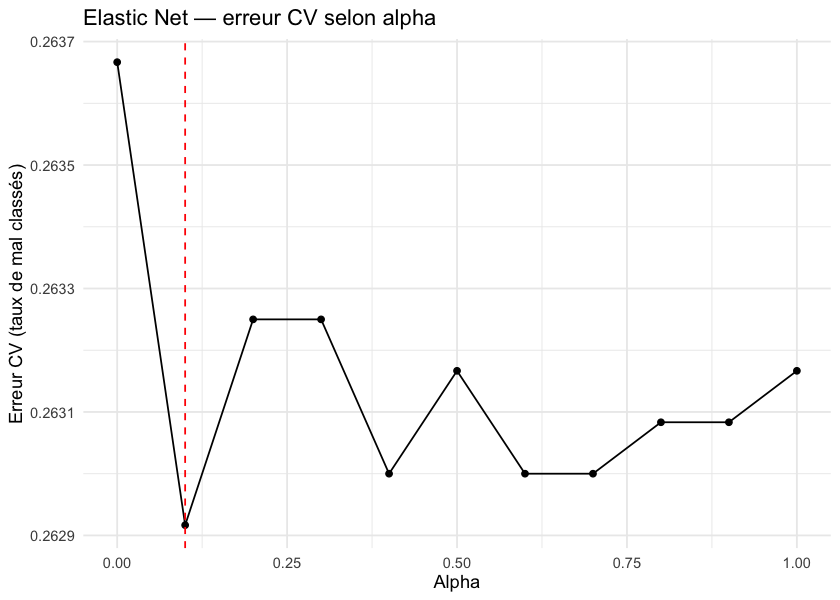

In [261]:
# Elastic Net : optimisation de alpha ET lambda par CV : 
# On teste une grille de valeurs d'alpha entre 0 (Ridge) et 1 (Lasso)
# et on retient le couple (alpha, lambda) qui minimise le taux de mal classés
set.seed(111)
alphas <- seq(0, 1, by = 0.1)
results.enet <- data.frame(alpha = alphas, cv_error = NA, lambda = NA)

for (i in seq_along(alphas)) {
  set.seed(111)
  cv_fit <- cv.glmnet(x.mat, y.train.num,
                      family = "binomial",
                      alpha = alphas[i],
                      nfolds = 10,
                      type.measure = "class")
  results.enet$cv_error[i]<- min(cv_fit$cvm)
  results.enet$lambda[i]   <- cv_fit$lambda.min
}

print(results.enet)

best.alpha  <- results.enet$alpha[which.min(results.enet$cv_error)]
best.lambda <- results.enet$lambda[which.min(results.enet$cv_error)]
paste("Alpha retenu :", best.alpha)
paste("Lambda retenu:", round(best.lambda, 5))

# visualisation de l'erreur CV selon alpha
options(repr.plot.width = 7, repr.plot.height = 5)
ggplot(results.enet, aes(x = alpha, y = cv_error)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best.alpha, col = "red", lty = 2) +
  labs(title = "Elastic Net — erreur CV selon alpha",
       x = "Alpha", y = "Erreur CV (taux de mal classés)") +
  theme_minimal()

# modèle final Elastic Net avec le meilleur alpha
set.seed(111)
reg.enet.cv <- cv.glmnet(x.mat, y.train.num,
                          family = "binomial",
                          alpha  = best.alpha,
                          nfolds = 10)

Interprétation : 

Le graphique montre que les erreurs CV sont très proches quelle que soit la valeur d'alpha (fourchette 0.2629 à 0.2637), ce qui indique que Ridge et Lasso donnent des résultats similaires sur ce dataset. L'alpha retenu est 0.1, très proche de Ridge, avec lambda = 0.006.

In [271]:
# Erreur apparente (train) : 
fit.ridge.train <- predict(reg.ridge.cv, s = "lambda.min", newx = x.mat, type = "response")[, 1]
fit.lasso.train<- predict(reg.lasso.cv, s = "lambda.min", newx = x.mat, type = "response")[, 1]
fit.enet.train  <-predict(reg.enet.cv,  s = "lambda.min", newx = x.mat, type = "response")[, 1]

table(fit.ridge.train > 0.5, train_df$Heart_Disease_Risk)
table(fit.lasso.train > 0.5, train_df$Heart_Disease_Risk)
table(fit.enet.train > 0.5, train_df$Heart_Disease_Risk)

       
           0    1
  FALSE 5510 1911
  TRUE  1230 3349

       
           0    1
  FALSE 5474 1878
  TRUE  1266 3382

       
           0    1
  FALSE 5468 1871
  TRUE  1272 3389

In [293]:
# Matrices de confusion et performances sur le test : 
pred.ridge<- predict(reg.ridge.cv, newx = x.mat.test, s = "lambda.min", type = "response")[, 1]
pred.lasso<- predict(reg.lasso.cv, newx = x.mat.test, s = "lambda.min",type = "response")[, 1]
pred.enet  <-predict(reg.enet.cv,newx = x.mat.test,s = "lambda.min", type = "response")[, 1]

table(pred.ridge > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Ridge :", round(mean((pred.ridge > 0.5) == (y.test.num == 1)), 4))
paste("AUC Ridge :", round(auc(roc(y.test.num, pred.ridge, quiet = TRUE)),4))

table(pred.lasso > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Lasso :", round(mean((pred.lasso > 0.5) == (y.test.num == 1)), 4))
paste("AUC Lasso :", round(auc(roc(y.test.num, pred.lasso, quiet = TRUE)),4))

table(pred.enet > 0.5, test_df$Heart_Disease_Risk)
paste("Accuracy Enet :", round(mean((pred.enet > 0.5) == (y.test.num == 1)), 4))
paste("AUC Enet :", round(auc(roc(y.test.num, pred.enet, quiet = TRUE)),4))

       
           0    1
  FALSE 1393  451
  TRUE   327  829

[1] "Accuracy Ridge : 0.7407"

[1] "AUC Ridge : 0.808"

       
           0    1
  FALSE 1384  435
  TRUE   336  845

[1] "Accuracy Lasso : 0.743"

[1] "AUC Lasso : 0.8086"

       
           0    1
  FALSE 1383  430
  TRUE   337  850

[1] "Accuracy Enet : 0.7443"

[1] "AUC Enet : 0.8085"

Interprétation performances Ridge / Lasso / Elastic Net : 

- Ridge : accuracy 0.7407, AUC 0.808
- Lasso : accuracy 0.743, AUC 0.8086
- Elastic Net (alpha=0.1) : accuracy 0.7443, AUC 0.8085

Les trois modèles sont comparables. L'erreur apparente train/test est stable pour les trois, confirmant **l'absence de surapprentissage.**

CONCLUSION :

Les trois méthodes de pénalisation donnent des performances quasi identiques, avec une AUC stable autour de 0.808. Le lambda optimal très faible pour Ridge (0.0175) et la quasi-platitude de la courbe Elastic Net selon alpha confirment que la pénalisation n'apporte pas de gain significatif sur ce dataset : les variables redondantes ont un impact marginal et le modèle logistique simple est déjà proche de son optimum. Le Lasso reste néanmoins intéressant pour sa capacité de sélection automatique, cohérente avec les résultats du stepwise.

### 3.4 Courbes ROC et comparaison finale 

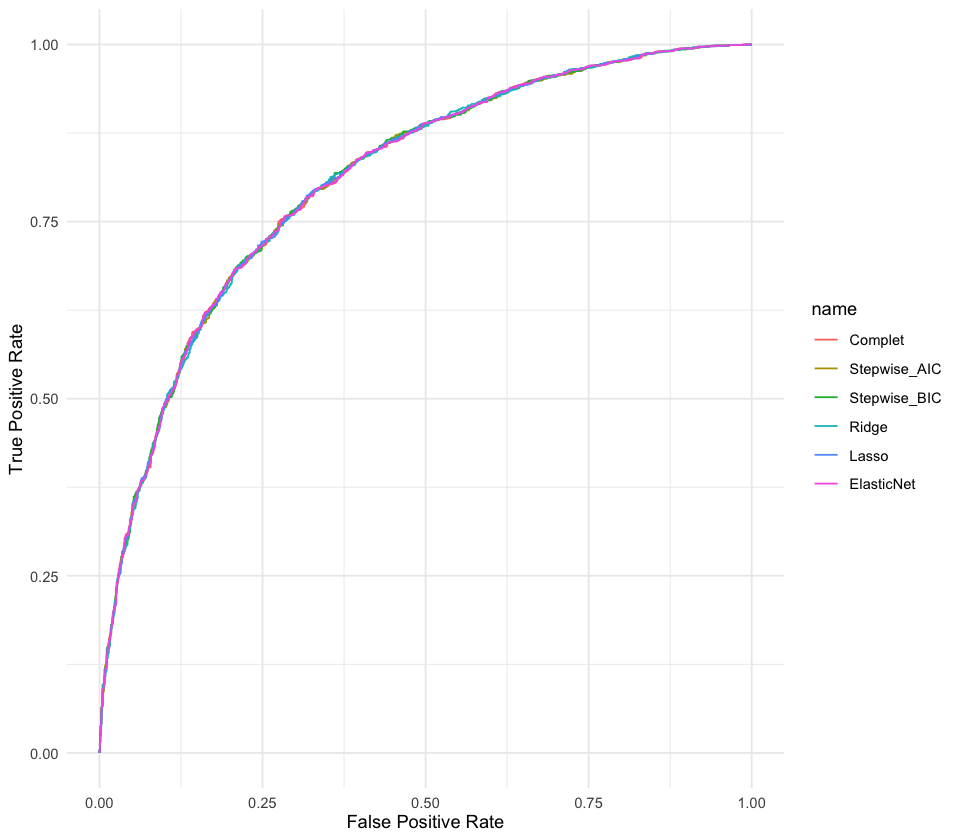

In [299]:
library(pROC)

# calcul des objets ROC pour tous les modèles
roc.aic <- roc(test_df$Heart_Disease_Risk, pred.step.aic, quiet = TRUE)
roc.bic <- roc(test_df$Heart_Disease_Risk, pred.step.bic, quiet = TRUE)
roc.ridge <- roc(y.test.num, pred.ridge, quiet = TRUE)
roc.lasso <- roc(y.test.num, pred.lasso, quiet = TRUE)
roc.enet <- roc(y.test.num, pred.enet, quiet = TRUE)

# graph courbes ROC superposées
options(repr.plot.width = 8, repr.plot.height = 7)
ggroc(list(
  Complet = roc.lm,
  Stepwise_AIC = roc.aic,
  Stepwise_BIC = roc.bic,
  Ridge = roc.ridge,
  Lasso = roc.lasso,
  ElasticNet = roc.enet
), legacy.axes = TRUE) +
  xlab("False Positive Rate") +
  ylab("True Positive Rate") +
  theme_minimal()

Interprétation : 

Les six courbes sont quasi superposées, ce qui confirme visuellement que tous les modèles linéaires ont **une capacité discriminante identique**. Aucune méthode ne se démarque des autres, que ce soit en termes de sélection de variables ou de pénalisation.

In [308]:
# tableau récapitulatif trié par AUC décroissante
resultats <- data.frame(
  Modele = c("Logistique complet", "Stepwise AIC", "Stepwise BIC","Ridge", "Lasso", "Elastic Net"),
  Nb_variables = c(
    length(coef(log.lm)) - 1,
    length(coef(log.lm.step.aic)) - 1,
    length(coef(log.lm.step.bic)) - 1,
    NA,
    sum(coef(reg.lasso.cv, s = "lambda.min") != 0) - 1,
    NA),
  Accuracy_train = round(c(
    mean((log.lm$fitted.values > 0.5) == (y.train.num == 1)),
    mean((log.lm.step.aic$fitted.values > 0.5) == (y.train.num == 1)),
    mean((log.lm.step.bic$fitted.values > 0.5) == (y.train.num == 1)),
    mean((fit.ridge.train > 0.5) == (y.train.num == 1)),
    mean((fit.lasso.train > 0.5) == (y.train.num == 1)),
    mean((fit.enet.train > 0.5) == (y.train.num == 1))
  ), 4),
  Accuracy_test = round(c(
    mean((pred.lm > 0.5) == (y.test.num == 1)),
    mean((pred.step.aic > 0.5) == (y.test.num == 1)),
    mean((pred.step.bic > 0.5) == (y.test.num == 1)),
    mean((pred.ridge > 0.5) == (y.test.num == 1)),
    mean((pred.lasso > 0.5) == (y.test.num == 1)),
    mean((pred.enet > 0.5) == (y.test.num == 1))
  ), 4),
  AUC = round(c(
    auc(roc.lm), auc(roc.aic), auc(roc.bic),
    auc(roc.ridge), auc(roc.lasso), auc(roc.enet)
  ), 4))

resultats[order(-resultats$AUC), ]

,Modele,Nb_variables,Accuracy_train,Accuracy_test,AUC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
3,Stepwise BIC,13,0.7385,0.7437,0.8089
5,Lasso,17,0.7380,0.7430,0.8086
6,Elastic Net,NA,0.7381,0.7443,0.8085
1,Logistique complet,20,0.7382,0.7450,0.8084
2,Stepwise AIC,14,0.7374,0.7450,0.8082
4,Ridge,NA,0.7382,0.7407,0.8080


Interprétation : 

Les accuracy train et test sont très proches pour tous les modèles, confirmant l'absence de surapprentissage.

CONCLUSION : 

L'ensemble des modèles linéaires converge vers une AUC d'environ 0.808 et une accuracy d'environ 0.74, indépendamment de la méthode utilisée. Ce résultat stable suggère que la frontière de décision est essentiellement linéaire sur ce problème, et que ni la sélection de variables ni la pénalisation n'apportent de gain significatif en termes de performance prédictive.
Si on ajoute une contrainte d'interprétabilité, le Stepwise BIC est le modèle à retenir : meilleure AUC (0.8089) avec seulement 13 variables, dont toutes sont médicalement interprétables via leurs odds ratios.
Ces résultats seront à comparer avec les modèles non linéaires du groupe pour quantifier l'éventuel gain apporté par des approches plus complexes.

### 3.5 Interprétation des coefs 

(Intercept)                      Age                Height_cm 
               0.6285333                1.2632171                0.8987726 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2659289                1.3978990                1.2090882 
     Fasting_Blood_Sugar          Smoking_Status1 Physical_Activity_Level1 
               1.3717251                7.3217840                0.5880970 
Physical_Activity_Level2 Physical_Activity_Level3          Family_History1 
               0.3625559                0.2269547                4.5545807 
            Stress_Level              Sleep_Hours 
               1.3506076                0.9065624

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),0.5703760,0.6924593
Age,1.2011720,1.3286779
Height_cm,0.8514754,0.9486240
Weight_kg,1.1971287,1.3389002
Systolic_BP,1.3318254,1.4675957
Cholesterol_LDL,1.1540707,1.2669000
Fasting_Blood_Sugar,1.3118915,1.4346079
Smoking_Status1,6.6381724,8.0836760
Physical_Activity_Level1,0.5243353,0.6594274
Physical_Activity_Level2,0.3202287,0.4102529


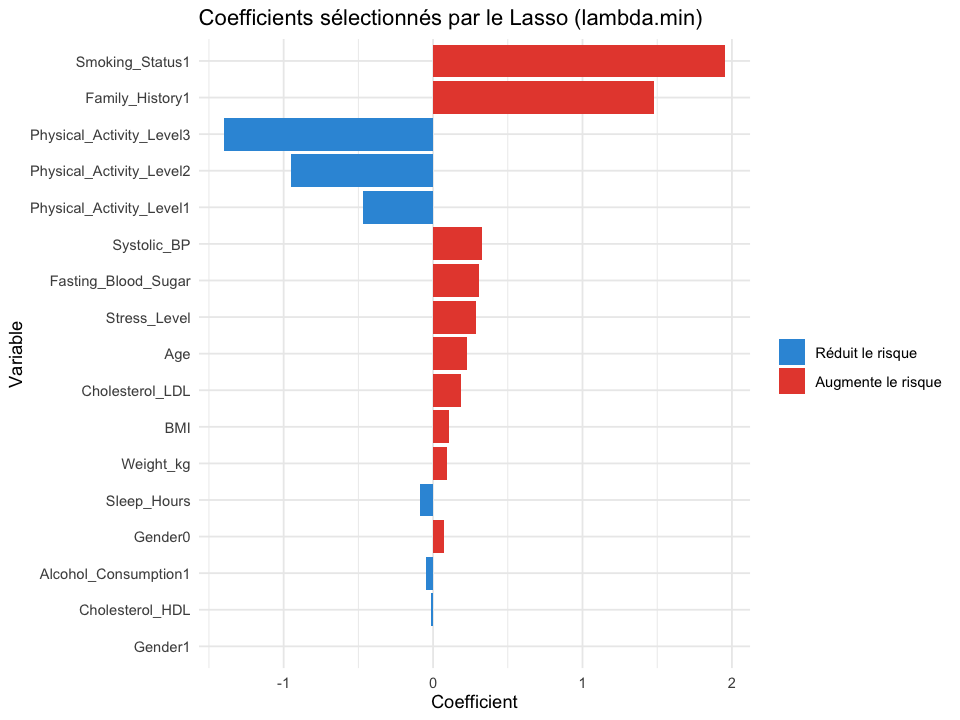

In [330]:
# odds ratios du modèle BIC (le plus parcimonieux)
# OR > 1 : augmente le risque cardiaque
# OR < 1 : réduit le risque cardiaque
exp(coef(log.lm.step.bic))
exp(confint(log.lm.step.bic))

# coefficients non nuls du Lasso à lambda.min 
# lambda.min pour la performance, lambda.1se pour la parcimonie et comme la parcimonie est déjà gérée par le BIC dans notre comparaison, 
# lambda.min est le choix cohérent pour les modèles pénalisés.
coef.lasso <- as.data.frame(as.matrix(coef(reg.lasso.cv, s = "lambda.min")))
colnames(coef.lasso) <- "Coefficient"
coef.lasso$Variable <- rownames(coef.lasso)
coef.lasso <- coef.lasso[coef.lasso$Coefficient != 0 & coef.lasso$Variable != "(Intercept)", ]
coef.lasso <- coef.lasso[order(abs(coef.lasso$Coefficient), decreasing = TRUE), ]

# graphique des coefficients
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(coef.lasso, aes(x = reorder(Variable, abs(Coefficient)),
y = Coefficient,
fill = Coefficient > 0)) +
geom_col() +
coord_flip() +
scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"),
labels = c("TRUE" = "Augmente le risque", "FALSE" = "Réduit le risque")) +
labs(title = "Coefficients sélectionnés par le Lasso (lambda.min)",
x = "Variable", y = "Coefficient", fill = "") +
  theme_minimal()

Interprétation : 

Les odds ratios confirment et quantifient les résultats déjà observés :

- Smoking_Status1 (OR = 7.32, IC : [6.38 ; 8.08]) : un fumeur a 7 fois plus de risque qu'un non-fumeur — variable la plus discriminante du dataset, avec un intervalle de confiance très resserré
- Family_History1 (OR = 4.55, IC : [4.03 ; 5.15]) : les antécédents familiaux multiplient le risque par 4.5
- Physical_Activity_Level3 (OR = 0.23, IC : [0.19 ; 0.27]) : le niveau d'activité physique le plus élevé divise le risque par plus de 4. c'est donc un fort effet protecteur
- Age, Systolic_BP, Fasting_Blood_Sugar, Stress_Level augmentent modérément le risque (OR entre 1.26 et 1.40)
- Sleep_Hours (OR = 0.91) et Height_cm (OR = 0.90) ont un léger effet protecteur

Tous les intervalles de confiance excluent 1, confirmant la significativité de chaque variable retenue


Interprétation graphique : 
Le graphique confirme la hiérarchie des variables. 
- Smoking_Status1 et Family_History1 dominent largement avec les coefficients les plus élevés en valeur absolue.
- Les variables en bas du graphique (Gender1, Cholesterol_HDL, Alcohol_Consumption1) ont des coefficients quasi nuls, le Lasso les conserve à peine, ce qui est cohérent avec leur non-significativité dans le modèle complet.

CONCLUSION : 

Les résultats sont pleinement cohérents avec l'analyse exploratoire et les connaissances médicales établies. **Le tabagisme et les antécédents familiaux** sont les facteurs de risque les plus forts, tandis que l'activité physique est le principal facteur protecteur. Cette interprétabilité directe via les odds ratios est un avantage clé des modèles linéaires par rapport aux approches non linéaires du groupe, et constitue une réponse concrète à la question des consignes : quel modèle retenir si on ajoute une contrainte d'interprétabilité ?
**le Stepwise BIC**


### 3.6 Conclusion Finale - Modèles Linéaires Généralisés

L'ensemble des modèles linéaires obtient des performances homogènes, avec une AUC comprise entre **0.808 et 0.809** et une accuracy autour de **0.74 sur l'échantillon test**. La comparaison des accuracy train et test ne révèle pas de surapprentissage significatif : les performances sont stables entre les deux échantillons, ce qui confirme la robustesse des modèles.

Concernant le choix de lambda.min plutôt que lambda.1se pour Ridge, Lasso et Elastic Net : dans un objectif de maximisation des performances prédictives, **lambda.min** est préféré car il minimise directement l'erreur de validation croisée. lambda.1se serait retenu si la priorité était la parcimonie maximale du modèle, ce que le stepwise BIC couvre déjà mieux dans notre cas.

La sélection de variables (stepwise BIC, Lasso) confirme les résultats de l'analyse exploratoire : les variables les plus discriminantes sont **le tabagisme, les antécédents familiaux, le niveau d'activité physique, la glycémie à jeun et la pression systolique.** Les variables morphologiques (taille, IMC, poids) et biologiques redondantes (cholestérol total, HDL, pression diastolique) apportent peu d'information supplémentaire.

(La comparaison avec les modèles non linéaires du groupe (SVM : AUC ≈ 0.796, LDA : AUC ≈ 0.735) montre que les modèles linéaires sont compétitifs, voire supérieurs sur ce jeu de données. Cela suggère que la frontière de décision est essentiellement linéaire et que la complexité additionnelle des modèles non linéaires n'apporte pas de gain significatif ici. Le tableau de comparaison global sera complété en fin de projet avec l'ensemble des résultats du groupe.) 
**A mettre en CCL finale**

## Prévision par Support Vector Machine : SVC pour Heart_Disease_Risk

Dans cette partie, l’objectif est de prédire s’il existe un risque de maladie cardiaque (variable Heart_Disease_Risk) avec la méthode SVM. Il s’agit d’un problème de classification binaire.

Nous testerons d'abord des SVC (Support Vecteur Classification) avec 4 noyaux différents : gaussien, linéaire, polynomial et radial; pour déterminer la meilleure méthode de classification à l'aide de l'accurancy et de l'AUC (Area Under the Curve).
Ensuite nous réaliserons quelques autres modèles d’apprentissage automatique : LDA (Analyse Discriminante Linéaire), QDA (Analyse Discriminante Quadratique), kNN (k plus proches voisins), afin d’analyser leurs performances respectives sur ce problème de prédiction et de les comparer avec les SVC.

**SVM : Noyau Gaussien**

In [11]:
set.seed(111) # initialisation du générateur
# Ajouter y_train pour svm()
X_train$Heart_Disease_Risk <- y_train
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

[1] "Valeur de cost retenu : 1"


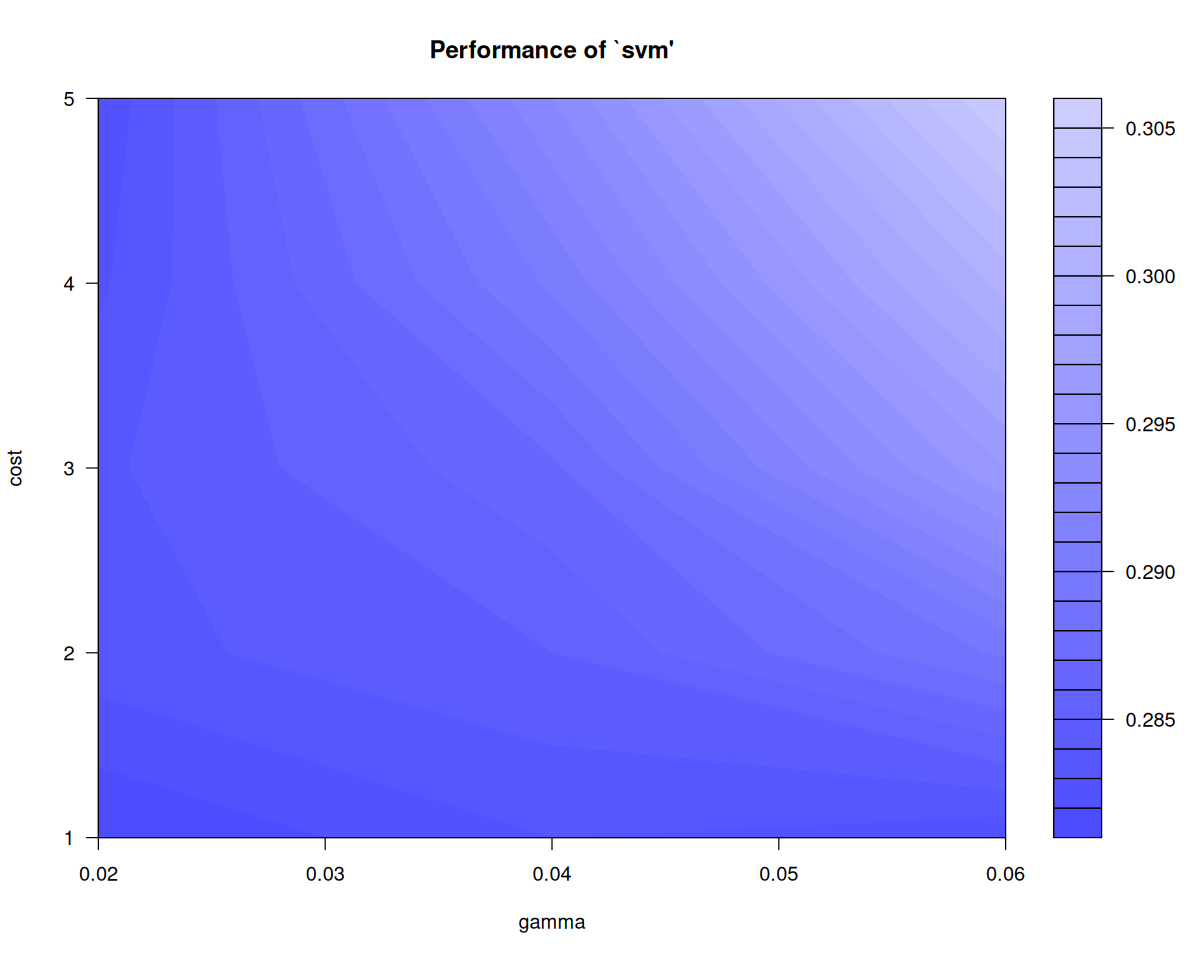

In [23]:
set.seed(111) 
# SVM avec noyau gaussien (RBF) : tune des hyperparamètres
QUICK <- FALSE

if (!QUICK){
    svm.tune <- tune.svm(
       Heart_Disease_Risk ~ .,
       data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
       cost  = c(1, 2, 3, 4, 5),
       gamma = seq(0.02, 0.06, by = 0.02),
       tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
     )
    plot(svm.tune)
    print(paste("Valeur de cost retenu : ", svm.tune$best.parameters$cost, sep=""))
} else {
  svm.tune <- list(best.parameters = list(cost = 1))
}

In [24]:
set.seed(111) 
# Modèle avec paramètres optimaux
svm.fit <- svm(
  Heart_Disease_Risk ~ .,
  data  = X_train,
  cost  = svm.tune$best.parameters$cost,
  gamma = svm.tune$best.parameters$gamma,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm <- predict(svm.fit, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm == y_test))) # accuracy


[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1402  480
        1  318  800

[1] "Accuracy du modèle : 0.734"


**SVM : Noyau Linéaire**

[1] "Valeur de cost retenu : 1"


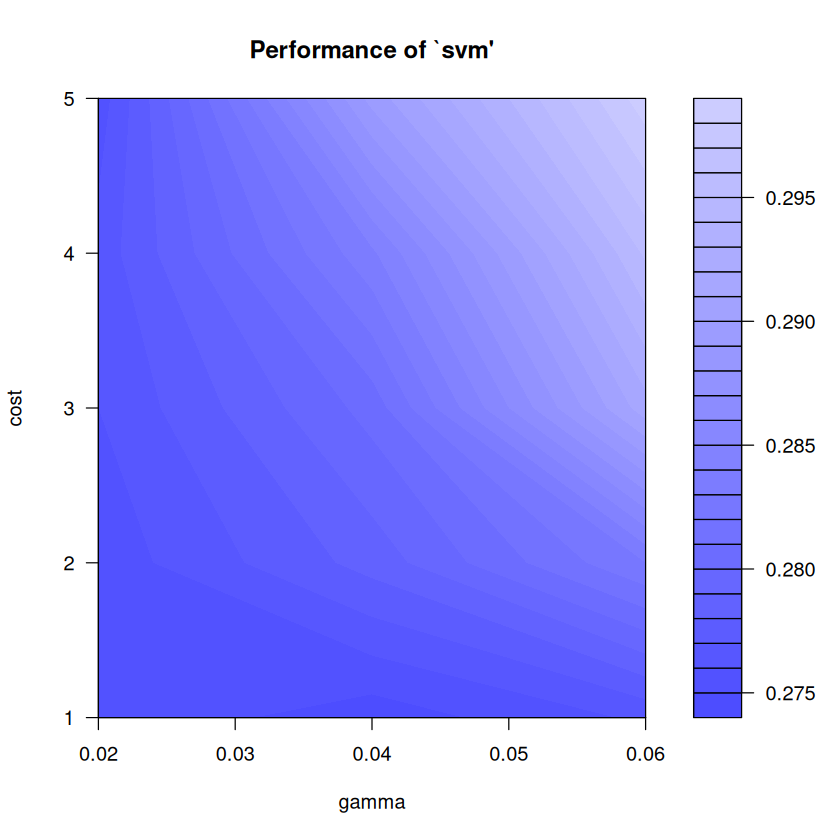

In [25]:
set.seed(111) 
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

# noyau linéaire 
QUICK <- FALSE

if (!QUICK) {
    svm.lin.tune <- tune.svm(
        Heart_Disease_Risk ~ .,
        data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
        cost  = c(1, 2, 3, 4, 5),
        gamma = seq(0.02, 0.06, by = 0.02),
        tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
    )
    plot(svm.lin.tune)
    print(paste("Valeur de cost retenu : ", svm.lin.tune$best.parameters$cost, sep=""))
} else {
  svm.lin.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}


In [26]:
set.seed(111) 
svm.lin <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "linear",
  cost = svm.lin.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.lin <- predict(svm.lin, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.lin, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.lin == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1375  436
        1  345  844

[1] "Accuracy du modèle : 0.739666666666667"


**SVM : Noyau polynomial**

[1] "Valeur de cost retenu : 3"
[1] "Valeur de gamma retenu : 0.06"
[1] "Valeur de degree retenu : 2"
[1] "Valeur de coef0 retenu : 0.5"


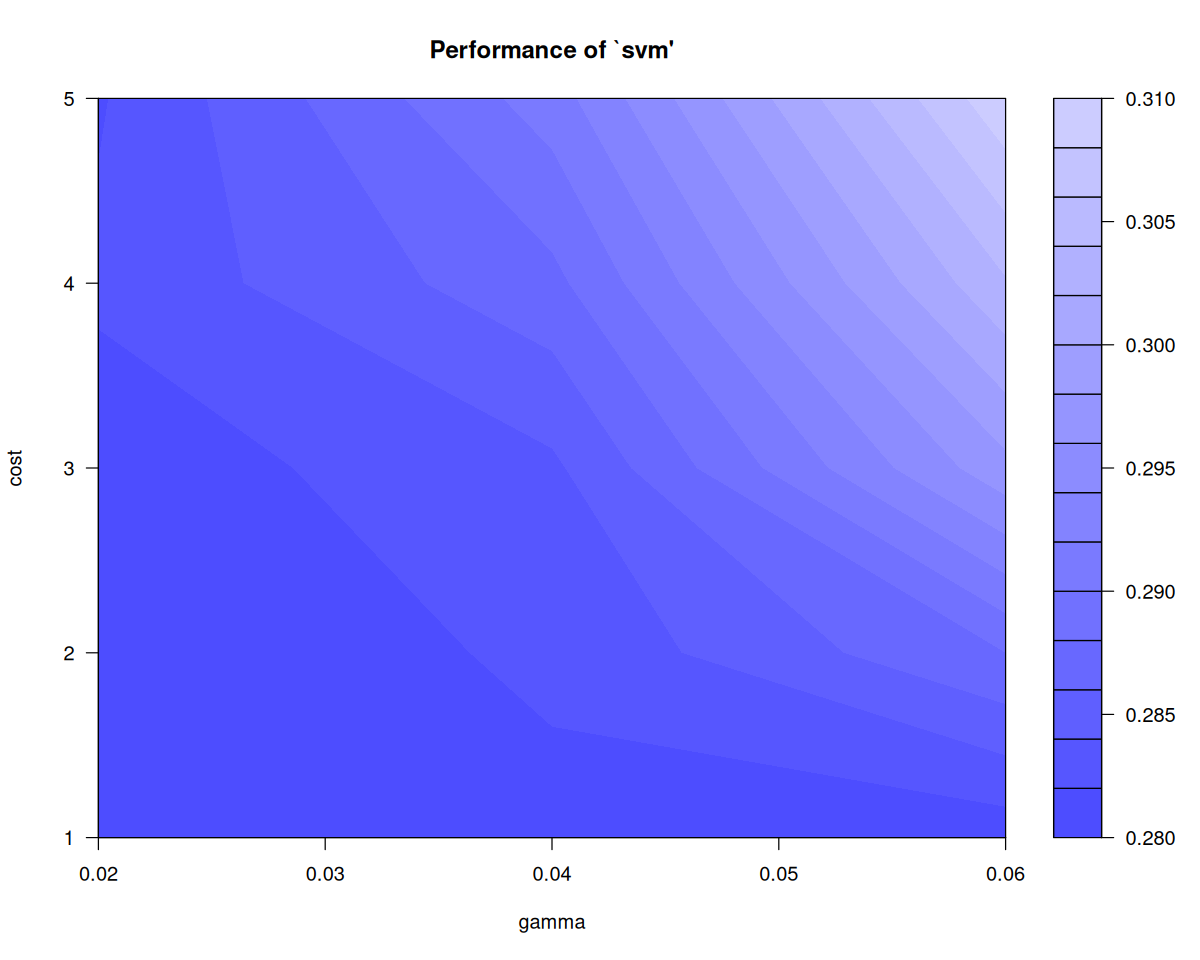

In [27]:
set.seed(111) 
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
  # Ajustement du modèle avec validation croisée
  svm.pol.tune <- tune.svm(Heart_Disease_Risk ~ ., 
                           data = X_train_small,
                           coef0 = c(0, 0.5, 1, 2),
                           degree = c(2, 3),
                           cost  = c(1, 2, 3, 4, 5),
                           gamma = seq(0.02, 0.06, by = 0.02),
                           tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
                           kernel = "polynomial"
    )
  print(paste("Valeur de cost retenu : ", svm.pol.tune$best.parameters$cost, sep=""))
  print(paste("Valeur de gamma retenu : ", svm.pol.tune$best.parameters$gamma, sep=""))
  print(paste("Valeur de degree retenu : ", svm.pol.tune$best.parameters$degree, sep=""))
  print(paste("Valeur de coef0 retenu : ", svm.pol.tune$best.parameters$coef0, sep=""))
  plot(svm.lin.tune) 
} else {
  svm.pol.tune <- list(best.parameters = list(cost = 1, gamma = 0.02, coef0=1, degree=2)) 
}

In [28]:
set.seed(111) 
svm.pol <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "polynomial",
  cost = svm.pol.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.pol <- predict(svm.pol, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.pol, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.pol == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1391  531
        1  329  749

[1] "Accuracy du modèle : 0.713333333333333"


**SVM : Noyau radial**

[1] "Valeur de cost retenu : 1"
[1] "Valeur de gamma retenu : 0.02"


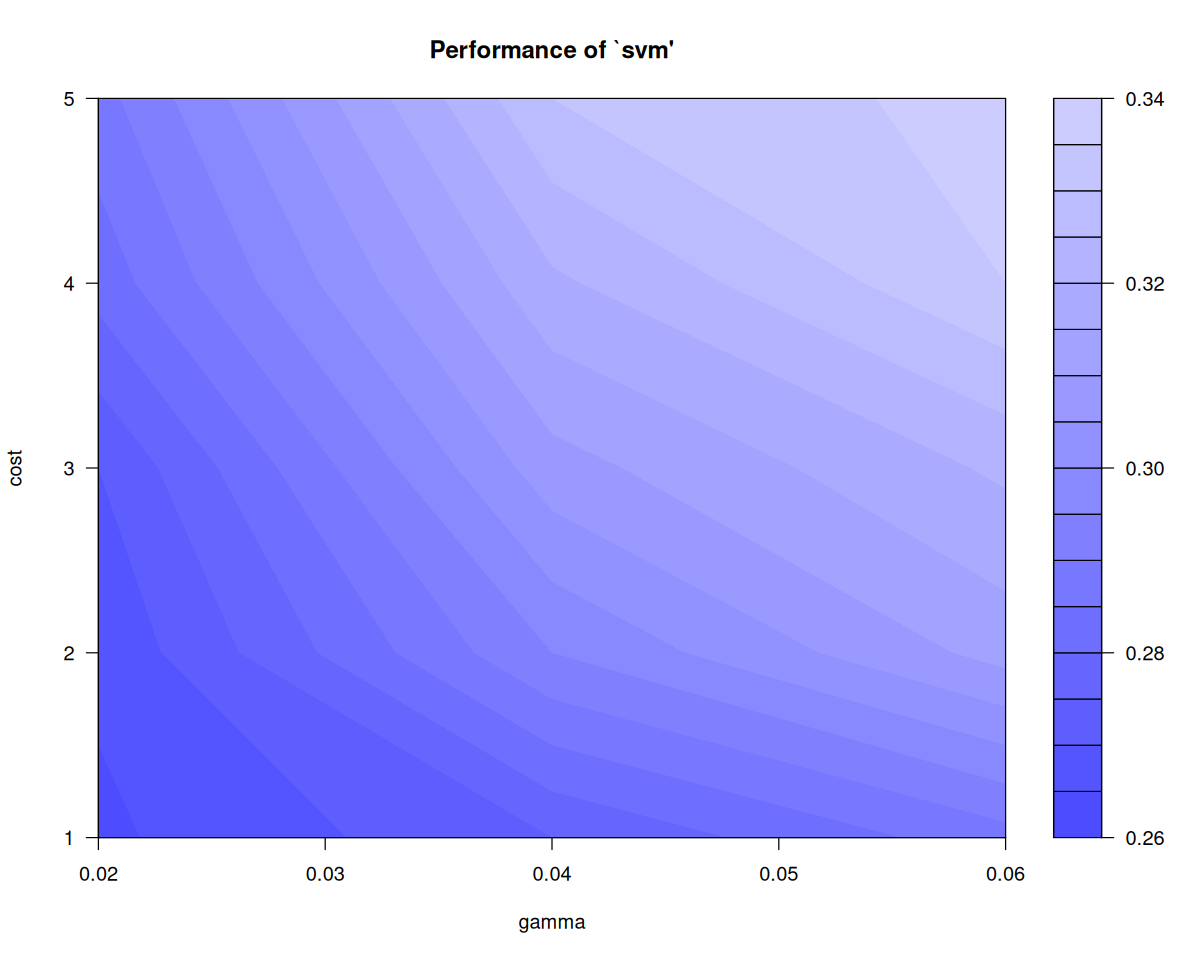

In [29]:
set.seed(111) 
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
    svm.rad.tune <- tune.svm(
      Heart_Disease_Risk ~ .,
      data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
      cost  = c(1, 2, 3, 4, 5),
      gamma = seq(0.02, 0.06, by = 0.02),
      tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
      kernel = "radial"
    )
    plot(svm.rad.tune)
    print(paste("Valeur de cost retenu : ", svm.rad.tune$best.parameters$cost, sep=""))
    print(paste("Valeur de gamma retenu : ", svm.rad.tune$best.parameters$gamma, sep=""))

} else {
  svm.rad.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}

In [30]:
set.seed(111) 
svm.rad <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "radial",
  cost = svm.rad.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.rad <- predict(svm.rad, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.rad, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.rad == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1392  495
        1  328  785

[1] "Accuracy du modèle : 0.725666666666667"


**Courbes ROC**

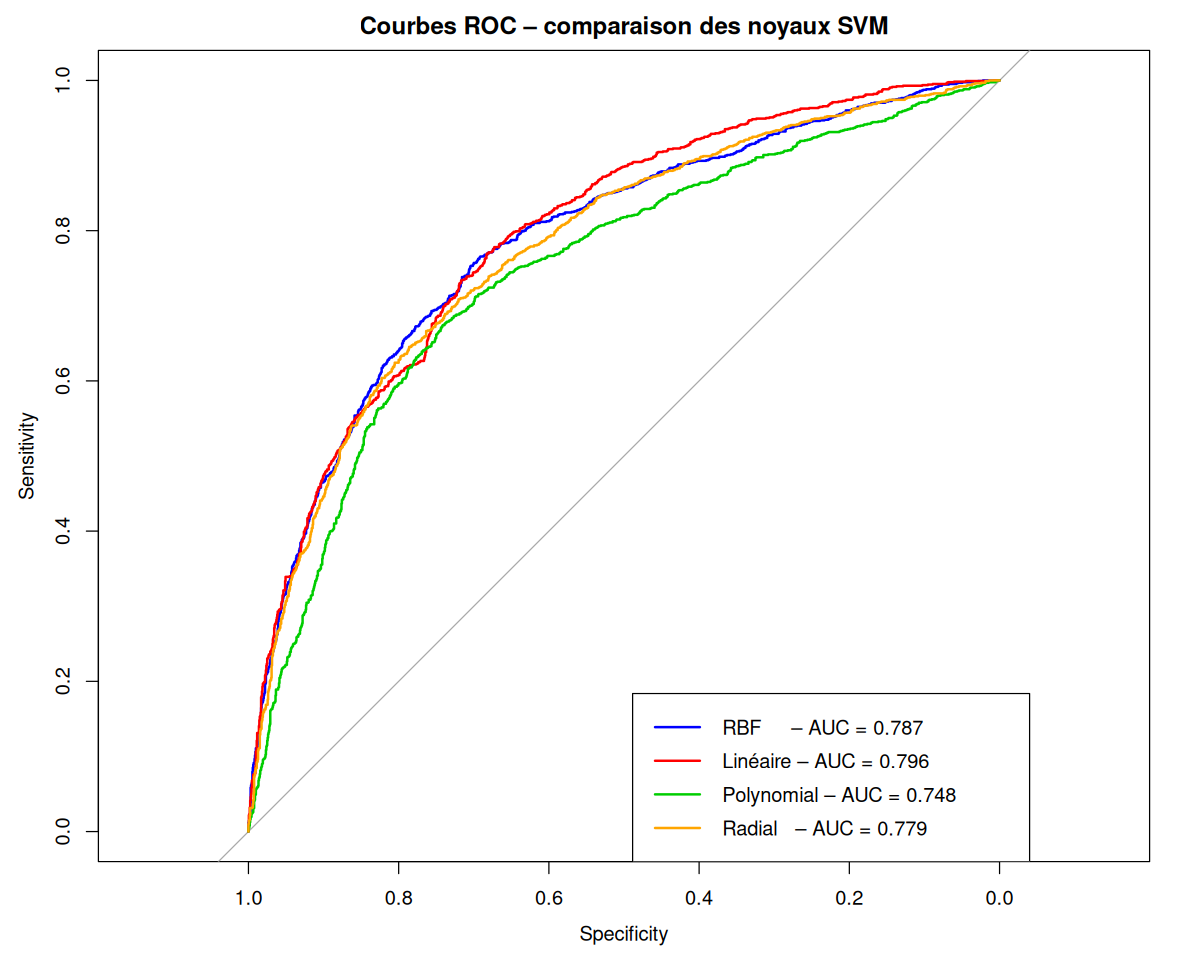

In [31]:
set.seed(111) 
# Probabilités de chaque modèle
proba_rbf  <- attr(pred_svm,     "probabilities")[, "1"]
proba_lin  <- attr(pred_svm.lin, "probabilities")[, "1"]
proba_pol  <- attr(pred_svm.pol, "probabilities")[, "1"]
proba_rad  <- attr(pred_svm.rad, "probabilities")[, "1"]

# ROC
roc_rbf <- roc(response = y_test, predictor = proba_rbf, levels = c("0","1"), direction = "<")
roc_lin <- roc(response = y_test, predictor = proba_lin, levels = c("0","1"), direction = "<")
roc_pol <- roc(response = y_test, predictor = proba_pol, levels = c("0","1"), direction = "<")
roc_rad <- roc(response = y_test, predictor = proba_rad, levels = c("0","1"), direction = "<")

# Plot
plot(roc_rbf, col = "blue",   lwd = 2, main = "Courbes ROC – comparaison des noyaux SVM")
plot(roc_lin, col = "red",    lwd = 2, add = TRUE)
plot(roc_pol, col = "green3", lwd = 2, add = TRUE)
plot(roc_rad, col = "orange", lwd = 2, add = TRUE)

legend("bottomright",
  legend = c(
    paste0("RBF     – AUC = ", round(auc(roc_rbf), 3)),
    paste0("Linéaire – AUC = ", round(auc(roc_lin), 3)),
    paste0("Polynomial – AUC = ", round(auc(roc_pol), 3)),
    paste0("Radial   – AUC = ", round(auc(roc_rad), 3))
  ),
  col = c("blue","red","green3","orange"),
  lwd = 2
)

#### Choix du noyau : 

L'ensemble des codes ci-dessus permet de comparer les classifications des SVC avec différents noyaux à l'aide de l'**AUC**, qui mesure la capacité du modèle à distinguer les deux classes sur l'ensemble des seuils de décision. Contrairement à l'**accuracy**, qui ne représente que la proportion globale de prédictions correctes à un seuil fixe, l'AUC est un critère plus fiable car elle reste indépendante du seuil de classification choisi. Cette robustesse est cruciale dans un contexte médical où l'objectif est de limiter les faux négatifs (patients malades non détectés), rendant l'AUC souvent plus pertinente qu'un simple taux de réussite global.

Le modèle avec la meilleure précision (accuracy) est le modèle avec noyau gaussien : "Accuracy du modèle : 0.734", sa matrice de confusion a moins d'individus mal classés (hors diagonale).
En regardant l'AUC, c'est le noyau linéaire qui donne les meilleures performances, mais les AUC restent proches entre les modèles. On pourrait donc aussi choisir le noyau gaussien.

### Analyse en plus : 

Maintenant, nous allons aussi évaluer et comparer plusieurs autres modèles d’apprentissage automatique : LDA (Analyse Discriminante Linéaire), QDA (Analyse Discriminante Quadratique), kNN (k plus proches voisins), afin d’analyser leurs performances respectives sur ce problème de prédiction.

**1. Analyse discriminante linéaire**

Cette méthode cherche à projeter les données dans un espace de plus faible dimension tout en maximisant la séparation entre les classes, en supposant que chaque classe suit une distribution gaussienne avec une même matrice de covariance. La LDA n'offre pas de possibilité d'ajustement avec des hyperparamètres. Nous pouvons tout de même avoir accès à sa précision, et le *Cohen’s Kappa* (qui compare la précision du modèle à ce qu’on obtiendrait par un classement aléatoire).

In [32]:
set.seed(111) 
# analyse discriminante linéaire
lda_model <- lda(Heart_Disease_Risk ~ ., data = X_train_small)

pred_lda <- predict(lda_model, X_test)$class

# matrice de confusion correcte
table(Predicted = pred_lda, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_lda == y_test))) 

         Actual
Predicted    0    1
        0 1382  456
        1  338  824

[1] 0.7353333

**2. Analyse discriminante quadratique**

Nous comparons ensuite les performances de l'Analyse Discriminante Quadratique (QDA). Contrairement au LDA, le QDA relaxe l'hypothèse d'une covariance commune et autorise des frontières de décision quadratiques, ce qui lui permet de modéliser des structures de données plus complexes et non linéaires.

In [33]:
set.seed(111) 
# analyse discriminante quadratique 
qda_model <- qda(Heart_Disease_Risk ~ ., data = X_train_small)

pred_qda <- predict(qda_model, X_test)$class

# matrice de confusion correcte
table(Predicted = pred_qda, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_qda == y_test))) 

         Actual
Predicted    0    1
        0 1337  453
        1  383  827

[1] 0.7213333

**3. k plus proches voisins**

Enfin, nous testons l'algorithme des k plus proches voisins (kNN). Il s'agit d'une approche non paramétrique qui classe une nouvelle observation en fonction de la majorité des étiquettes de ses k voisins les plus proches dans l'espace des caractéristiques, sans construire de modèle explicite préalable.

In [37]:
set.seed(111) 
train_x <- X_train_small[, -which(names(X_train_small) == "Heart_Disease_Risk")] # train features
test_x <- X_test # test features
train_y <- X_train_small$Heart_Disease_Risk # train target

# prédiction KNN
pred_knn <- knn(
  train = train_x,
  test  = test_x,
  cl    = train_y,
  k = 10
)

# matrice de confusion
table(Predicted = pred_knn, Actual = y_test)

# accuracy
print(paste("Accuracy du modèle :", mean(pred_knn == y_test))) 

         Actual
Predicted    0    1
        0 1288  668
        1  432  612

[1] 0.6333333

In [40]:
set.seed(111) 
# Prédictions de classe (les predict() sans probability retournent directement les classes)
acc_rbf <- mean(pred_svm     == y_test)
acc_lin <- mean(pred_svm.lin == y_test)
acc_pol <- mean(pred_svm.pol == y_test)
acc_rad <- mean(pred_svm.rad == y_test)
acc_lda <- mean(pred_lda     == y_test)
acc_qda <- mean(pred_qda     == y_test)
acc_knn <- mean(pred_knn     == y_test)

# Tableau récapitulatif
resultats <- data.frame(
  Modèle   = c("SVM – RBF (gaussien)", "SVM – Linéaire", 
                "SVM – Polynomial", "SVM – Radial",
                "LDA", "QDA", "kNN (k=10)"),
  Accuracy  = round(c(acc_rbf, acc_lin, acc_pol, acc_rad,
                       acc_lda, acc_qda, acc_knn), 4),
  AUC       = round(c(auc(roc_rbf), auc(roc_lin), auc(roc_pol), auc(roc_rad),
                       NA, NA, NA), 4)  # AUC non calculée pour LDA/QDA/kNN ici
)

# Tri du meilleur au moins bon
resultats <- resultats[order(-resultats$Accuracy), ]

print(resultats)

                Modèle Accuracy    AUC
5                  LDA   0.7353     NA
1 SVM – RBF (gaussien)   0.7340 0.7870
4         SVM – Radial   0.7257 0.7789
6                  QDA   0.7213     NA
3     SVM – Polynomial   0.7133 0.7477
2       SVM – Linéaire   0.7070 0.7958
7           kNN (k=10)   0.6333     NA


Le tableau des résultats montre que la SVC avec noyau linéaire est la plus performante selon l'AUC, ce qui signifie qu'elle distingue le mieux les deux classes dans l'ensemble. Cependant, cette même méthode obtient l'accuracy la plus faible (0,707), tandis que les autres modèles atteignent jusqu'à 0,735.

En résumé, le noyau linéaire est plus fiable pour la discrimination globale, mais il fait plus d'erreurs de classification à un seuil fixe que les autres algorithmes.


**nb :** Il existe une deuxième méthode plus concise pour la sélection du noyau avec la librairie caret : 

In [41]:
set.seed(111) 
X_train$Heart_Disease_Risk <- make.names(X_train$Heart_Disease_Risk)
X_train$Heart_Disease_Risk <- factor(X_train$Heart_Disease_Risk)

X_test$Heart_Disease_Risk <- factor(
  X_test$Heart_Disease_Risk,
  levels = c(0, 1),
  labels = c("No", "Yes")
)

ERROR: Error in `$<-.data.frame`(`*tmp*`, Heart_Disease_Risk, value = structure(integer(0), levels = c("No", : le tableau de remplacement a 0 lignes, le tableau remplacé en a 3000


In [44]:
set.seed(111) 
X_train_caret <- na.omit(X_train_caret) # car certaines combinaisons d’hyperparamètres ne convergent pas correctement dans kernlab

# Recréer un data.frame complet pour caret
set.seed(111)
idx <- sample(nrow(X_train), 5000)

X_train_caret <- X_train[idx, ]

X_train_caret$Heart_Disease_Risk <- factor(
  y_train[idx],
  levels = c(0, 1),
  labels = c("No", "Yes")
)

# Contrôle CV
cvControl <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  summaryFunction = twoClassSummary
)

# Grilles
methodes_svm <- list(
  list(method = "svmRadial", tuneGrid = expand.grid(
    sigma = c(0.001, 0.005),
    C = c(0.5, 1)
  )),
  list(method = "svmLinear", tuneGrid = expand.grid(
    C = c(0.5, 1, 2)
  )),
  list(method = "svmPoly", tuneGrid = expand.grid(
    degree = c(2),
    scale = c(0.01),
    C = c(0.5, 1)
  ))
)

# Entraînement
resultats <- lapply(methodes_svm, function(m) {
  set.seed(111)
  
  fit <- train(
  Heart_Disease_Risk ~ .,
  data      = X_train_caret,
  method    = m$method,
  tuneGrid  = m$tuneGrid,
  trControl = cvControl,
  metric    = "ROC",
  preProcess = c("center", "scale")
)
  
  list(
    method = m$method,
    best   = fit$bestTune,
    auc    = max(fit$results$ROC)
  )
})

# Tableau comparatif
res_df <- do.call(rbind, lapply(resultats, function(r)
  data.frame(
    Noyau = r$method,
    AUC   = round(r$auc, 4)
  )
))

print(res_df)

line search fails -1.360547 -0.0910251 2.074404e-05 3.478137e-06 -4.212842e-08 -1.44804e-08 -9.242784e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class prediction calculations failed; returning NAs”
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class probability calculations failed; returning NAs”
Warning message in data.frame(..., check.names = FALSE):
“les noms de lignes sont trouvés dans une variable courte et ont été éliminés”


line search fails -1.359088 -0.07817778 1.677166e-05 2.545066e-06 -3.429689e-08 -1.105436e-08 -6.0335e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class prediction calculations failed; returning NAs”
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class probability calculations failed; returning NAs”
Warning message in data.frame(..., check.names = FALSE):
“les noms de lignes sont trouvés dans une variable courte et ont été éliminés”


line search fails -1.369394 -0.09575002 1.6378e-05 2.879643e-06 -3.408671e-08 -1.186949e-08 -5.924521e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class prediction calculations failed; returning NAs”
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class probability calculations failed; returning NAs”
Warning message in data.frame(..., check.names = FALSE):
“les noms de lignes sont trouvés dans une variable courte et ont été éliminés”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


line search fails -1.1801 -0.03381819 1.197073e-05 2.051235e-06 -1.892326e-08 -6.841053e-09 -2.405577e-13

Warning message in method$predict(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class prediction calculations failed; returning NAs”
Warning message in method$prob(modelFit = modelFit, newdata = newdata, submodels = param):
“kernlab class probability calculations failed; returning NAs”
Warning message in data.frame(..., check.names = FALSE):
“les noms de lignes sont trouvés dans une variable courte et ont été éliminés”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


      Noyau    AUC
1 svmRadial 0.8024
2 svmLinear 0.8052
3   svmPoly 0.8032


Les résultats obtenus avec la librairie caret confirment ceux de l'analyse précédente, tout en offrant un temps d'exécution nettement réduit. Le noyau linéaire se distingue légèrement avec une AUC d'environ 0,805, bien que les trois noyaux affichent des performances globalement comparables. Il est à noter que le noyau polynomial est moins stable numériquement par rapport aux deux autres.

L'optimisation des hyperparamètres (Tuning) a déjà été faite précédemment : best_cost = 1 et best_gamma = 0.02.

In [22]:
best_cost    <- 1
best_gamma   <- 0.02

# Entrainement final (sur tout X_train avec les meilleurs paramètres)

cat("\n>>> Entraînement final du SVM linéaire...\n")

svm.lin.final <- svm(
  Heart_Disease_Risk ~ .,
  data        = X_train,  # Entraînement sur tout le jeu d'entraînement
  kernel      = "linear",
  cost        = best_cost,
  gamma       = best_gamma,
  probability = TRUE
)

cat(">>> Modèle entraîné.\n")
print(summary(svm.lin.final))


>>> Entraînement final du SVM linéaire...
>>> Modèle entraîné.

Call:
svm(formula = Heart_Disease_Risk ~ ., data = X_train, kernel = "linear", 
    cost = best_cost, gamma = best_gamma, probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  linear 
       cost:  1 

Number of Support Vectors:  7211

 ( 3608 3603 )


Number of Classes:  2 

Levels: 
 0 1






>>> Évaluation sur le jeu de test...

--- Matrice de confusion ---
Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 1383  462
         1  337  818
                                          
               Accuracy : 0.7337          
                 95% CI : (0.7175, 0.7494)
    No Information Rate : 0.5733          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.4487          
                                          
 Mcnemar's Test P-Value : 1.15e-05        
                                          
            Sensitivity : 0.8041          
            Specificity : 0.6391          
         Pos Pred Value : 0.7496          
         Neg Pred Value : 0.7082          
             Prevalence : 0.5733          
         Detection Rate : 0.4610          
   Detection Prevalence : 0.6150          
      Balanced Accuracy : 0.7216          
                                          

Setting direction: controls < cases




>>> AUC : 0.8051 


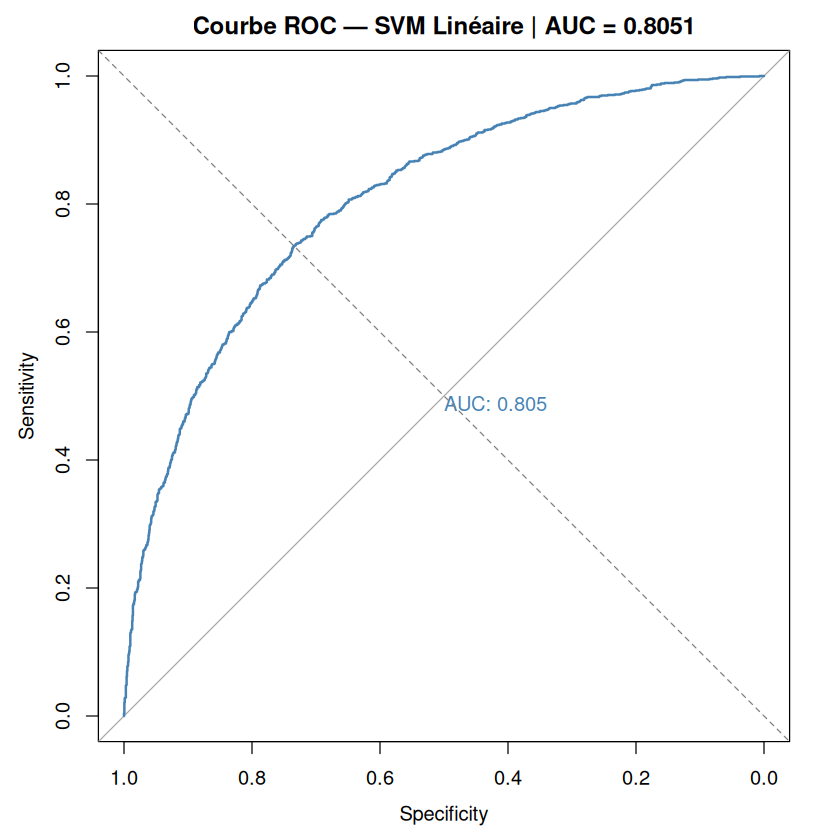

In [20]:
# Evaluation sur le jeu de test 

cat("\n>>> Évaluation sur le jeu de test...\n")

# Prédictions (classes + probabilités)
pred_svm.lin       <- predict(svm.lin.final, newdata = X_test, probability = TRUE)
pred_svm.lin.proba <- attr(pred_svm.lin, "probabilities")

# Matrice de confusion
cat("\n--- Matrice de confusion ---\n")
conf_matrix <- confusionMatrix(
  factor(pred_svm.lin, levels = levels(y_test)),
  factor(y_test,        levels = levels(y_test))
)
print(conf_matrix)

# Métriques détaillées
accuracy  <- conf_matrix$overall["Accuracy"]
precision <- conf_matrix$byClass["Pos Pred Value"]
recall    <- conf_matrix$byClass["Sensitivity"]
f1        <- conf_matrix$byClass["F1"]
kappa     <- conf_matrix$overall["Kappa"]

cat("\n--- Métriques de performance ---\n")
cat(paste("Accuracy  :", round(accuracy,  4), "\n"))
cat(paste("Precision :", round(precision, 4), "\n"))
cat(paste("Recall    :", round(recall,    4), "\n"))
cat(paste("F1-Score  :", round(f1,        4), "\n"))
cat(paste("Kappa     :", round(kappa,     4), "\n"))

# Courbe ROC & AUC
# On récupère la probabilité de la classe positive
pos_class      <- levels(y_test)[2]
proba_positive <- pred_svm.lin.proba[, pos_class]

roc_svm.lin <- roc(
  response  = y_test,
  predictor = proba_positive,
  levels    = levels(y_test)
)

cat(paste("\n>>> AUC :", round(auc(roc_svm.lin), 4), "\n"))

plot(roc_svm.lin,
     col  = "steelblue",
     lwd  = 2,
     main = paste("Courbe ROC — SVM Linéaire | AUC =", round(auc(roc_svm.lin), 4)),
     print.auc = TRUE)
abline(a = 0, b = 1, lty = 2, col = "gray50")

## Prévision par arbre optimal

## Prévision par forêt aléatoire

## Prévision par boosting

## Prévision par réseaux de neurones

Nous entraînons un réseau de neurones à une couche cachée via la fonction nnet en R.  
L'ajustement des hyperparamètres porte sur deux paramètres clés : size (nombre de neurones dans la couche cachée) et decay (paramètre de régularisation L2, contrôlant le surapprentissage).  La recherche des hyperparamètres optimaux se déroule en deux étapes : une optimisation grossière explorant un large espace de paramètres, suivie d'une optimisation fine resserrée autour des meilleures valeurs identifiées. Le modèle final est ensuite entraîné avec les paramètres optimaux et ses performances sont estimées sur l'échantillon test.

### Classification du risque de maladie cardiovasculaire 


In [77]:
# Pour classification (Heart_Disease_Risk prediction)
datappr_classif <- datappr  # already scaled
datappr_classif$Heart_Disease_Risk <- as.factor(data[appri, 19])

datestr_classif <- datestr
datestr_classif$Heart_Disease_Risk <- as.factor(data[testi, 19])

# Supprimer Patient_ID des deux datasets
datappr_classif$Patient_ID <- NULL
datestr_classif$Patient_ID <- NULL

str(datappr)
str(datestr)


'data.frame':	12000 obs. of  18 variables:
 $ Patient_ID             : chr  "PID-00001" "PID-00002" "PID-00003" "PID-00004" ...
 $ Age                    : num  0.455 -0.13 0.622 1.541 -0.214 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  -2.006 -0.384 1.021 0.868 -0.623 ...
 $ Weight_kg              : num  -1.701 0.104 1.232 -0.445 -1.059 ...
 $ BMI                    : num  -0.882 0.463 0.707 -1.103 -0.907 ...
 $ Systolic_BP            : num  0.4318 -0.6293 0.5202 0.0781 -0.0987 ...
 $ Diastolic_BP           : num  -0.181 -1.125 1.118 0.646 0.173 ...
 $ Cholesterol_Total      : num  0.034 -0.583 -1.904 -1.023 0.386 ...
 $ Cholesterol_LDL        : num  0.593 -1.189 -0.911 -1.301 0.815 ...
 $ Cholesterol_HDL        : num  1.461 -0.889 0.286 0.286 0.789 ...
 $ Fasting_Blood_Sugar    : num  -1.094 1.074 -0.634 -1.226 0.22 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Con

In [78]:
# Vérifier la nature et les niveaux
class(datappr_classif$Heart_Disease_Risk)
levels(datappr_classif$Heart_Disease_Risk)


[1] "factor"

[1] "0" "1"

### Première optimisation grossière

Cette première optimisation explore large espace des hyperparamètres pour identifier les zones prometteuses où l'erreur de validation croisée est minimale.  

Deux hyperparamètres sont optimisés dans cette étape. 
* Le premier est size, qui correspond au nombre de neurones dans la couche cachée du réseau.
* Le second est decay, un paramètre de régularisation L2 qui permet de lutter contre le surapprentissage.
 
Quatre valeurs sont testées pour chaque paramètre : 2, 5, 8 et 10 pour size ; 0.001, 0.01, 0.1 et 1 pour decay.


Parameter tuning of ‘nnet’:

- sampling method: 5-fold cross validation 

- best parameters:
 size decay
    2  0.01

- best performance: 0.2631667 

- Detailed performance results:
   size decay     error  dispersion
1     2 0.001 0.2667500 0.011205158
2     5 0.001 0.2710000 0.007480298
3     8 0.001 0.2779167 0.008217951
4    10 0.001 0.2857500 0.008392498
5     2 0.010 0.2631667 0.009747685
6     5 0.010 0.2677500 0.010955244
7     8 0.010 0.2761667 0.005029427
8    10 0.010 0.2840000 0.007262441
9     2 0.100 0.2660000 0.010187479
10    5 0.100 0.2665833 0.007896905
11    8 0.100 0.2739167 0.005225804
12   10 0.100 0.2770833 0.007389228
13    2 1.000 0.2636667 0.008855515
14    5 1.000 0.2661667 0.009097275
15    8 1.000 0.2686667 0.007554202
16   10 1.000 0.2712500 0.004592793


,size,decay
,<dbl>,<dbl>
5,2,0.01


[1] 0.2631667

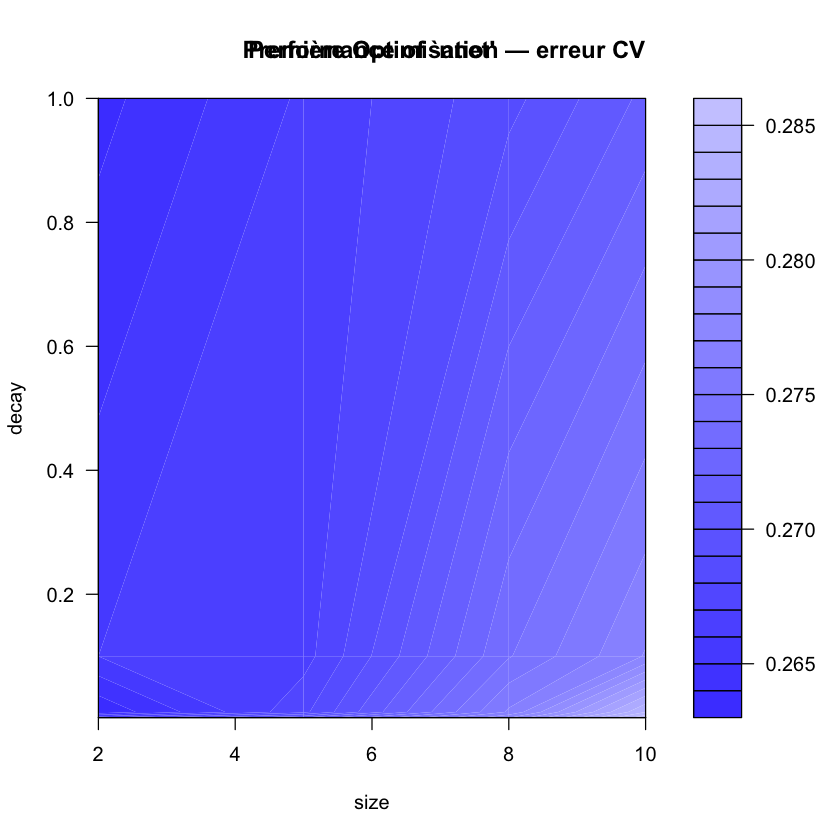

In [43]:

set.seed(101)
tune.optim1 <- tune.nnet(Heart_Disease_Risk ~ .,
                          data  = datappr_classif,
                          size  = c(2, 5, 8, 10),
                          decay = c(0.001, 0.01, 0.1, 1),
                          maxit = 500,
                          tunecontrol = tune.control(cross = 5))  # 5 au lieu de 10 pour être plus rapide

# Visualiser l'erreur de validation croisée
plot(tune.optim1)
title("Première Optimisation — erreur CV")

# Meilleurs paramètres
summary(tune.optim1)
tune.optim1$best.parameters
tune.optim1$best.performance  # erreur CV minimale



 
>Les paramètres size = 2 et decay = 0.01 ont été retenus pour une erreur de 0.2632.  

On observe une légère tendance à l'augmentation lorsque le nombre de neurones (size) augmente (l'erreur dépasse 0.285 pour size = 10 avec decay = 0.001)

### Optimisation fine

Suite aux résultats de la première optimisation qui avaient identifié les meilleurs paramètres autour de size = 2 et decay = 0.01, une seconde optimisation plus ciblée est réalisée.  
L'optimisation fine permet de vérifier si un réseau avec size = 1, 3 ou 4 associé à un decay optimisé (par exemple 0.005 ou 0.05) améliore l'erreur par rapport au meilleur résultat de la première optimisation.

,size,decay
,<dbl>,<dbl>
13,1,0.1


[1] 0.2625

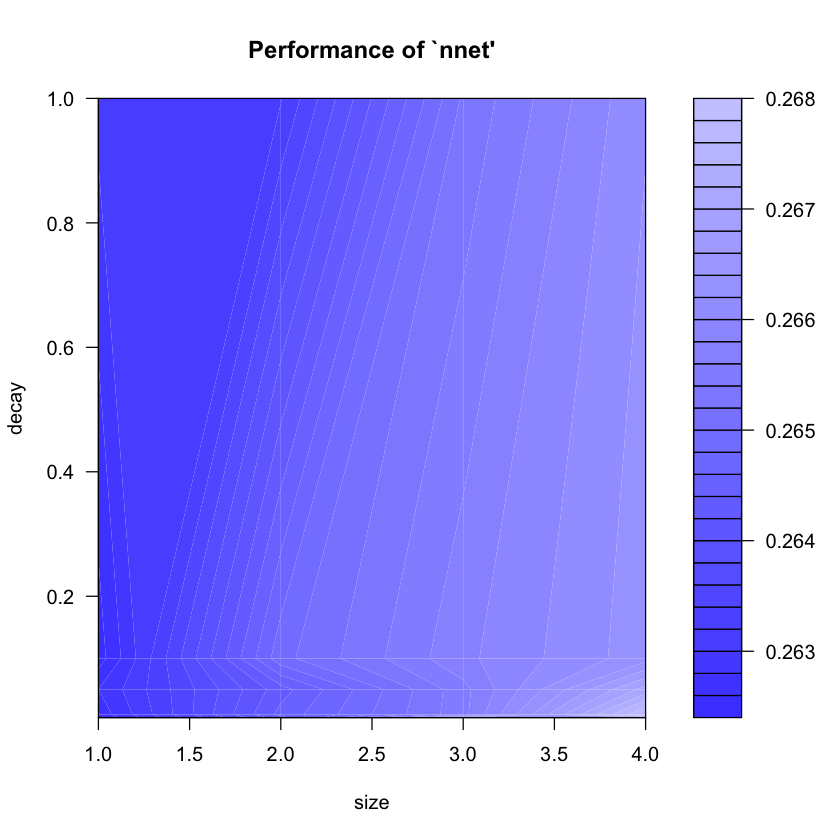

In [44]:
set.seed(101)
#optimisation plus fine, adaptée selon les résultats trouvés selon la première optimisation
tune.optim2 <- tune.nnet(Heart_Disease_Risk ~ .,
                        data  = datappr_classif,
                        size  = c(1, 2, 3, 4),
                        decay = c(0.005, 0.01, 0.05, 0.1, 1),
                        maxit = 500)
plot(tune.optim2)
tune.optim2$best.parameters
tune.optim2$best.performance

> Meilleurs paramètres : size = 1 et decay = 0.1, erreur = 0.2625

L'amélioration est modeste (0.2625<0.2632) mais elle montre qu'un réseau plus simple (un seul neurone caché) associé à une régularisation plus forte (decay = 0.1 contre 0.01) donne de meilleurs résultats. La réduction du nombre de neurones (size passé de 2 à 1) a permis d'obtenir un modèle légèrement plus simple.

### Entaînement du modèle final de classification 

Une fois les hyperparamètres optimaux identifiés lors de la seconde optimisation, un modèle final est entraîné sur l'ensemble des données d'apprentissage.

In [82]:
#Model final
best_size  <- tune.optim2$best.parameters$size
best_decay <- tune.optim2$best.parameters$decay

cat("Optimal size :", best_size,  "\n")
cat("Optimal decay:", best_decay, "\n")

set.seed(42)

nnet.class.final <- nnet(Heart_Disease_Risk ~ .,
                          data    = datappr_classif,
                          size    = best_size,
                          decay   = best_decay,
                          maxit   = 500)

summary(nnet.class.final)

Optimal size : 1 
Optimal decay: 0.1 
# weights:  23
initial  value 8097.393708 
iter  10 value 7043.323847
iter  20 value 6695.714700
iter  30 value 6457.038997
iter  40 value 6358.602152
iter  50 value 6343.814307
iter  60 value 6342.418814
iter  70 value 6341.633510
final  value 6340.641668 
converged


a 20-1-1 network with 23 weights
options were - entropy fitting  decay=0.1
  b->h1  i1->h1  i2->h1  i3->h1  i4->h1  i5->h1  i6->h1  i7->h1  i8->h1  i9->h1 
  -0.22    0.13   -0.06   -0.02    0.10    0.02    0.18   -0.01   -0.02    0.11 
i10->h1 i11->h1 i12->h1 i13->h1 i14->h1 i15->h1 i16->h1 i17->h1 i18->h1 i19->h1 
  -0.01    0.17    1.03   -0.03   -0.01   -0.27   -0.53   -0.78    0.79    0.16 
i20->h1 
  -0.05 
 b->o h1->o 
-4.06  8.22 

### Évaluation du modèle final sur l'échantillon test

Une fois le modèle final entraîné, il est utilisé pour faire des prédictions sur l'échantillon test (datestr_classif).

In [88]:
# Predictions des probabilités
pred.prob <- predict(nnet.class.final,
                     newdata = datestr_classif,
                     type    = "raw")
# Column 1 = P(risk=0), Column 2 = P(risk=1)

# Prediction de la classe
pred.class <- predict(nnet.class.final,
                      newdata = datestr_classif,
                      type    = "class")
pred.class <- as.factor(pred.class)

           Actuelles
Predictions    0    1
          0 1382  430
          1  338  850
Accuracy    : 0.744 
Sensibilité : 0.6641 
Spécificité : 0.8035 
AUC nnet : 0.8087 


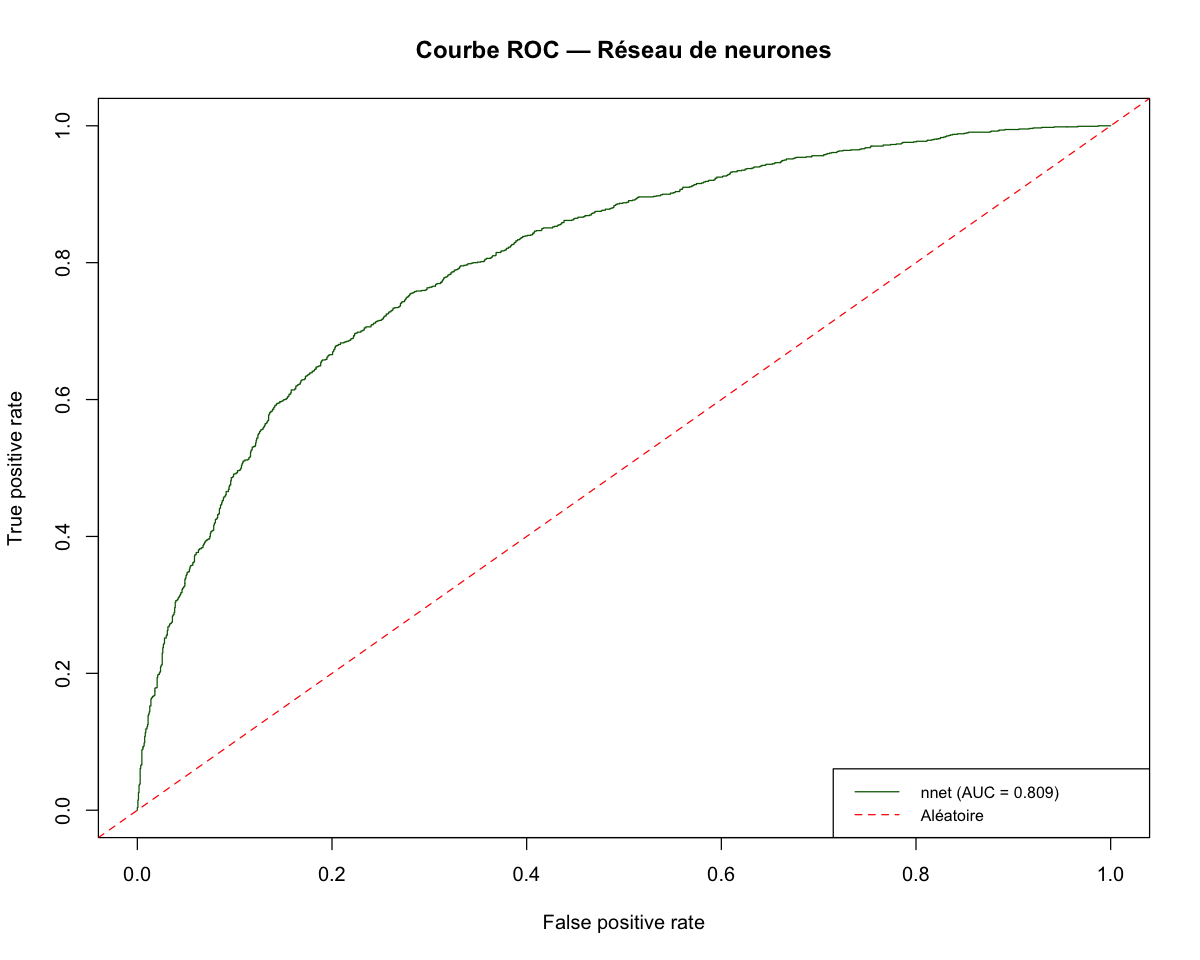

In [105]:
#Performance 
#Matrice de confusion
conf <- table(Predictions = pred.class,
                  Actuelles    = datestr_classif$Heart_Disease_Risk)
print(conf)

cat("Accuracy    :", round((1382+850)/3000, 4), "\n")
cat("Sensibilité :", round(850/(850+430),  4), "\n")
cat("Spécificité :", round(1382/(1382+338),4), "\n")


#ROC
pred.nnet.roc <- prediction(as.vector(pred.prob), 
                             datestr_classif$Heart_Disease_Risk)

perf.nnet.roc <- performance(pred.nnet.roc, "tpr", "fpr")

# AUC (Area under curve)
auc.nnet <- performance(pred.nnet.roc, "auc")@y.values[[1]]
cat("AUC nnet :", round(auc.nnet, 4), "\n")

plot(perf.nnet.roc,
     col  = "darkgreen",
     main = "Courbe ROC — Réseau de neurones")
abline(a = 0, b = 1, col = "red", lty = 2)
legend("bottomright",
       legend = c(paste0("nnet (AUC = ", round(auc.nnet, 3), ")"), "Aléatoire"),
       col    = c("darkgreen", "red"),
       lty    = c(1, 2),
       cex    = 0.8)



**Analyse des performances**. 

Le modèle final atteint une accuracy de 74,4%, ce qui signifie qu'il classe correctement environ 3 patients sur 4.  
* Sensibilité : 66,4%  Le modèle détecte correctement 66,4% des patients considérés à risque élevé de maladie cardiovasculaire
* Spécificité : 80,3%  Le modèle écarte correctement 80,3% des patients sans risque

Limitation identifiée :  
Sur les patients réellement à risque, 33,6% ne sont pas détectés (soit 338 faux négatifs sur 1188 patients malades). Ces faux négatifs représentent une population dangereusement sous-estimée.

# 4 Prédiction du taux de mauvais cholestérol : Cholesterol_LDL (régression)

## 4.1 Séparation des données en jeu de test et jeu d'entrainement

In [376]:
set.seed(111) # initialisation du générateur

# SPLIT (déjà fait mais je le laisse par simplicité)
test.ratio <- .2 # 20% de l'échantillon pour les tests et le reste pour l'apprentissage
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
ntest <- ceiling(npop * test.ratio) # taille de l'échantillon test
testi <- sample(1:npop, ntest) # indices de l'échantillon test
appri <- setdiff(1:npop, testi) # indices de l'échantillon d'apprentissage

# On sépare x et y
datappr0_svr <- data[appri, -which(names(data) == "Cholesterol_LDL")]
datestr0_svr  <- data[testi,  -which(names(data) == "Cholesterol_LDL")]
y_train_svr   <- data$Cholesterol_LDL[appri]
y_test_svr    <- data$Cholesterol_LDL[testi]

# Normalisation (train uniquement)
num_cols_svr <- sapply(datappr0_svr, is.numeric)
datappr_svr  <- datappr0_svr
datappr_svr[, num_cols_svr] <- scale(datappr0_svr[, num_cols_svr])
datestr_svr  <- datestr0_svr
datestr_svr[, num_cols_svr] <- scale(
  datestr0_svr[, num_cols_svr],
  center = sapply(datappr0_svr[, num_cols_svr], mean),  # ← stats du TRAIN
  scale  = sapply(datappr0_svr[, num_cols_svr], sd)
)

# Encodage des quali
X_train_svr <- as.data.frame(model.matrix(~ ., data = datappr_svr)[, -1])
X_test_svr  <- as.data.frame(model.matrix(~ ., data = datestr_svr)[, -1])
X_train_svr$Cholesterol_LDL <- y_train_svr

## 4.2 MODÈLE LINÉAIRE GAUSSIEN

Cette section compare plusieurs approches de régression linéaire :
- Modèle linéaire complet (toutes les variables)
- Sélection de variables par stepwise (critères AIC et BIC)
- Pénalisation Ridge (alpha = 0)
- Pénalisation Lasso (alpha = 1)
- Pénalisation Elastic Net (alpha optimisé par CV)
On évalue chaque modèle avec le RMSE et le R² sur le train et le test.

In [392]:


# fonction pour le graphe des résidus (style TP ozone)
gplot.res <- function(fit, res, titre = "") {
  df <- data.frame(fit = fit, res = res)
  df <- df[is.finite(df$fit) & is.finite(df$res), ]
  ggplot(df, aes(x = fit, y = res)) +
    geom_point(col = "blue", alpha = 0.4) +
    geom_hline(yintercept = 0, col = "green") +
    ylab("Résidus") + xlab("Valeurs prédites") +
    ggtitle(titre) +
    theme_minimal()}
 
# data frames complets avec la cible pour la syntaxe formule
train_ldl <- datappr_svr[, !names(datappr_svr) %in% "Heart_Disease_Risk"]
train_ldl$Cholesterol_LDL <- y_train_svr

test_ldl <- datestr_svr[, !names(datestr_svr) %in% "Heart_Disease_Risk"]
test_ldl$Cholesterol_LDL <- y_test_svr
 
# vérification : Cholesterol_LDL ne doit apparaître qu'une fois
cat("Colonnes train_ldl :", names(train_ldl), "\n")

Colonnes train_ldl : Age Gender Height_cm Weight_kg BMI Systolic_BP Diastolic_BP Cholesterol_Total Cholesterol_HDL Fasting_Blood_Sugar Smoking_Status Alcohol_Consumption Physical_Activity_Level Family_History Stress_Level Sleep_Hours Cholesterol_LDL 


### 4.2.1 Régression Linéaire Complete 


Call:
lm(formula = Cholesterol_LDL ~ ., data = train_ldl)

Residuals:
    Min      1Q  Median      3Q     Max 
-39.879  -6.793   0.044   6.673  37.240 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)              140.459668   0.267917 524.265   <2e-16 ***
Age                        0.124854   0.110515   1.130    0.259    
Gender1                    0.082551   0.273779   0.302    0.763    
Height_cm                  0.250394   0.608779   0.411    0.681    
Weight_kg                 -0.655328   0.994373  -0.659    0.510    
BMI                        0.435700   0.801736   0.543    0.587    
Systolic_BP                0.255558   0.160866   1.589    0.112    
Diastolic_BP              -0.203977   0.154569  -1.320    0.187    
Cholesterol_Total         14.853651   0.103575 143.410   <2e-16 ***
Cholesterol_HDL           -0.087012   0.108966  -0.799    0.425    
Fasting_Blood_Sugar        0.029493   0.094286   0.313    0.754    
Smoking_Status1 

RMSE train : 9.9939 
R² train   : 0.6902 
RMSE test : 9.9975 
R² test   : 0.6826 


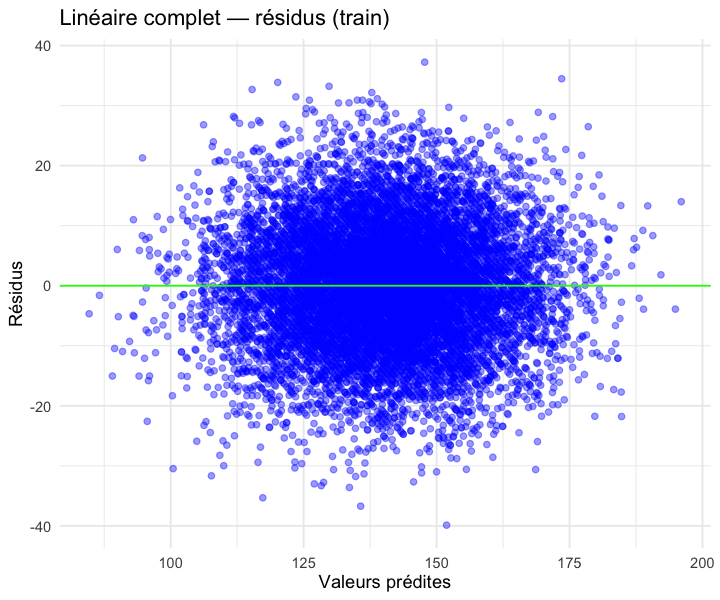

In [394]:
# Modèle de référence (baseline) : on prédit Cholesterol_LDL à partir de toutes les variables explicatives disponibles.
# On vérifie les hypothèses du modèle via le graphe des résidus :
#   - pas de structure (homoscédasticité)
#   - distribution symétrique autour de 0 (gaussianité)
 
reg.lm <- lm(Cholesterol_LDL ~ ., data = train_ldl)
 
# résumé : coefficients, R², F-statistic
summary(reg.lm)
 
# graphe des résidus sur le train
options(repr.plot.width = 6, repr.plot.height = 5)
gplot.res(reg.lm$fitted.values, reg.lm$residuals, "Linéaire complet — résidus (train)")
 
# erreur apparente (train)
rmse.lm.train <- sqrt(mean((y_train_svr - reg.lm$fitted.values)^2))
r2.lm.train <- summary(reg.lm)$r.squared
cat("RMSE train :", round(rmse.lm.train, 4), "\n")
cat("R² train   :", round(r2.lm.train, 4), "\n")
 
# prédictions sur le test
pred.lm <- predict(reg.lm, newdata = test_ldl)
ss.res <- sum((y_test_svr - pred.lm)^2)
ss.tot <- sum((y_test_svr - mean(y_test_svr))^2)
rmse.lm.test <- sqrt(mean((y_test_svr - pred.lm)^2))
r2.lm.test <- 1 - ss.res / ss.tot
cat("RMSE test :", round(rmse.lm.test, 4), "\n")
cat("R² test   :", round(r2.lm.test, 4), "\n")

Interprétation : 

- R² = 0.69, RMSE = 9.99 sur le test → le modèle explique 69% de la variance du LDL, performances stables train/test donc pas de surapprentissage
- Une seule variable significative : Cholesterol_Total (p < 2e-16) — biologiquement logique car le cholestérol total inclut directement le LDL
- Toutes les autres variables ont p > 0.05 → leur effet est masqué par Cholesterol_Total
- Graphe des résidus : nuage centré en 0, pas de structure → hypothèse d'homoscédasticité validée

La forte dominance de Cholesterol_Total va orienter la sélection de variables à l'étape suivante.


### 4.2.2 Séléction de Valraibles par Stepwise

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Cholesterol_Total,1,2668791.5688,2.668792e+06,26692.230374,0.00000000
Age,1,286.3976,2.863976e+02,2.864439,0.09058327
Residuals,11997,1199506.0736,9.998384e+01,NA,NA


Variables retenues AIC : Cholesterol_Total, Age 
Nombre de variables    : 2 
RMSE train : 9.9979 
R² train   : 0.6899 
RMSE test : 9.9961 
R² test   : 0.6827 


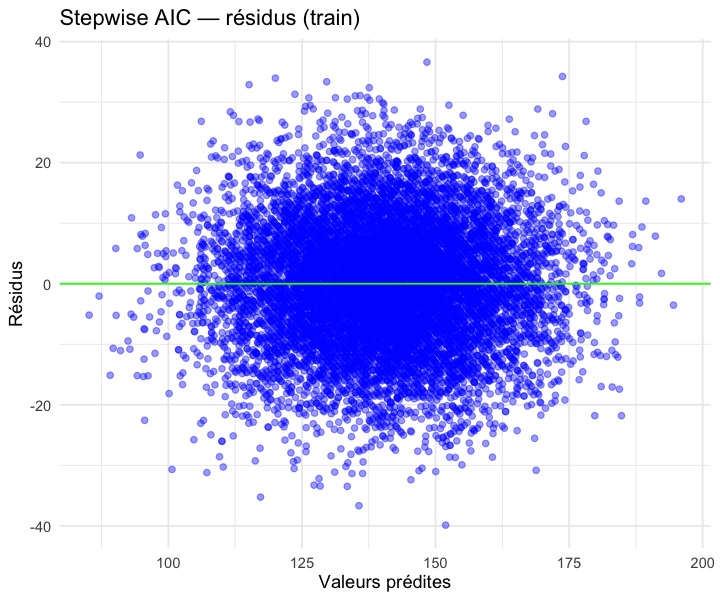

In [397]:
# Pour la régression gaussienne le test de Fisher (test="F")
# remplace le test du chi² utilisé en logistique.
 
# Stepwise AIC : 
set.seed(111)
reg.lm.step.aic <- step(reg.lm, direction = "both", trace = FALSE)
 
anova(reg.lm.step.aic, test = "F")
cat("Variables retenues AIC :", paste(names(coef(reg.lm.step.aic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(reg.lm.step.aic)) - 1, "\n")
 
# graphe des résidus
gplot.res(reg.lm.step.aic$fitted.values, reg.lm.step.aic$residuals, "Stepwise AIC — résidus (train)")
 
# erreur apparente
rmse.aic.train <- sqrt(mean((y_train_svr - reg.lm.step.aic$fitted.values)^2))
r2.aic.train <- summary(reg.lm.step.aic)$r.squared
cat("RMSE train :", round(rmse.aic.train, 4), "\n")
cat("R² train   :", round(r2.aic.train, 4), "\n")
 
# prédictions test
pred.aic <- predict(reg.lm.step.aic, newdata = test_ldl)
rmse.aic.test <- sqrt(mean((y_test_svr - pred.aic)^2))
r2.aic.test <- 1 - sum((y_test_svr - pred.aic)^2) / ss.tot
cat("RMSE test :", round(rmse.aic.test, 4), "\n")
cat("R² test   :", round(r2.aic.test, 4), "\n")

Interprétation : 
2 variables retenues : Cholesterol_Total, Age :

- Élimine 17 variables sur 19, ne garde que Cholesterol_Total (très significatif) et Age (p = 0.09, marginalement significatif)
- R² = 0.683, RMSE = 9.996 → performances quasi identiques au modèle complet avec seulement 2 variables
- Résidus bien centrés, pas de structure → hypothèses validées

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Cholesterol_Total,1,2668792,2.668792e+06,26688.08,0
Residuals,11998,1199792,9.999937e+01,NA,NA


Variables retenues BIC : Cholesterol_Total 
Nombre de variables    : 1 
RMSE train : 9.9991 
R² train   : 0.6899 
RMSE test : 9.9951 
R² test   : 0.6828 


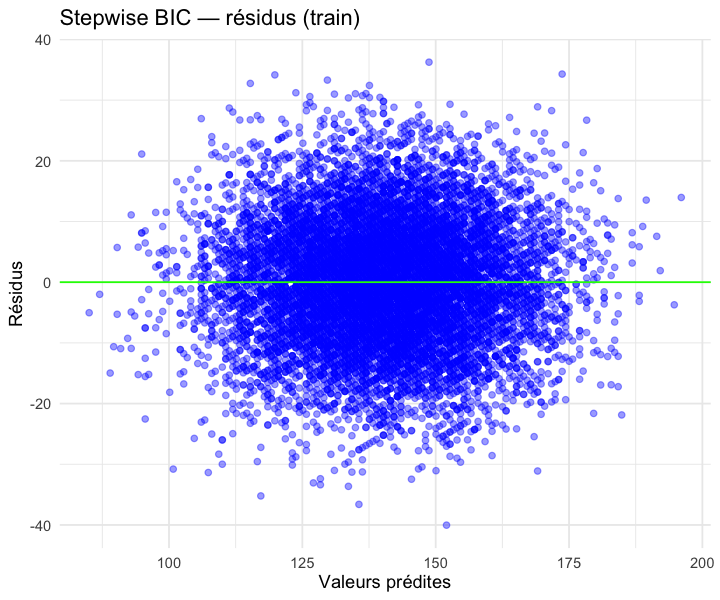

In [402]:
# Stepwise BIC : 
set.seed(111)
reg.lm.step.bic <- step(reg.lm, direction = "both",
                         k = log(nrow(train_ldl)), trace = FALSE)
 
anova(reg.lm.step.bic, test = "F")
cat("Variables retenues BIC :", paste(names(coef(reg.lm.step.bic))[-1], collapse = ", "), "\n")
cat("Nombre de variables    :", length(coef(reg.lm.step.bic)) - 1, "\n")
 
# graphe des résidus
gplot.res(reg.lm.step.bic$fitted.values, reg.lm.step.bic$residuals, "Stepwise BIC — résidus (train)")
 
# erreur apparente
rmse.bic.train <- sqrt(mean((y_train_svr - reg.lm.step.bic$fitted.values)^2))
r2.bic.train <- summary(reg.lm.step.bic)$r.squared
cat("RMSE train :", round(rmse.bic.train, 4), "\n")
cat("R² train   :", round(r2.bic.train, 4), "\n")
 
# prédictions test
pred.bic <- predict(reg.lm.step.bic, newdata = test_ldl)
rmse.bic.test <- sqrt(mean((y_test_svr - pred.bic)^2))
r2.bic.test <- 1 - sum((y_test_svr - pred.bic)^2) / ss.tot
cat("RMSE test :", round(rmse.bic.test, 4), "\n")
cat("R² test   :", round(r2.bic.test, 4), "\n")

Interprétation : 
1 seule variable retenue : Cholesterol_Total :

- Le BIC, plus sévère, élimine même Age et ne conserve qu'une seule variable
- R² = 0.683, RMSE = 9.995 → performances identiques à l'AIC
- C'est le modèle le plus parcimonieux possible

CONCLUSION : 

- Résultat dominant: Cholesterol_Total seule suffit à expliquer 69% de la variance du LDL. Toutes les autres variables sont redondantes ou non informatives
- Performances quasi identiques entre le modèle complet (19 variables) et le BIC (1 variable) : RMSE passe de 9.997 à 9.995
- C'est cohérent biologiquement : le cholestérol total est une combinaison directe du LDL, HDL et VLDL — la relation est quasi-linéaire par construction
Les modèles pénalisés devraient confirmer ce résultat en attribuant un poids dominant à Cholesterol_Total

### 4.2.3 Pénalisation Ridge, Lasso et Elastic Net

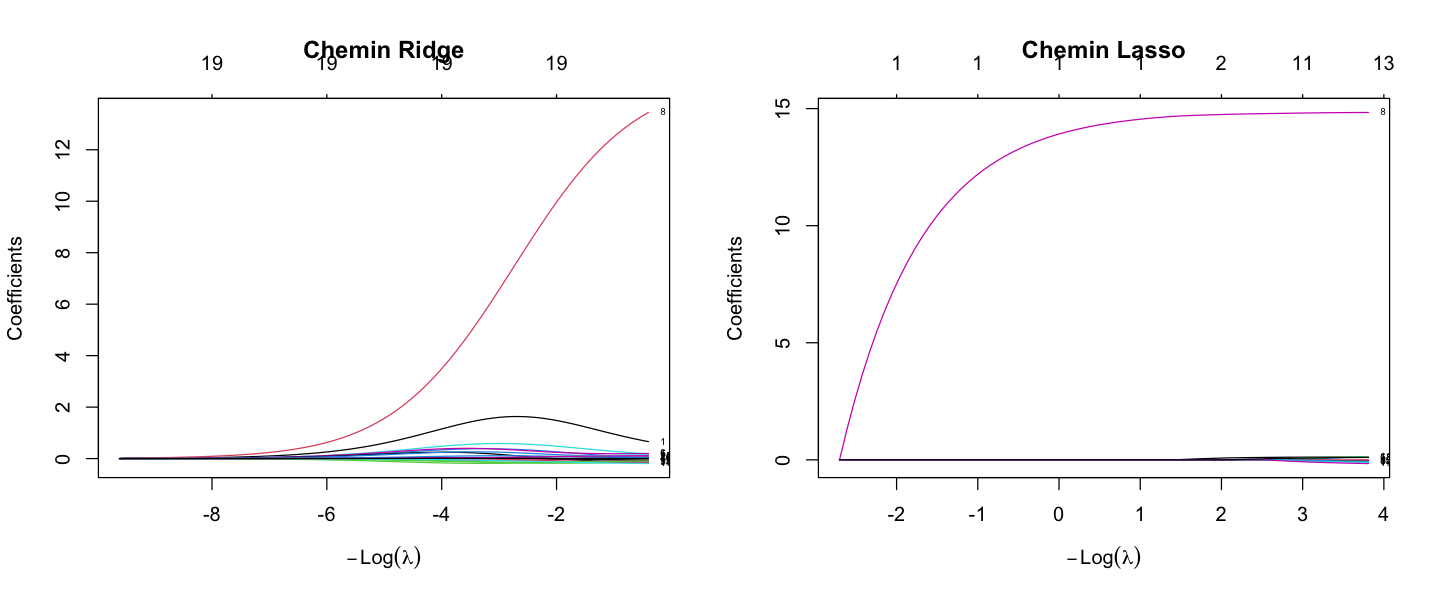

In [419]:
# glmnet minimise par défaut l'erreur quadratique (gaussian)
 
library(glmnet)
 
# matrices locales pour la régression LDL — on retire Heart_Disease_Risk
# sans modifier X_train_svr et X_test_svr utilisés plus tard
x.mat.ldl <- as.matrix(X_train_svr[, !names(X_train_svr) %in% c("Cholesterol_LDL", "Heart_Disease_Risk1")])
x.mat.ldl.test <- as.matrix(X_test_svr[, !names(X_test_svr) %in% "Heart_Disease_Risk1"])
# chemins de régularisation : 
reg.ridge.ldl <- glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 0)
reg.lasso.ldl <- glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 1)
 
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2))
plot(reg.ridge.ldl, xvar = "lambda", label = TRUE, main = "Chemin Ridge")
plot(reg.lasso.ldl, xvar = "lambda", label = TRUE, main = "Chemin Lasso")
par(mfrow = c(1, 1))
 

Interprétation : 

Les deux graphes racontent la même histoire que le stepwise : une seule courbe domine largement (rose = Cholesterol_Total), toutes les autres restant proches de 0. Sous Lasso, Cholesterol_Total entre en premier et seule dès les petites valeurs de lambda,  les 12 autres variables n'entrent que très tardivement avec des coefficients quasi nuls.

[1] "Ridge — lambda.min : 1.49131 | lambda.1se : 2.16363"

[1] "Lasso — lambda.min : 0.15623 | lambda.1se : 1.20964"

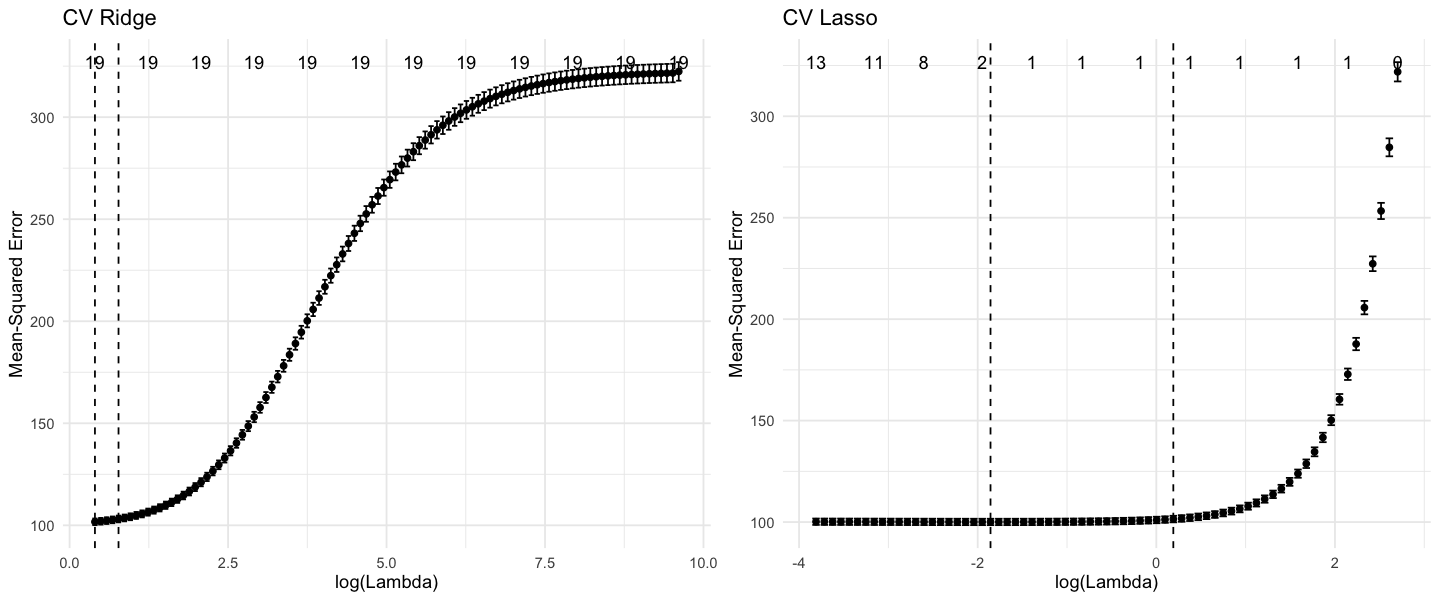

In [421]:

# sélection de lambda par validation croisée 10-fold : 
set.seed(111)
reg.ridge.cv.ldl <- cv.glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 0, nfolds = 10)
set.seed(111)
reg.lasso.cv.ldl <- cv.glmnet(y = y_train_svr, x = x.mat.ldl, alpha = 1, nfolds = 10)
 
options(repr.plot.width = 12, repr.plot.height = 5)
p1 <- autoplot(reg.ridge.cv.ldl) + ggtitle("CV Ridge") + theme_minimal()
p2 <- autoplot(reg.lasso.cv.ldl) + ggtitle("CV Lasso") + theme_minimal()
grid.arrange(p1, p2, ncol = 2)
 
paste("Ridge — lambda.min :", round(reg.ridge.cv.ldl$lambda.min, 5),
      "| lambda.1se :", round(reg.ridge.cv.ldl$lambda.1se, 5))
paste("Lasso — lambda.min :", round(reg.lasso.cv.ldl$lambda.min, 5),
      "| lambda.1se :", round(reg.lasso.cv.ldl$lambda.1se, 5))
 

20 x 1 sparse Matrix of class "dgCMatrix"
                           lambda.min
(Intercept)              140.35741667
Age                        0.05986055
Gender1                    .         
Height_cm                  .         
Weight_kg                  .         
BMI                        .         
Systolic_BP                .         
Diastolic_BP               .         
Cholesterol_Total         14.73230138
Cholesterol_HDL            .         
Fasting_Blood_Sugar        .         
Smoking_Status1            .         
Alcohol_Consumption1       .         
Alcohol_Consumption2       .         
Physical_Activity_Level1   .         
Physical_Activity_Level2   .         
Physical_Activity_Level3   .         
Family_History1            .         
Stress_Level               .         
Sleep_Hours                .         

20 x 1 sparse Matrix of class "dgCMatrix"
                         lambda.1se
(Intercept)               140.35742
Age                         .      
Gender1                     .      
Height_cm                   .      
Weight_kg                   .      
BMI                         .      
Systolic_BP                 .      
Diastolic_BP                .      
Cholesterol_Total          13.70398
Cholesterol_HDL             .      
Fasting_Blood_Sugar         .      
Smoking_Status1             .      
Alcohol_Consumption1        .      
Alcohol_Consumption2        .      
Physical_Activity_Level1    .      
Physical_Activity_Level2    .      
Physical_Activity_Level3    .      
Family_History1             .      
Stress_Level                .      
Sleep_Hours                 .      

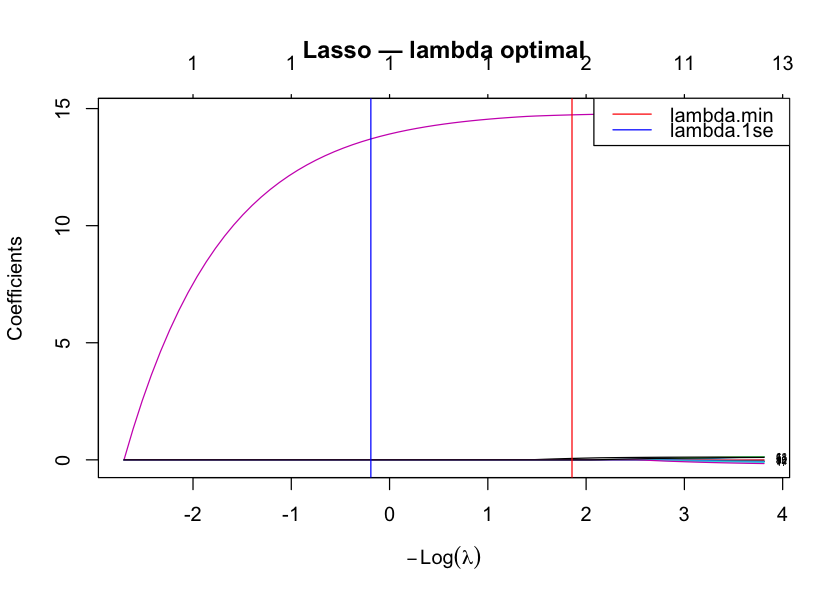

In [423]:

# coefficients Lasso à lambda.min et lambda.1se
coef(reg.lasso.cv.ldl, s = "lambda.min")
coef(reg.lasso.cv.ldl, s = "lambda.1se")
 
# lambda optimal sur le chemin Lasso
options(repr.plot.width = 7, repr.plot.height = 5)
plot(reg.lasso.ldl, xvar = "lambda", label = TRUE, main = "Lasso — lambda optimal")
abline(v = -log(reg.lasso.cv.ldl$lambda.min), col = "red")
abline(v = -log(reg.lasso.cv.ldl$lambda.1se), col = "blue")
legend("topright", legend = c("lambda.min", "lambda.1se"),
       col = c("red", "blue"), lty = 1)

Interprétation : 

- **À lambda.min** : 2 variables retenues **Cholesterol_Total (14.73) et Age (0.06)**. 
- **À lambda.1se** : 1 seule variable **Cholesterol_Total** (13.70).

Résultat parfaitement cohérent avec le stepwise AIC (2 variables) et BIC (1 variable).

   alpha cv_error    lambda
1    0.0 101.7212 1.4913058
2    0.1 100.1923 0.1675220
3    0.2 100.1536 0.2557939
4    0.3 100.1219 0.2474088
5    0.4 100.0997 0.2235036
6    0.5 100.0848 0.2153687
7    0.6 100.0743 0.1969724
8    0.7 100.0671 0.1852945
9    0.8 100.0614 0.1779405
10   0.9 100.0573 0.1581693
11   1.0 100.0540 0.1562315


[1] "Alpha retenu  : 1"

[1] "Lambda retenu : 0.15623"

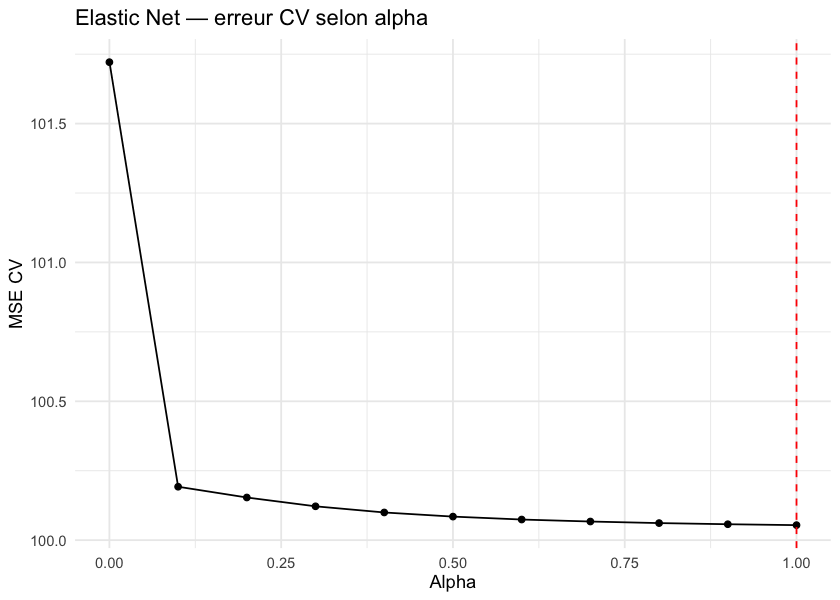

In [425]:
# Elastic Net : optimisation de alpha ET lambda par CV : 
set.seed(111)
alphas <- seq(0, 1, by = 0.1)
results.enet.ldl <- data.frame(alpha = alphas, cv_error = NA, lambda = NA)
 
for (i in seq_along(alphas)) {
  set.seed(111)
  cv_fit <- cv.glmnet(x.mat.ldl, y_train_svr,
                      alpha = alphas[i],
                      nfolds = 10,
                      type.measure = "mse")
  results.enet.ldl$cv_error[i] <- min(cv_fit$cvm)
  results.enet.ldl$lambda[i] <- cv_fit$lambda.min}
 
print(results.enet.ldl)
 
best.alpha.ldl <- results.enet.ldl$alpha[which.min(results.enet.ldl$cv_error)]
best.lambda.ldl <- results.enet.ldl$lambda[which.min(results.enet.ldl$cv_error)]
paste("Alpha retenu  :", best.alpha.ldl)
paste("Lambda retenu :", round(best.lambda.ldl, 5))
 
ggplot(results.enet.ldl, aes(x = alpha, y = cv_error)) +
  geom_line() + geom_point() +
  geom_vline(xintercept = best.alpha.ldl, col = "red", lty = 2) +
  labs(title = "Elastic Net — erreur CV selon alpha",
       x = "Alpha", y = "MSE CV") +
  theme_minimal()
 
set.seed(111)
reg.enet.cv.ldl <- cv.glmnet(x.mat.ldl, y_train_svr,
                               alpha = best.alpha.ldl,
                               nfolds = 10)

Interprétation : 

La courbe MSE CV décroît monotonement de Ridge (alpha=0, MSE=101.7) vers Lasso (alpha=1, MSE=100.05). 
Alpha retenu = 1 → l'Elastic Net dégénère vers un Lasso pur, confirmant que la sélection agressive est optimale sur ce dataset.

In [427]:
# erreur apparente (train) : 
fit.ridge.train.ldl <- predict(reg.ridge.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
fit.lasso.train.ldl <- predict(reg.lasso.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
fit.enet.train.ldl <- predict(reg.enet.cv.ldl, s = "lambda.min", newx = x.mat.ldl)[, 1]
 
cat("RMSE train Ridge :", round(sqrt(mean((y_train_svr - fit.ridge.train.ldl)^2)), 4), "\n")
cat("RMSE train Lasso :", round(sqrt(mean((y_train_svr - fit.lasso.train.ldl)^2)), 4), "\n")
cat("RMSE train Enet  :", round(sqrt(mean((y_train_svr - fit.enet.train.ldl)^2)), 4), "\n")
 
# performances sur le test : 
pred.ridge.ldl <- predict(reg.ridge.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
pred.lasso.ldl <- predict(reg.lasso.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
pred.enet.ldl <- predict(reg.enet.cv.ldl, newx = x.mat.ldl.test, s = "lambda.min")[, 1]
 
rmse.ridge.test <- sqrt(mean((y_test_svr - pred.ridge.ldl)^2))
rmse.lasso.test <- sqrt(mean((y_test_svr - pred.lasso.ldl)^2))
rmse.enet.test <- sqrt(mean((y_test_svr - pred.enet.ldl)^2))
 
r2.ridge.test <- 1 - sum((y_test_svr - pred.ridge.ldl)^2) / ss.tot
r2.lasso.test <- 1 - sum((y_test_svr - pred.lasso.ldl)^2) / ss.tot
r2.enet.test <- 1 - sum((y_test_svr - pred.enet.ldl)^2) / ss.tot
 
cat("Ridge — RMSE test :", round(rmse.ridge.test, 4), "| R² test :", round(r2.ridge.test, 4), "\n")
cat("Lasso — RMSE test :", round(rmse.lasso.test, 4), "| R² test :", round(r2.lasso.test, 4), "\n")
cat("Enet  — RMSE test :", round(rmse.enet.test, 4), "| R² test :", round(r2.enet.test, 4), "\n")
cat("Variables retenues Lasso :", sum(coef(reg.lasso.cv.ldl, s = "lambda.min") != 0) - 1, "\n")

RMSE train Ridge : 10.0706 
RMSE train Lasso : 9.9997 
RMSE train Enet  : 9.9997 
Ridge — RMSE test : 10.0626 | R² test : 0.6785 
Lasso — RMSE test : 9.9932 | R² test : 0.6829 
Enet  — RMSE test : 9.9932 | R² test : 0.6829 
Variables retenues Lasso : 2 


Interprétation : 

Ridge est légèrement en retrait car il conserve toutes les variables sans sélectionner Cholesterol_Total seule. Lasso et Elastic Net donnent les mêmes résultats avec seulement 2 variables.

CONCLUSION : 

Tous les résultats convergent : **Cholesterol_Total** est la seule variable vraiment informative pour prédire Cholesterol_LDL. La pénalisation confirme et renforce les conclusions du stepwise. Le RMSE se stabilise autour de **9.99** quelle que soit l'approche: c'est la limite du **signal linéaire disponible dans ces données.**

### 4.2.4 Comparaison finale 

,Modele,Nb_variables,RMSE_train,RMSE_test,R2_test
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
5,Lasso,2,9.9997,9.9932,0.6829
6,Elastic Net (alpha=1),NA,9.9997,9.9932,0.6829
3,Stepwise BIC,1,9.9991,9.9951,0.6828
2,Stepwise AIC,2,9.9979,9.9961,0.6827
1,Linéaire complet,19,9.9939,9.9975,0.6826
4,Ridge,NA,10.0706,10.0626,0.6785


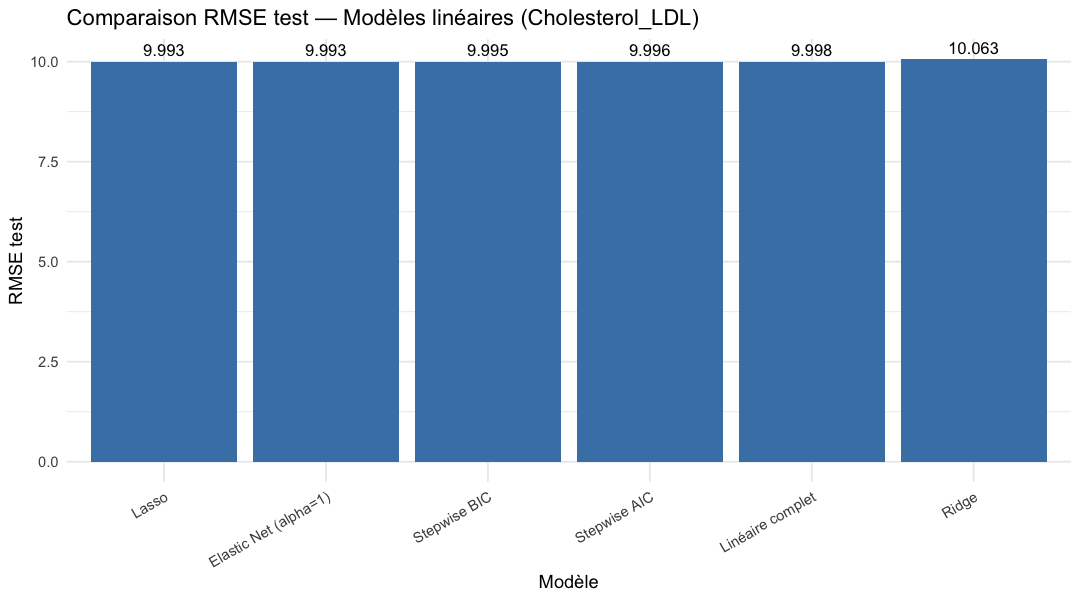

In [442]:
resultats.ldl <- data.frame(
  Modele = c("Linéaire complet", "Stepwise AIC", "Stepwise BIC",
             "Ridge", "Lasso", paste0("Elastic Net (alpha=", best.alpha.ldl, ")")),
  Nb_variables = c(
    length(coef(reg.lm)) - 1,
    length(coef(reg.lm.step.aic)) - 1,
    length(coef(reg.lm.step.bic)) - 1,
    NA,
    sum(coef(reg.lasso.cv.ldl, s = "lambda.min") != 0) - 1,
    NA),
  RMSE_train = round(c(
    rmse.lm.train, rmse.aic.train, rmse.bic.train,
    sqrt(mean((y_train_svr - fit.ridge.train.ldl)^2)),
    sqrt(mean((y_train_svr - fit.lasso.train.ldl)^2)),
    sqrt(mean((y_train_svr - fit.enet.train.ldl)^2))
  ), 4),
  RMSE_test = round(c(
    rmse.lm.test, rmse.aic.test, rmse.bic.test,
    rmse.ridge.test, rmse.lasso.test, rmse.enet.test
  ), 4),
  R2_test = round(c(
    r2.lm.test, r2.aic.test, r2.bic.test,
    r2.ridge.test, r2.lasso.test, r2.enet.test
  ), 4)
)
 
resultats.ldl[order(resultats.ldl$RMSE_test), ]
 
# barplot des RMSE test
resultats.ldl$Modele <- factor(resultats.ldl$Modele, levels = resultats.ldl$Modele[order(resultats.ldl$RMSE_test)])
 
options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(resultats.ldl, aes(x = Modele, y = RMSE_test)) +
  geom_col(fill = "steelblue") +
  geom_text(aes(label = round(RMSE_test, 3)), vjust = -0.5, size = 3.5) +
  labs(title = "Comparaison RMSE test — Modèles linéaires (Cholesterol_LDL)",
       x = "Modèle", y = "RMSE test") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

Interprétation : 

Toutes les barres sont quasi identiques **(RMSE entre 9.993 et 9.998)**, sauf Ridge (10.063) légèrement en retrait
Les RMSE train et test sont stables pour tous les modèles → **pas de surapprentissage**

### 4.2.5 Interprétation des résultats 

Coefficients — Modèle stepwise BIC: 



Call:
lm(formula = Cholesterol_LDL ~ Cholesterol_Total, data = train_ldl)

Residuals:
    Min      1Q  Median      3Q     Max 
-40.031  -6.778   0.018   6.616  36.254 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       140.35742    0.09129  1537.5   <2e-16 ***
Cholesterol_Total  14.91368    0.09129   163.4   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10 on 11998 degrees of freedom
Multiple R-squared:  0.6899,	Adjusted R-squared:  0.6898 
F-statistic: 2.669e+04 on 1 and 11998 DF,  p-value: < 2.2e-16


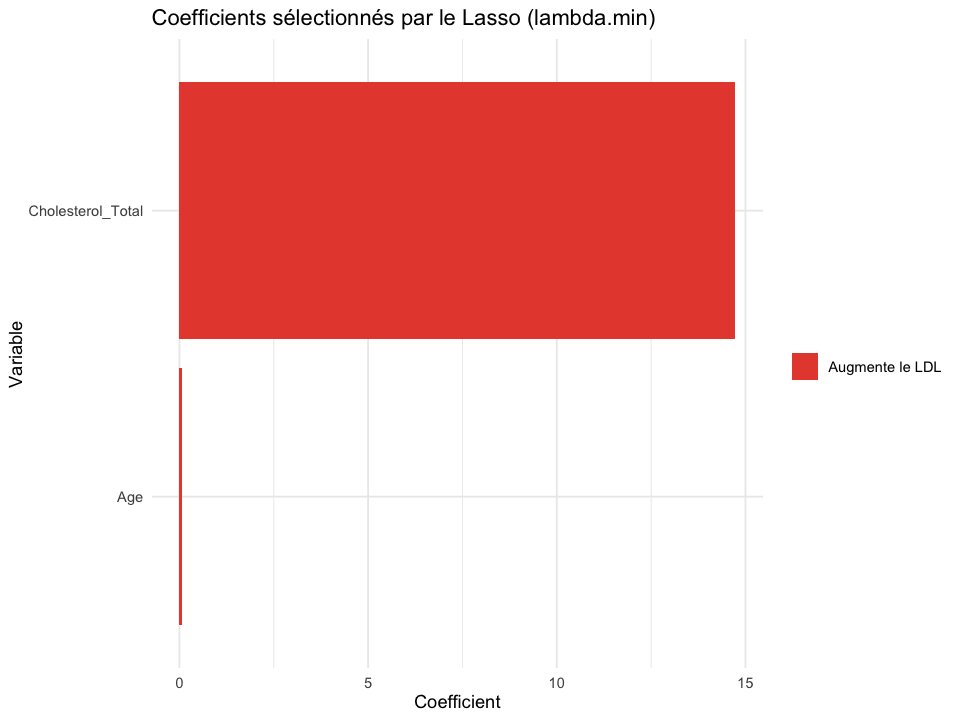

In [449]:
# Contrairement à la logistique, les coefficients s'interprètent directement en unités de Cholesterol_LDL (mg/dL).
 
cat("Coefficients — Modèle stepwise BIC: \n")
summary(reg.lm.step.bic)
 
# coefficients non nuls du Lasso à lambda.min
coef.lasso.ldl <- as.data.frame(as.matrix(coef(reg.lasso.cv.ldl, s = "lambda.min")))
colnames(coef.lasso.ldl) <- "Coefficient"
coef.lasso.ldl$Variable <- rownames(coef.lasso.ldl)
coef.lasso.ldl <- coef.lasso.ldl[coef.lasso.ldl$Coefficient != 0 & coef.lasso.ldl$Variable != "(Intercept)", ]
coef.lasso.ldl <- coef.lasso.ldl[order(abs(coef.lasso.ldl$Coefficient), decreasing = TRUE), ]
 
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(coef.lasso.ldl, aes(x = reorder(Variable, abs(Coefficient)),
                            y = Coefficient,
                            fill = Coefficient > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"),
                    labels = c("TRUE" = "Augmente le LDL", "FALSE" = "Réduit le LDL")) +
  labs(title = "Coefficients sélectionnés par le Lasso (lambda.min)",
       x = "Variable", y = "Coefficient", fill = "") +
  theme_minimal()

Interprétation : 

1. Le modèle BIC se réduit à une relation quasi-linéaire simple : Cholesterol_LDL ≈ 140.36 + 14.91 × Cholesterol_Total. Le coefficient de Cholesterol_Total (14.91, p < 2e-16) est très significatif 
=> une augmentation d'une unité normalisée du cholestérol total est associée à une hausse de ~15 mg/dL de LDL. 

2. Le graphique Lasso confirme visuellement la domination écrasante de Cholesterol_Total, Age ayant un coefficient quasi nul.

### 4.2.6 Conclusion générale 

La prédiction du cholestérol LDL par modèles linéaires révèle un résultat biologiquement cohérent : **Cholesterol_Total** est le seul prédicteur réellement informatif, ce qui s'explique par la relation biochimique directe entre les deux variables (le cholestérol total inclut le LDL).

Toutes les approches convergent vers le même constat : modèle complet (19 variables), stepwise BIC (1 variable), Lasso (2 variables) ont des performances quasi identiques autour de RMSE ≈ 9.99 et R² ≈ 0.683. La pénalisation et la sélection de variables ne font ici que confirmer ce que l'analyse exploratoire laissait supposer.

Le plafond des modèles linéaires semble atteint à **R² ≈ 0.683**. La question pour la suite est de savoir si les modèles non linéaires parviennent à capturer la variance résiduelle de 31%, ou si celle-ci est simplement due au bruit. 

## 4.3 Régression par SVM : SVR pour Cholesterol_LDL

Dans cette partie, l’objectif est de prédire le taux de mauvais cholestérol (variable Cholesterol_LDL) avec la méthode SVM. Il s’agit d’un problème de régression.

Nous allons tester des SVR (Support Vecteur Regression) avec 4 noyaux différents : gaussien, linéaire, polynomial et radial; pour déterminer la meilleure méthode de régression à l'aide de l'accurancy et de l'AUC (Area Under the Curve). Cette fois-ci, directement avec la méthode plus rapide.

In [ ]:
## Prévision par SVM : SVR pour Cholesterol_LDL

# Dataset pour la SVR (variable cible numérique)
X_train_svr <- X_train  # doit contenir Cholesterol_LDL comme numérique
X_test_svr  <- X_test

# Retirer Heart_Disease_Risk si présent
X_train_svr$Heart_Disease_Risk <- NULL
X_test_svr$Heart_Disease_Risk  <- NULL

# Sous-échantillon pour aller plus vite (comme tu fais en SVC)
set.seed(42)
X_train_svr_small <- X_train_svr[sample(nrow(X_train_svr), 5000), ]

# Contrôle CV — RMSE au lieu de ROC
cvControl_svr <- trainControl(
  method = "cv",
  number = 5   # 5-fold pour aller vite
)

# Méthodes SVR à comparer
methodes_svr <- list(
  list(method = "svmRadial", tuneGrid = expand.grid(
    sigma = c(0.001, 0.005),
    C     = c(0.5, 1, 2)
  )),
  list(method = "svmLinear", tuneGrid = expand.grid(
    C = c(0.5, 1, 2)
  )),
  list(method = "svmPoly", tuneGrid = expand.grid(
    degree = c(2, 3),
    scale  = c(0.01),
    C      = c(0.5, 1)
  ))
)

# Entraînement
resultats_svr <- lapply(methodes_svr, function(m) {
  set.seed(111)
  
  fit <- train(
    Cholesterol_LDL ~ .,
    data       = X_train_svr_small,
    method     = m$method,
    tuneGrid   = m$tuneGrid,
    trControl  = cvControl_svr,
    metric     = "RMSE",
    preProcess = c("center", "scale")
  )
  
  list(
    method = m$method,
    best   = fit$bestTune,
    rmse   = min(fit$results$RMSE),
    r2     = max(fit$results$Rsquared),
    fit    = fit
  )
})

# Tableau comparatif
res_svr_df <- do.call(rbind, lapply(resultats_svr, function(r)
  data.frame(
    Noyau    = r$method,
    RMSE     = round(r$rmse, 4),
    Rsquared = round(r$r2, 4)
  )
))

print(res_svr_df)

# Prédiction avec le meilleur modèle
best_svr <- resultats_svr[[which.min(res_svr_df$RMSE)]]$fit

pred_svr <- predict(best_svr, newdata = X_test_svr)
rmse_test <- sqrt(mean((pred_svr - X_test_svr$Cholesterol_LDL)^2))
r2_test   <- cor(pred_svr, X_test_svr$Cholesterol_LDL)^2

cat("RMSE test :", round(rmse_test, 4), "\n")
cat("R²   test :", round(r2_test, 4), "\n")

Le meilleur noyau est le noyau linéaire : RMSE le plus faible (0.5616) et R² le plus élevé (0.6883).
La différence entre les noyaux est très faible : tous les modèles sont quasi équivalents.

**Noyau optimal : linéaire**

In [50]:
svr.lin.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = c(0.5, 1, 2, 3, 5),
  tunecontrol = tune.control(cross = 10)
)
cat("Meilleur cost :", svr.lin.tune$best.parameters$cost, "\n")

Meilleur cost : 3 


In [51]:
svr.lin <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = svr.lin.tune$best.parameters$cost
)

y_train_svr <- X_train_svr$Cholesterol_LDL
fit.rbf <- predict(svr.lin, newdata = X_train_svr)
res.rbf <- fit.rbf - y_train_svr
plot(fit.lin, res.lin,
     main = "SVR RBF – résidus train",
     xlab = "Valeurs prédites",
     ylab = "Résidus",
     col = "green",
     pch = 16,
     cex = 0.7)  # taille des points
abline(h = 0, col = "red")

pred.lin <- predict(svr.lin, newdata = X_test_svr)
rmse.lin <- sqrt(mean((y_test_svr - pred.lin)^2))
cat("RMSE SVR Linéaire :", rmse.lin, "\n")

ERROR: Error in h(simpleError(msg, call)): erreur d'ï¿½valuation de l'argument 'x' lors de la sï¿½lection d'une mï¿½thode pour la fonction 'plot' : objet 'fit.lin' introuvable


## Prédiction par réseau de neurone

La méthodologie employée pour la régression est identique à celle utilisée pour la classification. La seule différence réside dans la nature de la variable cible : continue (Cholesterol_LDL) au lieu de binaire (Heart_Disease_Risk).

In [110]:
datappr$Patient_ID <- NULL
datestr$Patient_ID <- NULL

### Première optimisation grossière

Les paramètres testés sont les suivants. size (nombre de neurones dans la couche cachée) prend les valeurs 2, 5, 8 et 10. decay (coefficient de régularisation L2) prend les valeurs 0.001, 0.01, 0.1 et 1.

Plusieurs spécificités sont à noter pour la régression. L'option linout = TRUE est activée car la couche de sortie utilise une fonction d'activation linéaire , ce qui est essentiel puisque la variable cible Cholesterol_LDL est continue.

,size,decay
,<dbl>,<dbl>
1,2,0.001


[1] 0.3116498

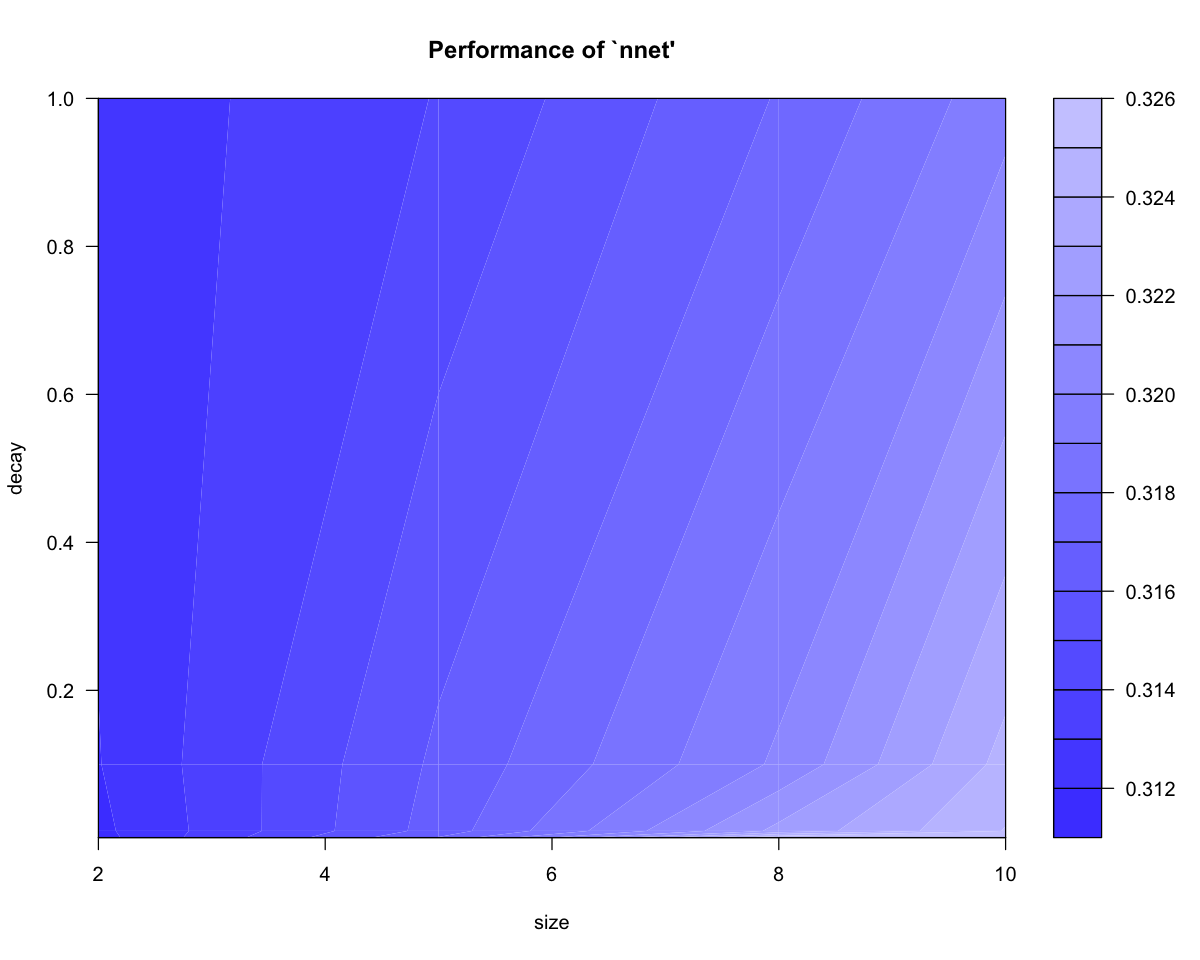

In [111]:
set.seed(101)

tune.reg.optim1 <- tune.nnet(Cholesterol_LDL ~ .,
                              data    = datappr,
                              size    = c(2, 5, 8, 10),
                              decay   = c(0.001, 0.01, 0.1, 1),
                              maxit   = 500,
                              linout  = TRUE,
                              tunecontrol = tune.control(cross = 5))

plot(tune.reg.optim1)
tune.reg.optim1$best.parameters
tune.reg.optim1$best.performance  #MSE par défaut

Meilleurs paramètres : size = 2, decay = 0.01. 

MSE minimale : 0.3118

### Optimisation fine

Suite aux résultats de la première optimisation, une seconde optimisation plus ciblée est réalisée en resserrant l'espace de recherche autour des valeurs prometteuses identifiées.

,size,decay
,<dbl>,<dbl>
1,1,0.005


[1] 0.3109776

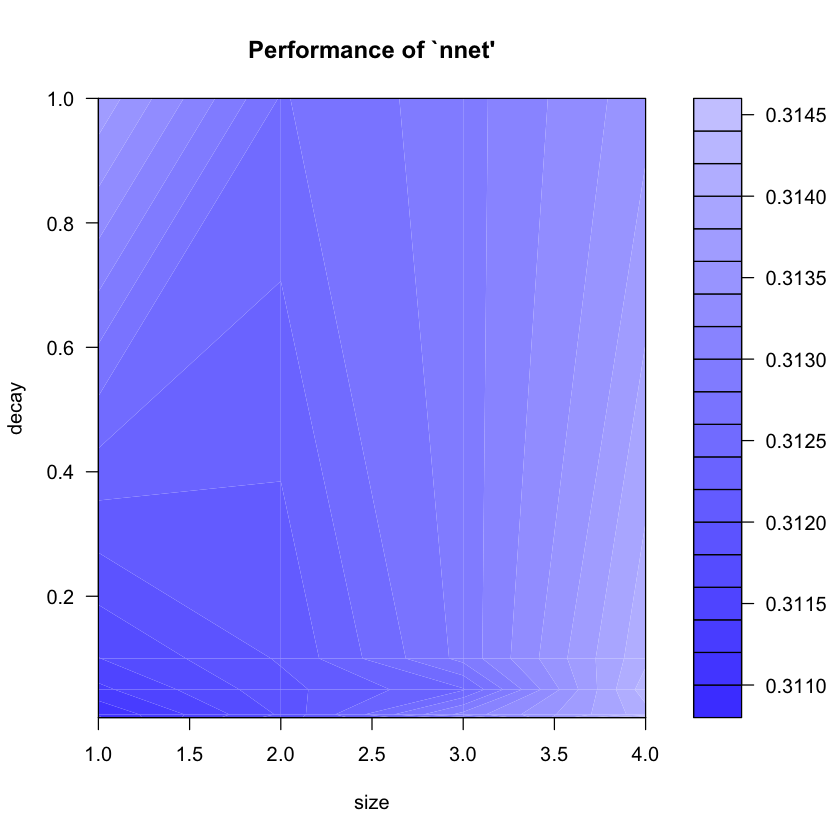

In [67]:
set.seed(101)
#optimisation fine
tune.reg.optim2 <- tune.nnet(Cholesterol_LDL ~ .,
                        data    = datappr,
                        size  = c(1, 2, 3, 4),
                        decay = c(0.005, 0.01, 0.05, 0.1, 1),
                        maxit = 500,
                        linout  = TRUE)

plot(tune.reg.optim2)
tune.reg.optim2$best.parameters
tune.reg.optim2$best.performance

Meilleurs paramètres : size = 1 et decay = 0.005. 

Meilleure performance (MSE) : 0.3110

 La MSE est passée de 0.3118 à 0.3110, soit une réduction négligeable. L'optimisaiton fine a été utile pour simplifier l'architecture en passant à un résaux à 1 seul neuronne dans la couche cachée. 
 

### Entraînement du modèle final de régression 

In [68]:
#Model final
best_size_reg  <- tune.reg.optim2$best.parameters$size
best_decay_reg <- tune.reg.optim2$best.parameters$decay
cat("Optimal size :", best_size_reg, "\n")
cat("Optimal decay:", best_decay_reg, "\n")

set.seed(101)

nnet.reg.final <- nnet(Cholesterol_LDL ~ .,
                        data    = datappr,
                        size    = best_size_reg,
                        decay   = best_decay_reg,
                        maxit   = 500,
                        linout  = TRUE)

summary(nnet.reg.final)

Optimal size : 1 
Optimal decay: 0.005 
# weights:  22
initial  value 17498.465865 
iter  10 value 8830.441174
iter  20 value 7760.342823
iter  30 value 5771.244303
iter  40 value 4694.968425
iter  50 value 4214.919976
iter  60 value 4051.690308
iter  70 value 3876.371649
iter  80 value 3759.434906
iter  90 value 3731.571714
iter 100 value 3729.628578
iter 110 value 3729.430422
iter 120 value 3723.803567
iter 130 value 3721.828825
iter 140 value 3721.492721
final  value 3721.489901 
converged


a 19-1-1 network with 22 weights
options were - linear output units  decay=0.005
  b->h1  i1->h1  i2->h1  i3->h1  i4->h1  i5->h1  i6->h1  i7->h1  i8->h1  i9->h1 
   0.05    0.00    0.00    0.00   -0.01    0.01    0.00    0.00    0.20    0.00 
i10->h1 i11->h1 i12->h1 i13->h1 i14->h1 i15->h1 i16->h1 i17->h1 i18->h1 i19->h1 
   0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00    0.00 
 b->o h1->o 
-8.57 16.76 

### Évaluation du modèle final sur l'échantillon test

RMSE : 9.9975 mg/dL
R²   : 0.6826 


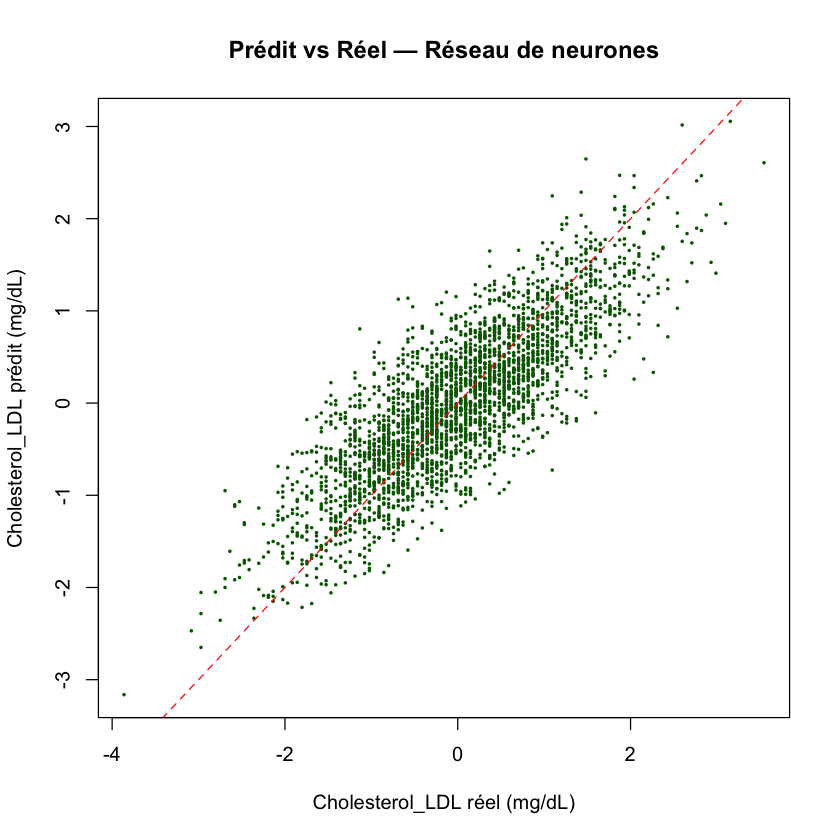

In [71]:
# Prédictions
pred.reg <- predict(nnet.reg.final, newdata = datestr)
# Valeurs réelles
true.reg <- datestr$Cholesterol_LDL

rmse <- sqrt(mean((pred.reg - true.reg)^2))
sd_ldl <- sd(data[appri, "Cholesterol_LDL"])  # écart-type original
ss_res <- sum((pred.reg - true.reg)^2)
ss_tot <- sum((mean(true.reg) - true.reg)^2)
r2   <- 1 - ss_res / ss_tot

cat("RMSE :", round(rmse* sd_ldl, 4), "mg/dL\n")
cat("R²   :", round(r2,   4), "\n")

# Graphique prédit vs réel
plot(true.reg, pred.reg,
     xlab = "Cholesterol_LDL réel (mg/dL)",
     ylab = "Cholesterol_LDL prédit (mg/dL)",
     main = "Prédit vs Réel — Réseau de neurones",
     col  = "darkgreen", pch = 16, cex = 0.4)
abline(a = 0, b = 1, col = "red", lty = 2)



>Le modèle se trompe en moyenne de 10 mg/dL
>Le modèle explique 68.3% de la variance de Cholesterol_LDL -> modèle acceptable